In [1]:
import numpy as np
import pandas as pd
import glob, os, vcf, warnings, shutil, subprocess, re
from Bio import Seq, SeqIO
from Bio.Data import CodonTable

warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
import scipy.stats as st
import scipy, pysam
from matplotlib.colors import ListedColormap
from collections import Counter
from dna_features_viewer import GraphicFeature, GraphicRecord

from scripts.variant_selection_utils import *

h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

# remove rRNAs, which are highly conserved. rrs, rrl, and rrf
rRNA_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='stable RNAs' & Feature=='rRNA'").iterrows():
    print(row['Name'])
    rRNA_pos += list(np.arange(row['Start'], row['Stop'] + 1))

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/combined_patient_WGS_data.csv").dropna(subset='Lineage')
df_trust_patients['Paired_Sample_Num'] = df_trust_patients.sort_values(['pid', 'Sampling_Week']).groupby('pid')['SampleID'].cumcount() + 1

isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")
isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/TRUST_isolate_variants_WHO_catalog.csv")

for i, row in df_trust_patients.iterrows():
    if not row['Original_ID'].startswith('S'):
        
        length_numerical = len(row['Original_ID'].split('-')[0])
            
        newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
        df_trust_patients.loc[i, 'Original_ID'] = newID

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

mixed_samples = df_trust_patients.query("F2 > 0.03").SampleID.unique()

def get_RvID_from_gff(attr_str):
    """
    Parse the attributes column of a GFF line.
    Returns a dict of key:value pairs.
    """
    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['ID'].split('-')[-1]


def get_geneName_from_gff(attr_str):

    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['Name']

F2_max = 0.03

df_who_variants = pd.read_csv(f"~/MtbQuantCNN/data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
genes_with_awR_mutations = df_who_variants.loc[df_who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].gene.unique()

cc_df = pd.read_csv(f"~/MtbQuantCNN/data_processing/data_utils/drug_CC.csv")

SNP_dist_matrix = pd.read_csv("~/MtbLongitudinalDiversity/data/TRUST_TOTAL.SNP.distance.matrix.V3.csv", header=None, names=['Sample1', 'Sample2', 'Dist'])

who_catalog = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/WHO-catalog-2023.csv", header=2)

rrs
rrl
rrf


In [4]:
isolate_metadata.query("BIOSAMPLE_ACCESSION=='SAMEA5282395'")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,SAMPLE,RUN,DB_OF_ORIGIN,ISOLATION_DATE,ISOLATION_COUNTRY,ISOLATION_REGION,SPUTUM/CULTURE,UNPAIRED/PAIRED,Platform,Model,SPECIES,TaxID,ReleaseDate,LoadDate,Num_Runs,Internal_IDs,Combined_Runs
72737,SAMEA5282395,SAMEA5282395,ERS3089663,ERR3132145,NaN,NaN,NaN,NaN,NaN,NaN,ILLUMINA,Illumina HiSeq 2500,Mycobacterium tuberculosis,1773.0,2019-05-31 11:07:44,2019-05-31 13:41:25,1,NaN,ERR3132145


In [7]:
isolate_metadata.DB_OF_ORIGIN.unique()

array([nan, 'cetr', 'EXIT-RIF', 'Wadsworth', 'guerra', 'JATA-KIT',
       'Gandhi', 'CASS', 'PATRIC_20191206', 'cryptic', 'farhat_internal',
       'reseqtb', 'pools', 'Murray', 'TRUST_directsputum', 'NSW',
       'Helen Cox', 'NICD', 'italian', 'JATA-Mongolia', 'natgen', 'Lizma',
       'Kreiswirth', 'TGEN'], dtype=object)

In [22]:
df_TCC = pd.read_csv("~/TRUST_data_processing/processed_data/TCC.csv")
df_cultures = pd.read_csv("~/TRUST_data_processing/processed_data/cultures.csv")
df_imputed_TCC = pd.read_csv("~/TRUST_data_processing/processed_data/imputed_TCC.csv")

In [39]:
longitudinal_ttp_pids = pd.DataFrame(df_cultures.dropna(subset='hours').groupby('pid')['sample_num'].nunique()).query("sample_num > 1").index.values

df_longitudinal_ttp = df_cultures.dropna(subset='hours')#.query("pid in @longitudinal_ttp_pids").reset_index(drop=True)

df_longitudinal_ttp.pid.nunique()

In [42]:
st.spearmanr(df_longitudinal_ttp['sample_num'],
             df_longitudinal_ttp['hours']
            )

SignificanceResult(statistic=0.6727605562382409, pvalue=1.307047864276953e-252)

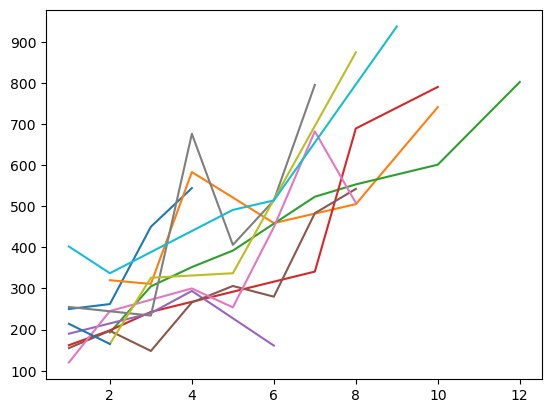

In [35]:
fig, ax = plt.subplots()

for i, pid in enumerate(df_longitudinal_ttp.pid.unique()):
    
    df_single_pid_ttp = df_longitudinal_ttp.query("pid==@pid")
    
    plt.plot(df_single_pid_ttp['sample_num'], df_single_pid_ttp['hours'])
    
    if i == 10:
        break

In [45]:
df_TCC.query("pid in ['T0331', 'T0069']")

,pid,culture_convert,TCC
57,T0069,1,11
271,T0331,1,8


In [47]:
df_TCC.query("pid in ['T0116', 'T0305', 'T0322', 'T0441']")

,pid,culture_convert,TCC
92,T0116,0,6
251,T0305,0,8
263,T0322,1,11
362,T0441,1,10


In [59]:
df_assemblies = pd.read_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples_personal_genomes.csv")

In [66]:
df_assemblies.query("SampleID in ['MFS-397']").ASM.values

array(['/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBio_Illumina_hybridASM/S0331-01/FlyeAssembly_I3_PilonPolishing/pilon_IllPE_Polishing_I3_Asm_ChangeSNPsINDELsOnly/S0331-01.Flye.I3Asm.PilonPolished.fasta'],
      dtype=object)

In [65]:
df_assemblies.query("SampleID in ['MFS-397']").PacBio_FQ_PATH.values[0]

'/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/TRUST_PacBio_Set5_231017/m64142_230928_115158.bc2047--bc2047.hifi_reads.fastq.gz'

```bash
minimap2 -ax map-hifi /n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBio_Illumina_hybridASM/S0331-01/FlyeAssembly_I3_PilonPolishing/pilon_IllPE_Polishing_I3_Asm_ChangeSNPsINDELsOnly/S0331-01.Flye.I3Asm.PilonPolished.fasta /n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/TRUST_PacBio_Set5_231017/m64142_230928_115158.bc2047--bc2047.hifi_reads.fastq.gz
```

In [74]:
bam_fName = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-397/PacBio/assembly/MFS-397.bam"

bam = pysam.AlignmentFile(bam_fName, "rb")
chrom = 'S0331-01_contig_1_pilon'

In [111]:
def get_names_of_reads_supporting_variant(bam, chrom, pos, low_freq_allele):
    
    reads_supporting_variant = []
    all_overlapping_reads = []

    # default min_base_quality is 13, so bad reads get excluded, which negates the purpose of this function...rolls eyes. min_mapping_quality default is 0
    # but use the mapping quality filter here
    for pileupcolumn in bam.pileup(chrom, pos-1, pos, truncate=True, min_base_quality=30, min_mapping_quality=30):

        for pileupread in pileupcolumn.pileups:
            if pileupread.is_del or pileupread.is_refskip:
                continue  # skip deletions and skipped regions

            aln = pileupread.alignment

            # if not aln.is_secondary and not aln.is_supplementary and aln.is_paired and aln.is_proper_pair:

            base = aln.query_sequence[pileupread.query_position]
            base_qual = aln.query_qualities[pileupread.query_position]
            # map_qual = aln.mapping_quality

            # include only properly paired reads when computing strand bias and base quality
            if base == low_freq_allele:
                reads_supporting_variant.append(aln.query_name)

            all_overlapping_reads.append(aln.query_name)

    print(f"Computed AF = {np.round(len(reads_supporting_variant) / len(all_overlapping_reads), 3)}, Total Reads = {len(all_overlapping_reads)}")
    
    return reads_supporting_variant, all_overlapping_reads

In [112]:
pos_lst = [2138122, 2138927, 2139794, 2139946]
minor_variant_lst = ['T', 'G', 'G', 'C']
reads_supporting_dict = {}
all_overlapping_reads_dict = {}

for idx, _ in enumerate(pos_lst):
    
    pos = pos_lst[idx]
    low_freq_allele = minor_variant_lst[idx]
    
    reads_supporting_variant, all_overlapping_reads = get_names_of_reads_supporting_variant(bam, chrom, pos, low_freq_allele)
    
    reads_supporting_dict[f"{str(pos)}_{low_freq_allele}"] = reads_supporting_variant
    all_overlapping_reads_dict[f"{str(pos)}_{low_freq_allele}"] = all_overlapping_reads

Computed AF = 0.398, Total Reads = 113
Computed AF = 0.306, Total Reads = 111
Computed AF = 0.081, Total Reads = 111
Computed AF = 0.088, Total Reads = 113


In [140]:
import itertools
all_combos = list(itertools.combinations(list(reads_supporting_dict.keys()), 2))

for var_1, var_2 in all_combos:
    
    reads_1 = reads_supporting_dict[var_1]
    reads_2 = reads_supporting_dict[var_2]
    
    overlap_reads_1 = all_overlapping_reads_dict[var_1]
    overlap_reads_2 = all_overlapping_reads_dict[var_2]
    
    print(f"{var_1} = {len(reads_1)}, {var_2} = {len(reads_2)}")
    print(f"    Distance = {abs(int(var_1.split('_')[0]) - int(var_2.split('_')[0]))}, Read Overlap = {len(set(overlap_reads_1).intersection(overlap_reads_2))}, Variant-Containing Read Overlap = {len(set(reads_1).intersection(reads_2))}\n")

2138122_T = 45, 2138927_G = 34
    Distance = 805, Read Overlap = 99, Variant-Containing Read Overlap = 0

2138122_T = 45, 2139794_G = 9
    Distance = 1672, Read Overlap = 83, Variant-Containing Read Overlap = 0

2138122_T = 45, 2139946_C = 10
    Distance = 1824, Read Overlap = 83, Variant-Containing Read Overlap = 0

2138927_G = 34, 2139794_G = 9
    Distance = 867, Read Overlap = 94, Variant-Containing Read Overlap = 0

2138927_G = 34, 2139946_C = 10
    Distance = 1019, Read Overlap = 93, Variant-Containing Read Overlap = 0

2139794_G = 9, 2139946_C = 10
    Distance = 152, Read Overlap = 109, Variant-Containing Read Overlap = 0



In [123]:
all_read_lists = list(all_overlapping_reads_dict.values())

# these are the reads that overlap all 4 sites
reads_across_all_pos = set(all_read_lists[0]).intersection(*all_read_lists[1:])
len(reads_across_all_pos)

81

In [142]:
for var, reads in reads_supporting_dict.items():
    # the last value is the AF using only the reads that span the full region. It's a sanity check about random distribution. It should be similar to, but maybe not exactly, the AFs. YAY
    print(var, len(set(reads_across_all_pos).intersection(reads)), np.round(len(set(reads_across_all_pos).intersection(reads)) / len(reads_across_all_pos), 3))

2138122_T 33 0.407
2138927_G 22 0.272
2139794_G 9 0.111
2139946_C 9 0.111


In [29]:
df_trust_patients.dropna(subset='esp_reasonoth_end_of_study_parti')[['pid', 'esp_reason_end_of_study_parti', 'esp_reasonoth_end_of_study_parti', 'esp_reason_relapse_treatment_outcome_1']]#.esp_reasonoth_end_of_study_parti.values

,pid,esp_reason_end_of_study_parti,esp_reasonoth_end_of_study_parti,esp_reason_relapse_treatment_outcome_1
79,T0386,7.0,Participant went to prison,NaN
118,T0137,9.0,"Changed to ""liver-friendly regimen"". No longer...",NaN
119,T0137,9.0,"Changed to ""liver-friendly regimen"". No longer...",NaN
224,T0436,9.0,Participant is incarcerated for a serious crime.,NaN
225,T0436,9.0,Participant is incarcerated for a serious crime.,NaN
349,T0122,9.0,Diagnosed with multi-drug resistant tuberculosis,NaN
350,T0122,9.0,Diagnosed with multi-drug resistant tuberculosis,NaN
370,T0160,9.0,Nine Months on TB RX due to Bacterial Meningitis,NaN
371,T0160,9.0,Nine Months on TB RX due to Bacterial Meningitis,NaN
408,T0233,7.0,Treatment Defaulted,NaN


In [33]:
df_trust_patients.query("pid=='T0322'")[['pid', 'esp_reason_relapse_treatment_outcome_1',
       'esp_version_end_of_study_parti', 'esp_date_end_of_study_parti',
       'esp_reason_end_of_study_parti', 'esp_reasonoth_end_of_study_parti',
       'esp_dod_end_of_study_parti', 'esp_deathinf_end_of_study_parti',
       'esp_deathinfoth_end_of_study_parti', 'esp_cod_end_of_study_parti',
       'esp_contactdate_end_of_study_parti', 'esp_paper_end_of_study_parti',
       'esp_staff_end_of_study_parti', 'esp_crfdate_end_of_study_parti',
       'esp_verstaff_end_of_study_parti', 'esp_verdate_end_of_study_parti',
       'esp_datastaff_end_of_study_parti', 'esp_datadate_end_of_study_parti',
       'fstrom_response_covid19_survey', 'audit_response_covid19_survey',
       'dudit_response_covid19_survey', 'to_studyto_treatment_outcome', 'to_comments_treatment_outcome']].dropna(axis=1)

,pid,esp_version_end_of_study_parti,esp_date_end_of_study_parti,esp_reason_end_of_study_parti,esp_paper_end_of_study_parti,esp_staff_end_of_study_parti,esp_crfdate_end_of_study_parti,esp_verstaff_end_of_study_parti,esp_verdate_end_of_study_parti,to_studyto_treatment_outcome,to_comments_treatment_outcome
563,T0322,3.0,2022-07-26,4.0,0.0,CB,2022-07-26,TAJ,2022-08-04,5,Participant INH mono resistant started RHZE +...
564,T0322,3.0,2022-07-26,4.0,0.0,CB,2022-07-26,TAJ,2022-08-04,5,Participant INH mono resistant started RHZE +...


In [36]:
df_trust_patients.drop_duplicates(subset='pid').dropna(subset='to_comments_treatment_outcome')[['pid', 'to_comments_treatment_outcome']].drop_duplicates(subset='to_comments_treatment_outcome')

,pid,to_comments_treatment_outcome
5,T0397,Culture converted
23,T0264,TB Culture negative
33,T0287,Culture converted.
36,T0373,Participant treatment stop date 15-02-2023 and...
41,T0206,TRUST did not collect month5 sputum due to COV...
...,...,...
751,T0307,Study treatment outcome assessed using clinic ...
752,T0276,Treatment successfully completed.
774,T0306,Week 12 and month 5 sputum contaminated. No AFB
785,T0271,Treatment outcome unknown. Participant failed ...


In [38]:
df_trust_patients.drop_duplicates(subset='pid').dropna(subset='to_comments_treatment_outcome').query("to_comments_treatment_outcome.str.contains('resist')")[['pid', 'to_comments_treatment_outcome']]

,pid,to_comments_treatment_outcome
563,T0322,Participant INH mono resistant started RHZE +...


In [16]:
df_trust_patients[['pid', 'comment', 'to_comments_treatment_outcome', 'tb_relapse_comments_treatment_outcome_1', 'esp_reason_relapse_treatment_outcome_1', 'esp_reason_end_of_study_parti']].drop_duplicates(subset='pid').dropna(subset='comment').query("comment != '-'")

,pid,comment,to_comments_treatment_outcome,tb_relapse_comments_treatment_outcome_1,esp_reason_relapse_treatment_outcome_1,esp_reason_end_of_study_parti
523,T0333,"empty, all DNA used - Illumina and PacBio",Culture converted,NaN,Completed all study requirements,1.0
571,T0326,not joined,Last clinic visit 31/01/2021,NaN,NaN,7.0
576,T0268,contaminated,"M5 Culture contaminated no AFB, confirmed by c...",NaN,Completed all study requirements,1.0
660,T0230,contaminated,TRUST M5 sputum not collected due to Covid19 l...,NaN,NaN,7.0


# Read in Low AF SNPs: Filtered, then predicted to be Real or Not by a Linear Mixed Model

In [2]:
df_baseline_samples = df_trust_patients.query("F2 <= @F2_max & Sampling_Week <= 2").sort_values(['pid', 'Sampling_Week']).drop_duplicates(subset='pid', keep='first')
df_baseline_samples['Lineage'] = df_baseline_samples['Lineage'].astype(int).astype(str)

print(f"{df_baseline_samples.pid.nunique()} pids with baseline samples with F2 ≤ {F2_max}")

395 pids with baseline samples with F2 ≤ 0.03


In [3]:
df_trust_patients.query("Sampling_Week <= 2").pid.nunique(), df_trust_patients.query("F2 <= @F2_max & Sampling_Week <= 2").pid.nunique()

(418, 395)

In [4]:
df_longitudinal_pids = pd.read_csv(f"{TRUST_data_dir}/longitudinal_pids_WGS_data.csv")
print(f"{df_longitudinal_pids.pid.nunique()} pids with longitudinal sequencing")

pids_with_low_F2 = pd.DataFrame(df_longitudinal_pids.query("F2 <= @F2_max").groupby('pid')['SampleID'].nunique()).query("SampleID > 1").index.values

# # additionally require pids to have had the EXACT same lineage
pids_with_same_lineage = pd.DataFrame(df_longitudinal_pids.groupby('pid')['mix_phylotypes'].nunique()).query("mix_phylotypes == 1").index.values
pids_with_same_lineage = np.unique(list(pids_with_same_lineage))

pids_with_same_lineage_and_low_F2 = list(set(pids_with_low_F2).intersection(pids_with_same_lineage))
print(f"{len(pids_with_same_lineage_and_low_F2)} pids have F2 ≤ {F2_max} and matching lineages between timepoints")

df_longitudinal_pids['Sampling_Interval'] = df_longitudinal_pids.groupby('pid')['Sampling_Week'].transform(lambda x: np.max(x) - np.min(x))
print(f"    Sampling interval: median = {df_longitudinal_pids.Sampling_Interval.median()}, mean = {df_longitudinal_pids.Sampling_Interval.mean()}")
# df_longitudinal_pids['Lineage'] = df_longitudinal_pids['Lineage'].astype(int).astype(str)

325 pids with longitudinal sequencing
285 pids have F2 ≤ 0.03 and matching lineages between timepoints
    Sampling interval: median = 6.0, mean = 5.483076923076923


In [15]:
df_tbtyper = pd.read_csv("~/MtbLongitudinalDiversity/TBtypeR/culture_TBtypeR_results.csv")
df_tbtyper['SampleID'] = df_tbtyper['sample_id'].str.split('.').str[0]

df_tbtyper['mix_phylotypes'] = df_tbtyper.groupby('SampleID')['mix_phylotype'].transform(lambda x: ','.join(x))
df_tbtyper['mix_props'] = df_tbtyper.groupby('SampleID')['mix_prop'].transform(lambda x: ','.join(np.array(x).astype(str)))

df_tbtyper = df_tbtyper.drop_duplicates(subset=['SampleID', 'n_phy']).reset_index(drop=True)

In [17]:
for i, row in df_tbtyper.query("n_phy > 1").iterrows():
    
    lineages = row['mix_phylotypes'].split(',')
    
    primary_lineages = []
    
    for lineage in lineages:
        primary_lineages.append(lineage[0])
        
    if len(np.unique(primary_lineages)) > 1:
        df_tbtyper.loc[i, 'Multiple_Lineages'] = 1
    else:
        df_tbtyper.loc[i, 'Multiple_Lineages'] = 0

In [20]:
df_tbtyper.Multiple_Lineages.value_counts(dropna=False)

Multiple_Lineages
NaN    732
1.0     27
0.0      8
Name: count, dtype: int64

In [5]:
longitudinal = True

if longitudinal:
    # column 2 (pids with concordant longitudinal sequencing)
    df_for_table1 = df_trust_patients.query("pid in @pids_with_same_lineage_and_low_F2 & pid != 'T0245'").drop_duplicates(subset='pid', keep='first').reset_index(drop=True)
else:
    # column 1 (all pids with baseline sequencing)
    df_for_table1 = df_trust_patients.query("Sampling_Week <= 2").sort_values(['pid', 'Sampling_Week']).drop_duplicates(subset='pid', keep='first').reset_index(drop=True)

df_for_table1['Lineage'] = df_for_table1['Lineage'].astype(str)
df_for_table1.loc[~df_for_table1['Lineage'].str.contains(','), 'Lineage'] = df_for_table1.loc[~df_for_table1['Lineage'].str.contains(',')]['Lineage'].astype(float).astype(int).astype(str)

df_human_PLI = pd.read_csv("~/TRUST_data_processing/processed_data/20260507_TBPortals_data.csv")
df_for_table1 = df_for_table1.merge(df_human_PLI.query("Image_Time=='BL'")[['pid', 'human_PLI']], how='left')

print(len(df_for_table1))

284


In [77]:
variable = 'Median_Depth'

q1 = np.percentile(df_for_table1.dropna(subset=variable)[variable], 25)
q2 = np.percentile(df_for_table1.dropna(subset=variable)[variable], 50)
q3 = np.percentile(df_for_table1.dropna(subset=variable)[variable], 75)

num_missing = sum(pd.isnull(df_for_table1[variable]))

q2, q3 - q1, num_missing

(310.0, 70.5, 0)

In [78]:
variable = 'human_PLI'

q1 = np.percentile(df_for_table1.dropna(subset=variable)[variable], 25)
q2 = np.percentile(df_for_table1.dropna(subset=variable)[variable], 50)
q3 = np.percentile(df_for_table1.dropna(subset=variable)[variable], 75)

num_missing = sum(pd.isnull(df_for_table1[variable]))

q2, q3 - q1, num_missing

(29.0, 25.25, 8)

In [6]:
df_for_table1['screen_sex'].value_counts(dropna=False), df_for_table1['screen_sex'].value_counts(dropna=False) / len(df_for_table1)

(screen_sex
 1    253
 2    165
 Name: count, dtype: int64,
 screen_sex
 1    0.605263
 2    0.394737
 Name: count, dtype: float64)

In [127]:
sum(pd.isnull(df_for_table1['screen_years'])), df_for_table1['screen_years'].min(), df_for_table1['screen_years'].max(), df_for_table1['screen_years'].mean()

(0, 15, 77, 37.855633802816904)

In [126]:
age_groups = [[15, 24], [25, 34], [35, 44], [45, 54], [55, 64], [65, 100]]

for (min_age, max_age) in age_groups:

    print(min_age, max_age, len(df_for_table1.query("screen_years >= @min_age & screen_years <= @max_age")), len(df_for_table1.query("screen_years >= @min_age & screen_years <= @max_age")) / len(df_for_table1))

15 24 54 0.19014084507042253
25 34 60 0.2112676056338028
35 44 78 0.2746478873239437
45 54 65 0.22887323943661972
55 64 22 0.07746478873239436
65 100 5 0.017605633802816902


In [128]:
df_for_table1.loc[(df_for_table1['bl_hiv']==1) & (df_for_table1['bl_cd4'] < 200), 'HIV_CD4'] = 2
df_for_table1.loc[(df_for_table1['bl_hiv']==1) & (df_for_table1['bl_cd4'] >= 200), 'HIV_CD4'] = 1
df_for_table1.loc[(df_for_table1['bl_hiv']==0), 'HIV_CD4'] = 0

df_for_table1.HIV_CD4.value_counts(dropna=False), df_for_table1.HIV_CD4.value_counts(dropna=False) / len(df_for_table1)

(HIV_CD4
 0.0    216
 1.0     51
 2.0     16
 NaN      1
 Name: count, dtype: int64,
 HIV_CD4
 0.0    0.760563
 1.0    0.179577
 2.0    0.056338
 NaN    0.003521
 Name: count, dtype: float64)

In [129]:
df_for_table1['bl_medhx___5'].value_counts(dropna=False), df_for_table1['bl_medhx___5'].value_counts(dropna=False) / len(df_for_table1)

(bl_medhx___5
 0    267
 1     17
 Name: count, dtype: int64,
 bl_medhx___5
 0    0.940141
 1    0.059859
 Name: count, dtype: float64)

In [130]:
df_for_table1['fstrom1_baseline'].value_counts(dropna=False), df_for_table1['fstrom1_baseline'].value_counts(dropna=False) / len(df_for_table1)

(fstrom1_baseline
 1.0    192
 0.0     92
 Name: count, dtype: int64,
 fstrom1_baseline
 1.0    0.676056
 0.0    0.323944
 Name: count, dtype: float64)

In [131]:
sum(pd.isnull(df_for_table1['bl_bmi']))

0

In [132]:
print(len(df_for_table1.query("bl_bmi < 18")), len(df_for_table1.query("bl_bmi < 18")) / len(df_for_table1))
print(len(df_for_table1.query("bl_bmi >= 18 & bl_bmi <= 25")), len(df_for_table1.query("bl_bmi >= 18 & bl_bmi <= 25")) / len(df_for_table1))
print(len(df_for_table1.query("bl_bmi > 25")), len(df_for_table1.query("bl_bmi > 25")) / len(df_for_table1))

162 0.5704225352112676
109 0.38380281690140844
13 0.045774647887323945


In [238]:
sum(pd.isnull(df_for_table1['bl_prevtb']))

0

In [133]:
df_for_table1['bl_prevtb'].value_counts(dropna=False), df_for_table1['bl_prevtb'].value_counts(dropna=False) / len(df_for_table1)

(bl_prevtb
 0    163
 1    121
 Name: count, dtype: int64,
 bl_prevtb
 0    0.573944
 1    0.426056
 Name: count, dtype: float64)

In [134]:
df_for_table1['smear_pos_no_contam_sputum_specimen_1'].value_counts(dropna=False), df_for_table1['smear_pos_no_contam_sputum_specimen_1'].value_counts(dropna=False) / len(df_for_table1)

(smear_pos_no_contam_sputum_specimen_1
 1.0    231
 0.0     53
 Name: count, dtype: int64,
 smear_pos_no_contam_sputum_specimen_1
 1.0    0.81338
 0.0    0.18662
 Name: count, dtype: float64)

In [135]:
# 0 = No AFB, 3 = +, 1 = +++, 2 = ++, 4 = Scanty
df_for_table1['s_concafb_sputum_specimen_1'].value_counts(dropna=False), df_for_table1['s_concafb_sputum_specimen_1'].value_counts(dropna=False) / len(df_for_table1)

(s_concafb_sputum_specimen_1
 3.0    88
 1.0    60
 0.0    53
 2.0    47
 4.0    36
 Name: count, dtype: int64,
 s_concafb_sputum_specimen_1
 3.0    0.309859
 1.0    0.211268
 0.0    0.186620
 2.0    0.165493
 4.0    0.126761
 Name: count, dtype: float64)

In [136]:
df_for_table1.query("F2 <= 0.03").Lineage.value_counts(), df_for_table1.query("F2 <= 0.03").Lineage.value_counts() / len(df_for_table1.query("F2 <= 0.03"))

(Lineage
 2    148
 4    121
 3     15
 Name: count, dtype: int64,
 Lineage
 2    0.521127
 4    0.426056
 3    0.052817
 Name: count, dtype: float64)

In [137]:
len(df_for_table1.query("F2 <= 0.03")), len(df_for_table1.query("F2 > 0.03"))

(284, 0)

In [138]:
len(df_for_table1.query("F2 <= 0.03")) / len(df_for_table1), len(df_for_table1.query("F2 > 0.03")) / len(df_for_table1)

(1.0, 0.0)

In [139]:
df_for_table1['bl_inh_monoresistant'].value_counts(dropna=False), df_for_table1['bl_inh_monoresistant'].value_counts(dropna=False) / len(df_for_table1)

(bl_inh_monoresistant
 False    257
 True      20
 NaN        7
 Name: count, dtype: int64,
 bl_inh_monoresistant
 False    0.904930
 True     0.070423
 NaN      0.024648
 Name: count, dtype: float64)

In [140]:
df_for_table1['Median_Depth'].min(), df_for_table1['Median_Depth'].max(), df_for_table1['Median_Depth'].mean()

(233.0, 956.0, 323.556338028169)

In [5]:
# samples_lst = os.listdir(H37Rv_ref_dir)

# for sample in df_baseline_samples.SampleID.values:
#     if sample not in samples_lst:
#         print(sample)

In [9]:
def read_in_process_variants(model_dir, df_pids, AF_thresh=0.95):
    
    df_fixed_variants = pd.read_csv(f"{os.path.dirname(model_dir)}/fixed_variants.csv.gz", compression='gzip')
    
    # contains Real or not for the samples with a personal genome
    df_train_variants = pd.read_csv(f"{model_dir}/training_data_with_predictions.csv").query("Real == 1")

    # because of the discordant reads at the end of the linear reference genome, which are not actually discordant, it's just because the circular genome was linearized
    # the binary classifier will predict some low frequency variants at the ends as false because of all the discordantly paired reads there
    # this means that variant upstream of the first position and downstream of the last position can be erroneously flagged as not real
    first_pos = df_train_variants.query("Real==1").POS.min()
    last_pos = df_train_variants.query("Real==1").POS.max()

    # all other samples
    df_val_variants = pd.read_csv(f"{model_dir}/validation_data_with_predictions.csv")
    
    # assert 4338594 in df_train_variants.POS.values
    df_val_variants.loc[df_val_variants['POS']==4338594, 'pred_class'] = 1
    
    # keep all unfixed variants outside of the positional bounds in the training set
    # This is because the circular genome has been linearized for variant calling, so there are lots of discordantly paired reads at the ends
    # but they're not real. If the genome had been circular during alignment, they wouldn't be discordant. So these positions are usually real unfixed SNVs
    df_val_variants.loc[(df_val_variants['POS'] < first_pos) | df_val_variants['POS'] > last_pos, 'pred_class'] = 1
    
    # exclude fixed SNP sites that had a low quality low frequency variant. Exclude these from the fixed counts too
    for pid in df_val_variants.pid.unique():

        false_lowAF_variant_sites = df_val_variants.query("pid==@pid & pred_class==0").POS.values

        if len(false_lowAF_variant_sites) > 0:
            df_fixed_variants = df_fixed_variants.query("~(pid == @pid & POS in @false_lowAF_variant_sites)")
            
    # keep only those predicted to be real
    df_val_variants = df_val_variants.query("pred_class == 1")

    # set the variants that were False everywhere in the ground truth set to False. These should be flagged as suspicious sites
    problem_sites = df_val_variants.query("False_in_all_Ground_Truth_Samples==1 & pred_class==1").POS.unique()
    print(f"Excluded positions: {problem_sites}")
    print(df_val_variants.query("False_in_all_Ground_Truth_Samples==1 & pred_class==1").GENE.value_counts())
    
    assert len(set(df_train_variants.SampleID).intersection(df_val_variants.SampleID)) == 0
    
    # combine train and validation. For validation, keep only those where False_in_all_Ground_Truth_Samples = 0
    df_variants = pd.concat([df_train_variants, df_val_variants.query("False_in_all_Ground_Truth_Samples==0")]).reset_index(drop=True)
            
    # combine fixed and unfixed
    df_variants = pd.concat([df_fixed_variants, df_variants]).merge(df_pids[['SampleID', 'Sampling_Week']], on='SampleID')
    
    # drop duplicates because we lowered the AF threshold to 0.9, so if the threshold was higher in the past, then there will be duplicates
    # preferentially keep the one in the fixed variants df
    df_variants = df_variants.drop_duplicates(subset=['SampleID', 'POS', 'REF', 'ALT'], keep='first')

    df_variants['SNP'] = df_variants['POS'].astype(str) + '_' + df_variants['REF'] + '_' + df_variants['ALT']

    df_variants['Region'] = df_variants['POS'].map(h37Rv_coords_dict)

    df_variants.loc[(df_variants['Region'].str.contains('NC')) & (df_variants['GENE'].str.contains('-')), 'Variant_Type'] = 'Intergenic'
    df_variants.loc[(df_variants['Region'].str.contains('NC')) & (~df_variants['GENE'].str.contains('-')), 'Variant_Type'] = 'Noncoding'

    df_variants.loc[~pd.isnull(df_variants['HGVS_P']), 'REF_AA'] = df_variants.loc[~pd.isnull(df_variants['HGVS_P'])]['HGVS_P'].str.split('p\.').str[-1].str[:3]
    df_variants.loc[~pd.isnull(df_variants['HGVS_P']), 'ALT_AA'] = df_variants.loc[~pd.isnull(df_variants['HGVS_P'])]['HGVS_P'].str.split('p\.').str[-1].str[-3:]

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic'])) & ((df_variants['REF_AA'] == df_variants['ALT_AA']) | (df_variants['ANN'].str.contains('initiator_codon_variant'))), 'Variant_Type'] = 'Silent'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent'])) &
                          (df_variants['HGVS_P'].str.contains('ext*?')), 'Variant_Type'] = 'Stop_Lost'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost'])) &
                          (df_variants['HGVS_P'].str.contains('\?')), 'Variant_Type'] = 'Start_Lost'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost', 'Start_Lost'])) & 
                          (df_variants['HGVS_P'].str.contains('\*')), 'Variant_Type'] = 'Nonsense'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost', 'Start_Lost', 'Nonsense'])), 'Variant_Type'] = 'Missense'
    
    # fake variants that pass through the Elastic Net model. Just exclude them manually. They're all caused by proximity to an indel.
    # the SNVs are found at the very edge of reads. Not sure why they are not predicted False
    # df_variants = df_variants.query("POS not in [3501679, 3501681]")
    
    # return pd.concat([df_fixed_variants, df_variants]), df_variants.drop_duplicates().reset_index(drop=True)
    return df_variants.drop_duplicates().reset_index(drop=True).dropna(axis=1, how='all'), df_variants.query("AF <= @AF_thresh").drop_duplicates().dropna(axis=1, how='all').reset_index(drop=True)

In [7]:
# # model_dir = "./variantDetector/unmixed_only/penalty_elasticnet"
# model_dir = "./variantDetector/unmixed_only/penalty_none"

# df_variants, df_lowAF_variants = read_in_process_variants(model_dir, df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2"))

# df_variants = df_variants.merge(df_longitudinal_pids[['SampleID', 'Paired_Sample_Num']])
# df_lowAF_variants = df_lowAF_variants.merge(df_longitudinal_pids[['SampleID', 'Paired_Sample_Num']])

# df_variants[['GENE1', 'GENE2']] = df_variants['GENE'].str.split('-', expand=True)

# output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/longitudinal"
# os.makedirs(output_dir, exist_ok=True)
# df_variants.to_csv(f"{output_dir}/variants.csv", index=False)
# df_lowAF_variants.to_csv(f"{output_dir}/lowAF_variants.csv", index=False)

# len(df_variants), len(df_lowAF_variants)

In [8]:
# df_variants_baseline, df_lowAF_variants_baseline = read_in_process_variants(model_dir, df_baseline_samples)

# output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/baseline"
# os.makedirs(output_dir, exist_ok=True)
# df_variants_baseline.to_csv(f"{output_dir}/variants.csv", index=False)
# df_lowAF_variants_baseline.to_csv(f"{output_dir}/lowAF_variants.csv", index=False)

# len(df_variants_baseline), len(df_lowAF_variants_baseline)

In [9]:
# df_variants_full, df_lowAF_variants_full = read_in_process_variants(model_dir, df_trust_patients.dropna(subset='Lineage').query("F2 <= @F2_max"))

# df_variants_full = df_variants_full.merge(df_trust_patients[['SampleID', 'Paired_Sample_Num']])
# df_lowAF_variants_full = df_lowAF_variants_full.merge(df_trust_patients[['SampleID', 'Paired_Sample_Num']])

# df_lowAF_variants_full[['GENE1', 'GENE2']] = df_lowAF_variants_full['GENE'].str.split('-', expand=True)

# output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/full"
# os.makedirs(output_dir, exist_ok=True)
# df_variants_full.to_csv(f"{output_dir}/variants.csv", index=False)
# df_lowAF_variants_full.to_csv(f"{output_dir}/lowAF_variants.csv", index=False)

# print(len(df_lowAF_variants_full))

In [44]:
output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/longitudinal"
df_variants = pd.read_csv(f"{output_dir}/variants.csv")
df_lowAF_variants = pd.read_csv(f"{output_dir}/lowAF_variants.csv")

output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/baseline"
df_variants_baseline = pd.read_csv(f"{output_dir}/variants.csv")
df_lowAF_variants_baseline = pd.read_csv(f"{output_dir}/lowAF_variants.csv")

output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/full"
df_variants_full = pd.read_csv(f"{output_dir}/variants.csv")
df_lowAF_variants_full = pd.read_csv(f"{output_dir}/lowAF_variants.csv")

In [46]:
df_variants.GENE.value_counts()

GENE
PPE9             5115
aftD             2494
Rv0064           2320
gyrA             1738
mmpL2            1548
                 ... 
hadC                1
PPE51-Rv3136A       1
rplD                1
Rv1545              1
alkB                1
Name: count, Length: 4002, dtype: int64

In [9]:
# df_coding = df_lowAF_variants_full_for_enrichment_test.query("~Region.str.contains('NC')")

# df_coding.loc[df_coding['Variant_Type']=='Silent', 'NonSyn'] = 0
# df_coding['NonSyn'] = df_coding['NonSyn'].fillna(1).astype(int)

# df_coding.loc[df_coding['Variant_Type']=='Silent', 'Syn'] = 1
# df_coding['Syn'] = df_coding['Syn'].fillna(0).astype(int)

# df_dN_dS = pd.DataFrame(df_coding.groupby('Region')[['NonSyn', 'Syn']].sum()).reset_index()
# df_dN_dS['dN_dS'] = df_dN_dS['NonSyn'] / df_dN_dS['Syn']

# df_coding = df_coding.merge(df_dN_dS, on='Region', how='left')

In [11]:
# df_samples_save = df_trust_patients.dropna(subset='Lineage').query("F2 <= @F2_max").query("Sampling_Week <= 12").sort_values(['pid', 'Sampling_Week']).drop_duplicates(subset='pid', keep='first')[['pid', 'SampleID', 'Lineage', 'Coll2014']]

# df_samples_save = pd.concat([df_trust_patients.query("SampleID in @df_lowAF_variants_full_for_enrichment_test.SampleID & SampleID not in @df_samples_save.SampleID")[['pid', 'SampleID', 'Lineage', 'Coll2014']]
#                              df_samples_save
#                             ]).reset_index(drop=True)

# df_samples_save['Lineage'] = df_samples_save['Lineage'].astype(int)

# print(df_samples_save.Lineage.unique())

# out_dir = "/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/trees/samples_for_enrichment"
# print(len(df_samples_save))

# os.makedirs(out_dir, exist_ok=True)
# df_samples_save.to_csv(f"{out_dir}/samples.csv", header=None, index=False)

In [49]:
# pilon_VCF = []

# for sample in df_samples_save.SampleID.values:
    
#     fName = f"{H37Rv_ref_dir}/{sample}/pilon/{sample}_SNPs.vcf"
#     assert os.path.isfile(fName)
#     pilon_VCF.append(fName)
    
# pd.Series(pilon_VCF).to_csv(f"{out_dir}/pilon_VCFs.txt", header=None, index=False, sep='\t')

In [17]:
df_lowAF_variants_full_for_enrichment_test.pid.nunique(), df_lowAF_variants_full_for_enrichment_test.SampleID.nunique()

(335, 335)

In [18]:
len(df_lowAF_variants_full_for_enrichment_test.query("Variant_Type != 'Silent'"))

751

In [20]:
df_lowAF_variants_full_for_enrichment_test.Sampling_Week.value_counts()

Sampling_Week
1     746
6      63
8      38
2      37
7      33
4      27
5      20
9       9
3       5
11      3
Name: count, dtype: int64

# Read in Unfixed Indels

In [6]:
AF_min = 0.05
AF_max = 0.95

df_indels = pd.concat([pd.read_csv("variantDetector/unfixed_indels.csv").query("AF_Adj >= @AF_min"),
                     pd.read_csv("variantDetector/fixed_indels.csv").query("AF >= @AF_min")
                    ]).drop_duplicates(subset=['SampleID', 'POS'])

df_indels['AF_Adj'] = df_indels['AF_Adj'].fillna(df_indels['AF'])
del df_indels['AF']
df_indels.rename(columns={'AF_Adj': 'AF'}, inplace=True)

df_indels['Indel'] = df_indels['POS'].astype(str) + '_' + df_indels['REF'] + '_' + df_indels['ALT']

df_indels = df_indels.merge(df_trust_patients[['SampleID', 'Sampling_Week', 'Paired_Sample_Num']])

df_unfixed_indels = pd.read_csv("variantDetector/unfixed_indels.csv").query("AF_Adj >= @AF_min & AF_Adj <= @AF_max")
print(len(df_unfixed_indels.query("AF > @AF_max")))

# then if there are any where the original AF is greater than 0.95, exclude those. Those are weird alignments where the revised AF_Adj is lower and not accurate. SR problems
# examples: 2881582 and 2881597 in MFS-310 and MFS-311
# liftoff doesn't transfer over the region well. Two homopolymeric tracts in close proximity. Maybe problematic overall. Don't consider these as unfixed indels
df_unfixed_indels = df_unfixed_indels.query("AF <= @AF_max")

# then replace AF with AF_Adj
del df_unfixed_indels['AF']
df_unfixed_indels.rename(columns={'AF_Adj': 'AF'}, inplace=True)

# don't double count indels at the same site. This occurs if the site is more than bi-allelic. But want to consider it a single unfixed indel
df_unfixed_indels = df_unfixed_indels.drop_duplicates(subset=['SampleID', 'POS']).reset_index(drop=True)

print(len(df_unfixed_indels))

df_unfixed_indels = df_unfixed_indels.merge(df_trust_patients[['SampleID', 'Coll2014', 'F2', 'Lineage', 'Sampling_Week', 'Paired_Sample_Num']])
df_unfixed_indels['Region'] = df_unfixed_indels['POS'].map(h37Rv_coords_dict)
df_unfixed_indels['Lineage'] = df_unfixed_indels['Lineage'].astype(int)

df_indels['Region'] = df_indels['POS'].map(h37Rv_coords_dict)

df_indels['Variant_Type'] = np.nan
df_indels.loc[pd.isnull(df_indels['HGVS_P']), 'Variant_Type'] = 'Intergenic'
df_indels.loc[(~pd.isnull(df_indels['HGVS_P'])) & (df_indels['HGVS_P'].str.contains('fs')), 'Variant_Type'] = 'Frameshift'

df_indels.loc[(~pd.isnull(df_indels['HGVS_P'])) & (df_indels['HGVS_P'].str.contains('del', na=False)) & (~df_indels['HGVS_P'].str.contains('ins', na=False)), 'Variant_Type'] = 'Inframe Deletion'
df_indels.loc[(~pd.isnull(df_indels['HGVS_P'])) & (df_indels['HGVS_P'].str.contains('ins', na=False)) & (~df_indels['HGVS_P'].str.contains('del', na=False)), 'Variant_Type'] = 'Inframe Insertion'
df_indels.loc[(~pd.isnull(df_indels['HGVS_P'])) & (df_indels['HGVS_P'].str.contains('dup', na=False)) & (~df_indels['HGVS_P'].str.contains('del', na=False)), 'Variant_Type'] = 'Inframe Insertion'

df_indels.loc[pd.isnull(df_indels['Variant_Type']) & (df_indels['REF'].str.len() > df_indels['ALT'].str.len()), 'Variant_Type'] = 'Inframe Deletion'
df_indels.loc[pd.isnull(df_indels['Variant_Type']) & (df_indels['ALT'].str.len() > df_indels['REF'].str.len()), 'Variant_Type'] = 'Inframe Insertion'

df_unfixed_indels['Variant_Type'] = np.nan
df_unfixed_indels.loc[pd.isnull(df_unfixed_indels['HGVS_P']), 'Variant_Type'] = 'Intergenic'
df_unfixed_indels.loc[(~pd.isnull(df_unfixed_indels['HGVS_P'])) & (df_unfixed_indels['HGVS_P'].str.contains('fs')), 'Variant_Type'] = 'Frameshift'

df_unfixed_indels.loc[(~pd.isnull(df_unfixed_indels['HGVS_P'])) & (df_unfixed_indels['HGVS_P'].str.contains('del', na=False)) & (~df_unfixed_indels['HGVS_P'].str.contains('ins', na=False)), 'Variant_Type'] = 'Inframe Deletion'
df_unfixed_indels.loc[(~pd.isnull(df_unfixed_indels['HGVS_P'])) & (df_unfixed_indels['HGVS_P'].str.contains('ins', na=False)) & (~df_unfixed_indels['HGVS_P'].str.contains('del', na=False)), 'Variant_Type'] = 'Inframe Insertion'
df_unfixed_indels.loc[(~pd.isnull(df_unfixed_indels['HGVS_P'])) & (df_unfixed_indels['HGVS_P'].str.contains('dup', na=False)) & (~df_unfixed_indels['HGVS_P'].str.contains('del', na=False)), 'Variant_Type'] = 'Inframe Insertion'

df_unfixed_indels.loc[pd.isnull(df_unfixed_indels['Variant_Type']) & (df_unfixed_indels['REF'].str.len() > df_unfixed_indels['ALT'].str.len()), 'Variant_Type'] = 'Inframe Deletion'
df_unfixed_indels.loc[pd.isnull(df_unfixed_indels['Variant_Type']) & (df_unfixed_indels['ALT'].str.len() > df_unfixed_indels['REF'].str.len()), 'Variant_Type'] = 'Inframe Insertion'

2
278


In [8]:
# df_unfixed_indels['Time'] = 'New'
# df_olds['Time'] = 'Old'

# df_compare = df_unfixed_indels[['SampleID', 'POS', 'REF', 'ALT', 'AF', 'AF_Adj', 'Time']].merge(df_olds[['SampleID', 'POS', 'REF', 'ALT', 'AF_Adj', 'Time']], how='outer', on=['SampleID', 'POS', 'REF', 'ALT'])

# df_compare.loc[pd.isnull(df_compare['Time_y'])]

In [7]:
HT_len = 7
HT_regions = pd.read_csv("~/MtbLongitudinalDiversity/data/nucleotide_runs_all_lengths.csv").query("Length >= @HT_len")

print(f"Min HT length: {HT_regions.Length.min()}")
print(f"Max HT length: {HT_regions.Length.max()}")

HT_pos = []

for i, row in HT_regions.iterrows():
    # subtract 1 from start because many indels will be listd at the previous position and ins something
    HT_pos += list(np.arange(row['POS'] - 1, row['POS'] + row['Length']))

if 'HT_Region' in df_indels.columns:
    del df_indels['HT_Region']
    
if 'phase_variant' in df_indels.columns:
    del df_indels['phase_variant']
    
df_indels['HT_Region'] = df_indels['POS'].isin(HT_pos).astype(int)

# the HT pos could be one after the insertion because the insertion site will be right before it
df_indels.loc[(df_indels['REF'].str.len() < df_indels['ALT'].str.len()) & (df_indels['POS'].isin(np.array(HT_pos) - 1)), 'HT_Region'] = 1

df_indels = df_indels.reset_index(drop=True)

for i, row in df_indels.query("HT_Region==1").iterrows():
    
    if len(row['REF']) > len(row['ALT']):
        diff_nucs = row['REF'][1:]
    else:
        diff_nucs = row['ALT'][1:]
        
    # print(row['REF'], row['ALT'], diff_nucs)
                
    if len(np.unique(list(diff_nucs))) == 1:
        df_indels.loc[i, 'phase_variant'] = 1
 
df_indels['phase_variant'] = df_indels['phase_variant'].fillna(0).astype(int)

assert len(df_indels.query("HT_Region==0 & phase_variant==1")) == 0

assert sum(pd.isnull(df_indels['HT_Region'])) == 0
assert sum(pd.isnull(df_indels['phase_variant'])) == 0

Min HT length: 7
Max HT length: 9


In [12]:
df_indels.query("AF >= 0.05 & AF <= 0.95").drop_duplicates(subset=['SampleID', 'POS']).phase_variant.value_counts()

phase_variant
0    252
1     28
Name: count, dtype: int64

In [10]:
df_indels.query("AF >= 0.05 & AF <= 0.95").Variant_Type.value_counts(dropna=False)

Variant_Type
Frameshift           186
Inframe Deletion      40
Intergenic            37
Inframe Insertion     17
Name: count, dtype: int64

In [11]:
df_indels.query("AF >= 0.05 & AF <= 0.95 & phase_variant==1").Region.value_counts()

Region
NC_597       11
Rv1190        6
NC_2971       2
PE_PGRS14     1
glpK          1
Rv0954        1
espK          1
mce2D         1
NC_1549       1
aspB          1
frdB          1
Rv1894c       1
Name: count, dtype: int64

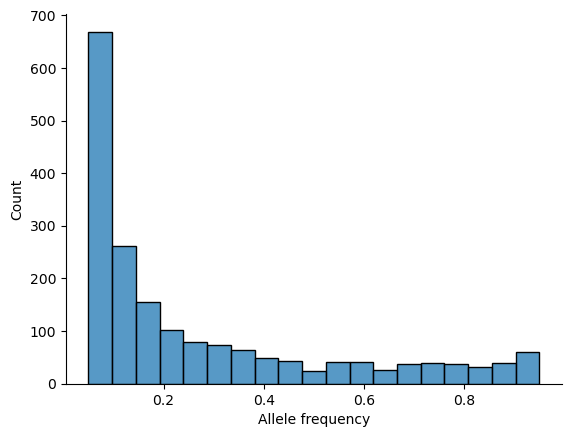

In [31]:
df_SFS = pd.concat([df_lowAF_variants_full, df_unfixed_indels])

# check that there aren't indels and SNVs at the same site. That would be a bioinformatics problem
assert len(df_SFS.drop_duplicates(subset=['SampleID', 'POS'], keep='first')) == len(df_SFS)

sns.histplot(data=df_SFS,
             x='AF'
            )

plt.xlabel('Allele frequency')
sns.despine()
plt.savefig("../results/figures/SFS_indels_SNVs.svg", bbox_inches='tight')

In [32]:
q1 = np.percentile(df_SFS['AF'], q=25)
q2 = np.percentile(df_SFS['AF'], q=50)
q3 = np.percentile(df_SFS['AF'], q=75)

print(f"Median = {q2}")
print(f"IQR = {q3 - q1}")

Median = 0.1468612677054596
IQR = 0.30468564818080635


In [103]:
df_combined_counts = pd.DataFrame(pd.DataFrame(df_SFS.groupby('SampleID')['POS'].count())).reset_index()

df_combined_counts = pd.concat([df_combined_counts,
                                pd.DataFrame({'SampleID': list(set(df_trust_patients.query("F2 <= @F2_max").SampleID) - set(df_combined_counts.SampleID)),
                                              'POS': 0
                                             })
                               ])

df_combined_counts = df_combined_counts.merge(df_trust_patients[['SampleID', 'Lineage']])
df_combined_counts['Lineage'] = df_combined_counts['Lineage'].astype(int).astype(str)

In [104]:
def exponential_LRT(df, test_var, group_var='Lineage', min_count=5):
    
    # only keep groups with at least min_count observations
    keep_groups = pd.DataFrame(df.groupby(group_var)[test_var].count()).query(f"{test_var} >= @min_count").index.values
    
    df = df.query(f"{group_var} in @keep_groups")
        
    # Null model: single lambda
    lambda_null = 1 / df[test_var].mean()
    ll_null = np.sum(np.log(lambda_null) - lambda_null * df[test_var])
    
    params_dict = {'Full': lambda_null}

    # Full model: separate lambda per group
    ll_full = 0
    for g, group_df in df.groupby(group_var):
        lambda_g = 1 / group_df[test_var].mean()
        print(f"λ for {group_var} = {g}: {lambda_g}")
        ll_full += np.sum(np.log(lambda_g) - lambda_g * group_df[test_var])
        params_dict[g] = lambda_g

    # Likelihood ratio test
    LR = 2 * (ll_full - ll_null)
    p_value = st.chi2.sf(LR, df=df[group_var].nunique() - 1)
    
    print(f"λ for full = {lambda_null}")

    print(f"\nLikelihood ratio test statistic: {LR:.3f}")
    print(f"P-value: {p_value:.4g}")
    
    return params_dict

In [105]:
def exponential_distribution(lambda_param, x_min, x_max):
    
    x_vals = np.linspace(x_min, x_max, 100)
    
    return  x_vals, st.expon.pdf(x_vals, scale=1/lambda_param)#[lambda_param * np.exp(-lambda_param * x) for x in x_vals]

# Are unfixed SNVs enriched in certain genes?

In [106]:
# for i, row in h37Rv_genes.query("~Product.str.contains('pseudogene', case=False)").iterrows():
#     assert (row['End'] - row['Start'] + 1) % 3 == 0

In [84]:
def process_unfixed_variants_for_enrichment_test(df_variants):
    '''
    To avoid biases in the enrichment test, we need to do things:
    
    1. For variants that occur in multiple genes (because the coding sequences are overlapping, like Rv3861 and whiB6), each variant needs to be given N rows, where N is the 
        number of genes it occurs in. The variant effect needs to be separately extracted for each case, so that the nonsynonymous and synonymous counts are accurate. The variant
        may be silent in one gene and non-silent in another.
        
    2. Variants that occur on the same haplotype and the same codon need to be deduplicated. If two SNVs occur on the same codon and result in a missense variant, that's not 
        two missense variants; it's only 1. 
    '''
    
    df_lowAF_variants_overlapping_genes = df_variants.query("Region.str.contains(',')").reset_index(drop=True)

    df_lowAF_variants_overlapping_genes_fixed = []

    for i, row in df_lowAF_variants_overlapping_genes.iterrows():

        # split the annotations for the different genes
        split_annot = row['ANN'].split(',')

        for annot in split_annot:

            new_row = row.copy()

            annot_components = annot.split('|')

            variant_type = annot_components[1]
            gene = annot_components[3]
            hgvs_c = annot_components[9]
            hgvs_p = annot_components[10]

            new_row['GENE'] = gene
            new_row['Region'] = gene # also replace this one
            new_row['HGVS_C'] = hgvs_c
            new_row['HGVS_P'] = hgvs_p

            if 'synonymous' in variant_type:
                new_row['Variant_Type'] = 'Silent'
            elif 'missense' in variant_type:
                new_row['Variant_Type'] = 'Missense'
            elif 'stop_lost' in variant_type:
                new_row['Variant_Type'] = 'Stop_Lost'
            elif 'start_lost' in variant_type:
                new_row['Variant_Type'] = 'Start_Lost'
            elif 'stop_gained' in variant_type:
                new_row['Variant_Type'] = 'Nonsense'
            else:
                raise ValueError(f"Couldn't find variant type of {variant_type}")

            df_lowAF_variants_overlapping_genes_fixed.append(pd.DataFrame(new_row).T)

    df_lowAF_variants_overlapping_genes_fixed = pd.concat(df_lowAF_variants_overlapping_genes_fixed)
    
    print(f"Split {len(df_lowAF_variants_overlapping_genes)} variants in overlapping regions into {len(df_lowAF_variants_overlapping_genes_fixed)} variants")
    
    df_recombined_variants = pd.concat([df_variants.query("~Region.str.contains(',')").reset_index(drop=True),
                                        df_lowAF_variants_overlapping_genes_fixed
                                       ])
    
    return df_recombined_variants

In [132]:
longitudinal_WGS_samples = df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2").SampleID.values

# df_lowAF_variants_baseline = df_lowAF_variants_full.query("Sampling_Week <= 2 & SampleID in @longitudinal_WGS_samples").reset_index(drop=True)
df_lowAF_variants_followup = df_lowAF_variants_full.query("Sampling_Week > 2 & Sampling_Week <= 12 & SampleID in @longitudinal_WGS_samples").reset_index(drop=True)

df_lowAF_variants_baseline_for_enrichment_test = process_unfixed_variants_for_enrichment_test(df_lowAF_variants_baseline)
df_lowAF_variants_followup_for_enrichment_test = process_unfixed_variants_for_enrichment_test(df_lowAF_variants_followup)

print(f"{len(df_lowAF_variants_baseline_for_enrichment_test)} baseline unfixed SNVs")
print(f"{len(df_lowAF_variants_followup_for_enrichment_test)} follow-up unfixed SNVs")

Split 5 variants in overlapping regions into 10 variants
Split 3 variants in overlapping regions into 6 variants
786 baseline unfixed SNVs
654 follow-up unfixed SNVs


In [206]:
def run_full_SNV_enrichment_analysis(df_variants):
    
    print(f"Running enrichment analysis on {len(df_variants.drop_duplicates(subset=['SampleID', 'POS', 'REF', 'ALT', ]))} variants in {df_variants.pid.nunique()} pids")
    
    neutral_bg_only = False
    df_enrichment_results = []

    # results on full dataset
    poisson_results, mu = perform_codon_aware_enrichment_test(df_variants, keep_lineages=None, neutral_bg_only=neutral_bg_only)
    poisson_results['Lineage'] = 'Full'
    df_enrichment_results.append(poisson_results)

    # lineage-specific enrichment
    for lineage in np.sort(df_variants['Lineage'].unique()):

        num_samples = df_variants.query("Lineage in [@lineage]").SampleID.nunique()
        print(f"L{str(int(lineage))}, N = {num_samples}")

        if num_samples >= 10:
            poisson_results, _ = perform_codon_aware_enrichment_test(df_variants, keep_lineages=[lineage], neutral_bg_only=neutral_bg_only)
            poisson_results['Lineage'] = str(int(lineage))
            df_enrichment_results.append(poisson_results)

        # perm_results = permutation_test(df_variants, observed, genes_lst, h37Rv_seq, n_perm=1000)

        # final = poisson_results.join(perm_results)

    df_enrichment_results = pd.concat(df_enrichment_results).reset_index().rename(columns={'index': 'Region'})

    # determine flanking gene annotations for the intergenic regions
    noncoding_regions = df_enrichment_results.query("Region.str.contains('NC')").Region.unique()
    noncoding_regions_flanking_genes = {}

    for region in noncoding_regions:

        # increment and decrement by 1 to get the positions at which the flanking genes start and end
        start = h37Rv_coords.query("region==@region").pos.min() - 1
        end = h37Rv_coords.query("region==@region").pos.max() + 1

        upstream_gene = h37Rv_genes.query("End==@start").Symbol.values[0]
        downstream_gene = h37Rv_genes.query("Start==@end").Symbol.values[0]

        noncoding_regions_flanking_genes[region] = f"{upstream_gene},{downstream_gene}"

    df_enrichment_results[['Gene1', 'Gene2']] = df_enrichment_results['Region'].map(noncoding_regions_flanking_genes).str.split(',', expand=True)

    # add lineages and participant counts
    df_enrichment_results['Num_pids'] = np.nan
    df_enrichment_results['Lineages_Found_In'] = np.nan

    for i, row in df_enrichment_results.query("Lineage=='Full'").iterrows():
        gene = row['Region']
        
        df_enrichment_results.loc[i, ['Num_pids', 'Lineages_Found_In']] = [df_variants.query("Region==@gene").pid.nunique(),
                                                                           ','.join(np.sort(df_variants.query("Region==@gene").Lineage.unique().astype(int).astype(str)))
                                                                          ]

    df_mut_rate = pd.DataFrame(mu, index=[0]).T.reset_index()

    df_mut_rate.columns = ['REF', 'ALT', 'MutRate']

    df_mut_rate['Type'] = np.nan

    df_mut_rate.loc[(df_mut_rate['REF'].isin(['A', 'G'])) & (df_mut_rate['ALT'].isin(['A', 'G'])), 'Type'] = 'Transition'
    df_mut_rate.loc[(df_mut_rate['REF'].isin(['C', 'T'])) & (df_mut_rate['ALT'].isin(['C', 'T'])), 'Type'] = 'Transition'

    df_mut_rate['Type'] = df_mut_rate['Type'].fillna('Transversion')

    return df_enrichment_results, df_mut_rate.sort_values('MutRate', ascending=False).reset_index(drop=True)

In [207]:
df_baseline_SNV_enrichment, df_mut_rate_baseline = run_full_SNV_enrichment_analysis(df_lowAF_variants_baseline_for_enrichment_test)

Running enrichment analysis on 781 variants in 261 pids
L1, N = 1
L2, N = 126
L3, N = 22
L4, N = 112


In [232]:
df_mut_rate_baseline.MutRate.values

array([1.16551885e-04, 1.14692203e-04, 1.10756230e-04, 1.06808304e-04,
       5.93235533e-05, 4.41379919e-05, 4.21958732e-05, 3.53035482e-05,
       3.10345256e-05, 2.28434724e-05, 1.18647107e-05, 6.59310519e-06])

In [233]:
df_mut_rate_baseline.query("Type=='Transition'").MutRate.mean() / df_mut_rate_baseline.query("Type=='Transversion'").MutRate.mean()

3.5437372789460273

In [234]:
df_followup_SNV_enrichment, df_mut_rate_followup = run_full_SNV_enrichment_analysis(df_lowAF_variants_followup_for_enrichment_test)

Running enrichment analysis on 651 variants in 206 pids
L2, N = 105
L3, N = 11
L4, N = 90


In [237]:
df_mut_rate_followup

,REF,ALT,MutRate,Type
0,T,C,0.000107,Transition
1,C,T,0.000104,Transition
2,A,G,0.000095,Transition
3,G,A,0.000091,Transition
4,A,C,0.000041,Transversion
5,T,G,0.000034,Transversion
6,G,T,0.000030,Transversion
7,C,A,0.000030,Transversion
8,C,G,0.000023,Transversion
9,G,C,0.000020,Transversion


In [239]:
df_mut_rate_followup.query("Type=='Transition'").MutRate.mean() / df_mut_rate_followup.query("Type=='Transversion'").MutRate.mean()

4.196140754022506

In [202]:
# h37Rv_codons = []

# for i, row in h37Rv_genes.query("~Product.str.contains('pseudogene', case=False)").iterrows():
#     start, end, sense = row.Start, row.End, row.Strand
    
#     seq = str(h37Rv_seq.seq[start-1:end])

#     if sense != '+':
#         seq = str(Seq.Seq(seq).reverse_complement())

#     for k in range(0, len(seq), 3):
#         codon = seq[k:k+3]
        
#         if len(codon) != 3:
#             print(row['Symbol'])
#         else:
#             h37Rv_codons.append(codon)
        
# print(f"{len(h37Rv_codons)} codons")

# df_codon_usage_H37Rv = pd.DataFrame(pd.DataFrame(h37Rv_codons)[0].value_counts()).reset_index()
# df_codon_usage_H37Rv.columns = ['Codon', 'Count']

1344117 codons


In [341]:
# df_codon_usage_H37Rv.head()

,Codon,Count
0,GCC,80439
1,GGC,68975
2,CTG,67619
3,GCG,65135
4,GAC,56646


In [240]:
def qq_plot_with_labels(df, pval_col="nonsyn_pval", gene_col="Region", p_label_thresh=1e-5, title=None, saveName=None):
    """
    QQ plot of gene-level p-values with labels for extreme points.
    
    df: DataFrame with gene names and p-values
    pval_col: column containing p-values
    gene_col: column containing gene names
    p_label_thresh: threshold below which genes are labeled
    """
    # Extract p-values and sort
    pvals = df[pval_col].values
    genes = df[gene_col].values
    
    mask = np.isfinite(pvals) & (pvals > 0)
    pvals = pvals[mask]
    genes = genes[mask]
    
    pvals_sorted_idx = np.argsort(pvals)
    pvals_sorted = pvals[pvals_sorted_idx]
    genes_sorted = genes[pvals_sorted_idx]

    n = len(pvals_sorted)
    expected = -np.log10((np.arange(1, n+1) - 0.5) / n)
    observed = -np.log10(pvals_sorted)

    plt.figure(figsize=(6,6))
    plt.scatter(expected, observed, s=20)

    # Diagonal line
    plt.plot(expected, expected, color="black", linestyle="--", linewidth=1)

    # Label extreme points
    for obs, exp, gene, p in zip(observed, expected, genes_sorted, pvals_sorted):
        if p < p_label_thresh:
            
            if 'NC_' in gene:
                name = noncoding_regions_flanking_genes[gene].replace(',', '-')
            else:
                name = gene
                
            plt.text(exp+0.05, obs+0.05, name, fontsize=8, ha='left', va='bottom', rotation=0,  style='italic')

    plt.xlabel("Expected -log10(p)")
    plt.ylabel("Observed -log10(p)")
    
    if title is not None:
        plt.title(title)
    else:
        plt.title("QQ plot of Gene-level Poisson p-values")
        
    plt.tight_layout()
    sns.despine()
    
    if saveName is None:
        plt.show()
    else:
        plt.savefig(saveName, bbox_inches='tight')


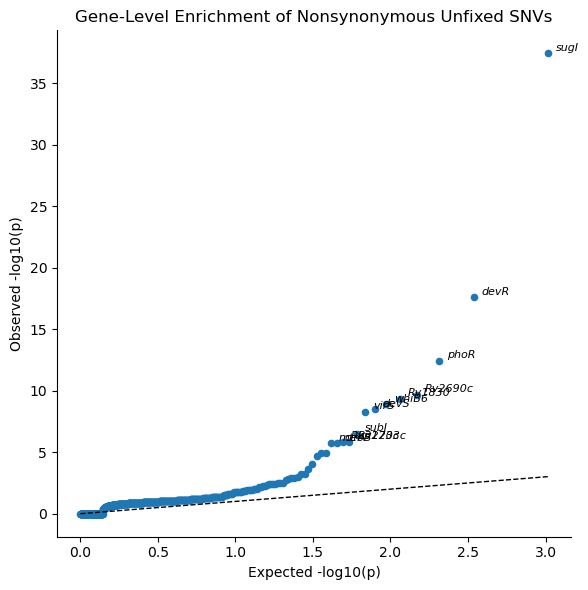

In [241]:
qq_plot_with_labels(df_baseline_SNV_enrichment.query("Lineage=='Full'"), 
                    p_label_thresh=1e-5,
                    title="Gene-Level Enrichment of Nonsynonymous Unfixed SNVs",
                    saveName="../results/figures/baseline_QQ_plot.svg",
                   )


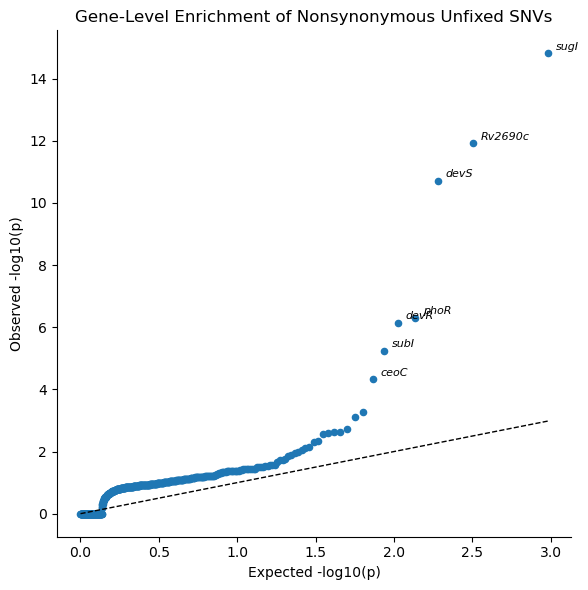

In [242]:
qq_plot_with_labels(df_followup_SNV_enrichment.query("Lineage=='Full'"), 
                    p_label_thresh=5e-5,
                    title="Gene-Level Enrichment of Nonsynonymous Unfixed SNVs",
                    saveName="../results/figures/followup_QQ_plot.svg",
                   )


In [243]:
sample_lineages = pd.read_csv("./data/trees/samples_lineage_annot.tsv", sep='\t')

LinToColor_Dict = {"1": "#DF83AC".lower(),
                   "2": "#7098CB".lower(),
                   "3": "#815D9F".lower(),
                   "4": "#E76956".lower(),
                   "4 DUP": "#E76956".lower(),
                   "Other": "white"
                   # "5": "#B67548",
                   # "6": "#6AB79E",
                   # "8": "#E4515B",
                   # "M.bovis": "white",
                  }

sample_lineages['Color'] = sample_lineages['Lineage'].map(LinToColor_Dict)
sample_lineages['Type'] = 'label'

sample_lineages[['SampleID', 'Type', 'Color']].to_csv("./data/trees/samples_lineage_colors.txt", sep='\t', index=False)

In [97]:
"#DF83AC".lower()

'#df83ac'

In [110]:
sample_lineages.query("SampleID=='MFS-35'")

,SampleID,Lineage,Color,Type
49,MFS-35,4 DUP,#e76956,label


In [104]:
df_combined_results.query("Gene1=='Rv0010c'")

,Gene,Observed,Expected,Fold_Enrichment,Enrich_pval,Deplete_pval,Twosided_pval,Start,End,Length,Lineage,Bonferroni_pval,Gene1,Gene2,Lineages_Found_In,Midpoint,Neg_Log_Enrich_pval,Significant
16,NC_9,3,0.034483,87.000572,0.000007,1.0,0.000013,13559,13713,155,Full,0.004788,Rv0010c,Rv0011c,2,13636.0,5.176576,0.0
726,NC_9,3,0.019541,153.524763,0.000001,1.0,0.000002,13559,13713,155,2,0.000533,Rv0010c,Rv0011c,NaN,13636.0,5.911685,1.0


In [189]:
def plot_SNV_enrichment_results(df_combined_results, significance_thresh=1e-2, saveName=None):

    df_enriched_plot = df_combined_results.query("Lineage=='Full'").reset_index(drop=True)

    df_enriched_plot.loc[df_enriched_plot['Region'].str.startswith('NC_'), 'Enrich_pval'] = df_enriched_plot.loc[df_enriched_plot['Region'].str.startswith('NC_')]['total_pval']
    df_enriched_plot.loc[~df_enriched_plot['Region'].str.startswith('NC_'), 'Enrich_pval'] = df_enriched_plot.loc[~df_enriched_plot['Region'].str.startswith('NC_')]['nonsyn_pval']

    df_enriched_plot.loc[df_enriched_plot['Region'].str.startswith('NC_'), 'Bonferroni_pval'] = df_enriched_plot.loc[df_enriched_plot['Region'].str.startswith('NC_')]['total_pval_Bonferroni']
    df_enriched_plot.loc[~df_enriched_plot['Region'].str.startswith('NC_'), 'Bonferroni_pval'] = df_enriched_plot.loc[~df_enriched_plot['Region'].str.startswith('NC_')]['nonsyn_pval_Bonferroni']

    df_enriched_plot['Midpoint'] = np.mean([df_enriched_plot['Start'], df_enriched_plot['End']], axis=0)

    y_axis_var = 'Neg_Log_Enrich_pval'

    df_enriched_plot['Neg_Log_Enrich_pval'] = -np.log10(df_enriched_plot['Enrich_pval'])

    df_enriched_plot.loc[df_enriched_plot['Bonferroni_pval'] <= significance_thresh, 'Significant'] = 1
    df_enriched_plot.loc[df_enriched_plot['Bonferroni_pval'] > significance_thresh, 'Significant'] = 0

    font_size = 15

    fig, ax = plt.subplots(figsize=(20, 8))

    sns.scatterplot(data=df_enriched_plot.sort_values('Neg_Log_Enrich_pval', ascending=True), # plot gray points lower in case they are overlain so that you can see the red ones
                    x='Midpoint',
                    y=y_axis_var,
                    hue='Significant',
                    palette={1: 'red', 0: 'lightgray'},
                    legend=False,
                    ax=ax,
                    s=100,
                    linewidth=0.5,
                   )

    for i, row in df_enriched_plot.query("Significant==1").iterrows():

        if 'NC' in row['Region']:
            name = f"{row['Gene1']}-{row['Gene2']}"
        else:
            name = row['Region']

        plt.text(row['Midpoint']+1000, row[y_axis_var]+0.75, name, fontsize=font_size, ha='left', va='bottom', rotation=0,  style='italic')

    # ax.ticklabel_format(style='plain', axis='x')
    from matplotlib.ticker import StrMethodFormatter

    ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

    sns.despine()

    ax.set_xticklabels(ax.get_xticklabels(), fontsize=font_size)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=font_size)

    plt.xlabel('Genomic Coordinate', fontsize=font_size)
    plt.ylabel('-log10(p)', fontsize=font_size)

    if saveName is None:
        plt.show()
    else:
        plt.savefig(saveName, bbox_inches='tight')
        
    return df_enriched_plot

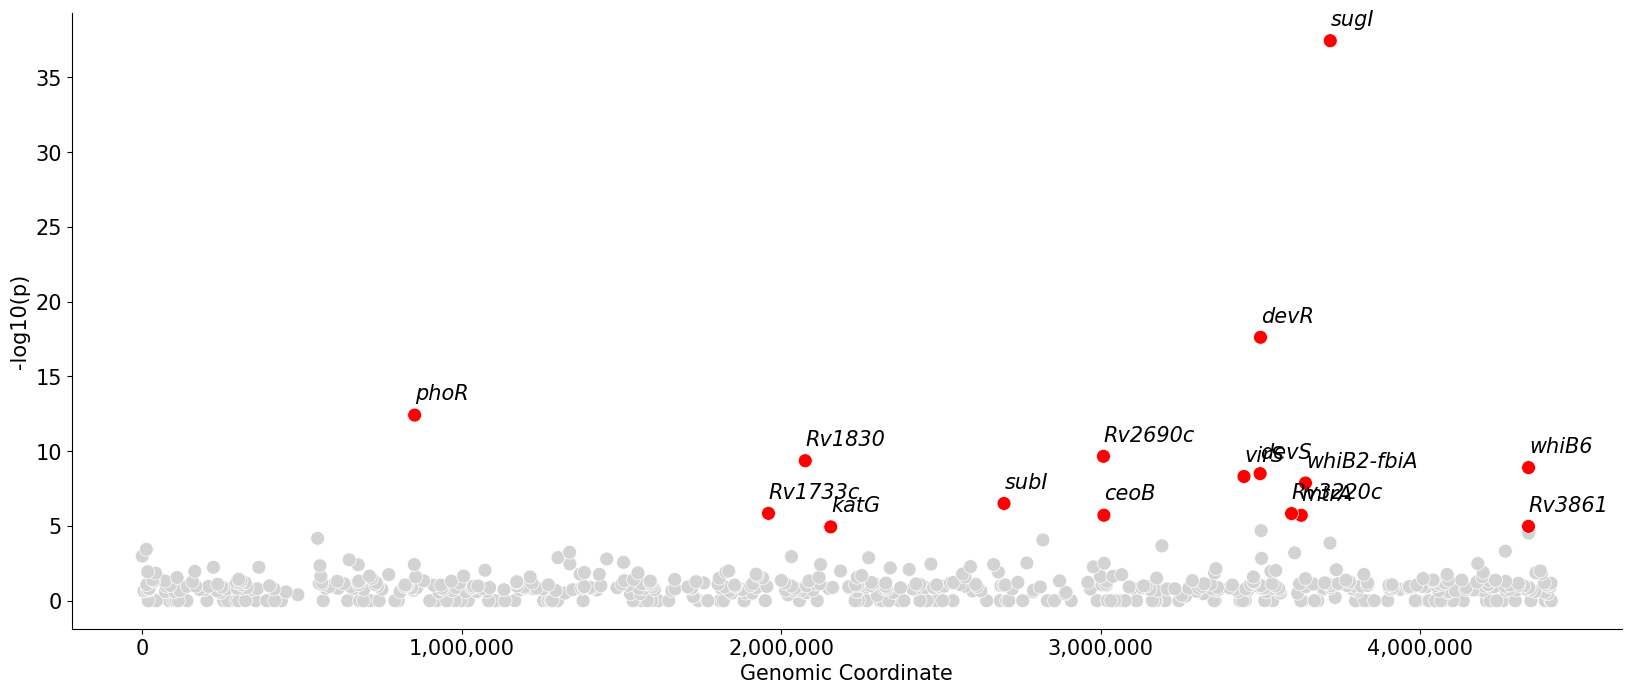

In [210]:
df_baseline_enrichment_final = plot_SNV_enrichment_results(df_baseline_SNV_enrichment, significance_thresh=1e-2, saveName="../results/figures/Manhattan_plot_SNVs_baseline.svg")

In [196]:
enriched_regions = df_baseline_enrichment_final.query("Bonferroni_pval <= 0.01").sort_values('Enrich_pval').Region.values
print(len(enriched_regions))

16


In [198]:
enriched_regions

array(['sugI', 'devR', 'phoR', 'Rv2690c', 'Rv1830', 'whiB6', 'devS',
       'virS', 'NC_2516', 'subI', 'Rv1733c', 'Rv3220c', 'ceoB', 'mtrA',
       'Rv3861', 'katG'], dtype=object)

In [211]:
df_baseline_enrichment_final.query("Bonferroni_pval <= 0.01").sort_values('Enrich_pval')[['Region', 'Num_pids']]

,Region,Num_pids
62,sugI,25.0
77,devR,7.0
78,phoR,5.0
61,Rv2690c,9.0
82,Rv1830,6.0
250,whiB6,3.0
196,devS,7.0
268,virS,6.0
525,NC_2516,4.0
260,subI,4.0


In [197]:
df_lowAF_variants_baseline_for_tree = df_lowAF_variants_baseline_for_enrichment_test.copy()

df_lowAF_variants_baseline_for_tree['Present'] = 1

df_lowAF_variants_baseline_for_tree = pd.DataFrame(df_lowAF_variants_baseline_for_tree.query("Region in @enriched_regions").groupby(['SampleID', 'Region'])['Present'].max()).reset_index()

df_lowAF_variants_baseline_for_tree = df_lowAF_variants_baseline_for_tree.pivot(index='SampleID', columns='Region', values='Present')

df_lowAF_variants_baseline_for_tree = df_lowAF_variants_baseline_for_tree.reset_index()

df_lowAF_variants_baseline_for_tree = pd.concat([df_lowAF_variants_baseline_for_tree,
                                                 pd.DataFrame({'SampleID': list(set(df_baseline_samples.SampleID) - set(df_lowAF_variants_baseline_for_tree.SampleID))})
                                                ])

df_lowAF_variants_baseline_for_tree = df_lowAF_variants_baseline_for_tree.set_index('SampleID')

df_lowAF_variants_baseline_for_tree = df_lowAF_variants_baseline_for_tree.fillna(0).astype(int)

assert len(set(enriched_regions) - set(df_lowAF_variants_baseline_for_tree.columns)) == 0

df_lowAF_variants_baseline_for_tree.to_csv(f"../results/{len(enriched_regions)}_enriched_baseline_regions.csv")

In [119]:
df_baseline_SNV_enrichment.query("Region in ['Rv3861', 'whiB6'] & Lineage=='Full'")

,Region,syn_pval,syn_fold,nonsyn_pval,nonsyn_fold,total_pval,total_fold,O_syn,O_nonsyn,O_total,...,syn_pval_Bonferroni,nonsyn_pval_Bonferroni,total_pval_Bonferroni,Start,End,Length,Lineage,Gene1,Gene2,Lineages_Found_In
249,Rv3861,0.017565,56.430089,1.057378e-05,74.465950,4.504050e-07,68.956099,1.0,3.0,4.0,...,1.0,5.466645e-03,2.634869e-04,4337946,4338272,327,Full,NaN,NaN,2
250,whiB6,0.018299,54.145725,1.235977e-09,115.237198,7.379138e-11,96.997199,1.0,5.0,6.0,...,1.0,6.390003e-07,4.316795e-08,4338171,4338521,351,Full,NaN,NaN,2


In [42]:
sample = 'MFS-274'
pos = 4338242
df_single_sample_variants = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/{sample}/freebayes/lowAF_SNPs.csv")

In [43]:
df_single_sample_variants.query("POS==@pos")['ANN'].values[0]

'A|stop_gained|HIGH|whiB6|Rv3862c|transcript|CCP46691|protein_coding|1/1|c.280C>T|p.Gln94*|280/351|280/351|94/116||,A|synonymous_variant|LOW|Rv3861|Rv3861|transcript|CCP46690|protein_coding|1/1|c.297G>A|p.Leu99Leu|297/327|297/327|99/108||WARNING_TRANSCRIPT_NO_START_CODON'

In [45]:
df_lowAF_variants_full.query("Region.str.contains(',')").Region.unique()

array(['Rv3861,whiB6', 'Rv1413,Rv1414', 'Rv1954A,Rv1954c', 'Rv1152,omt',
       'Rv2067c,cobI', 'cyp139,pks11', 'Rv2191,trpD'], dtype=object)

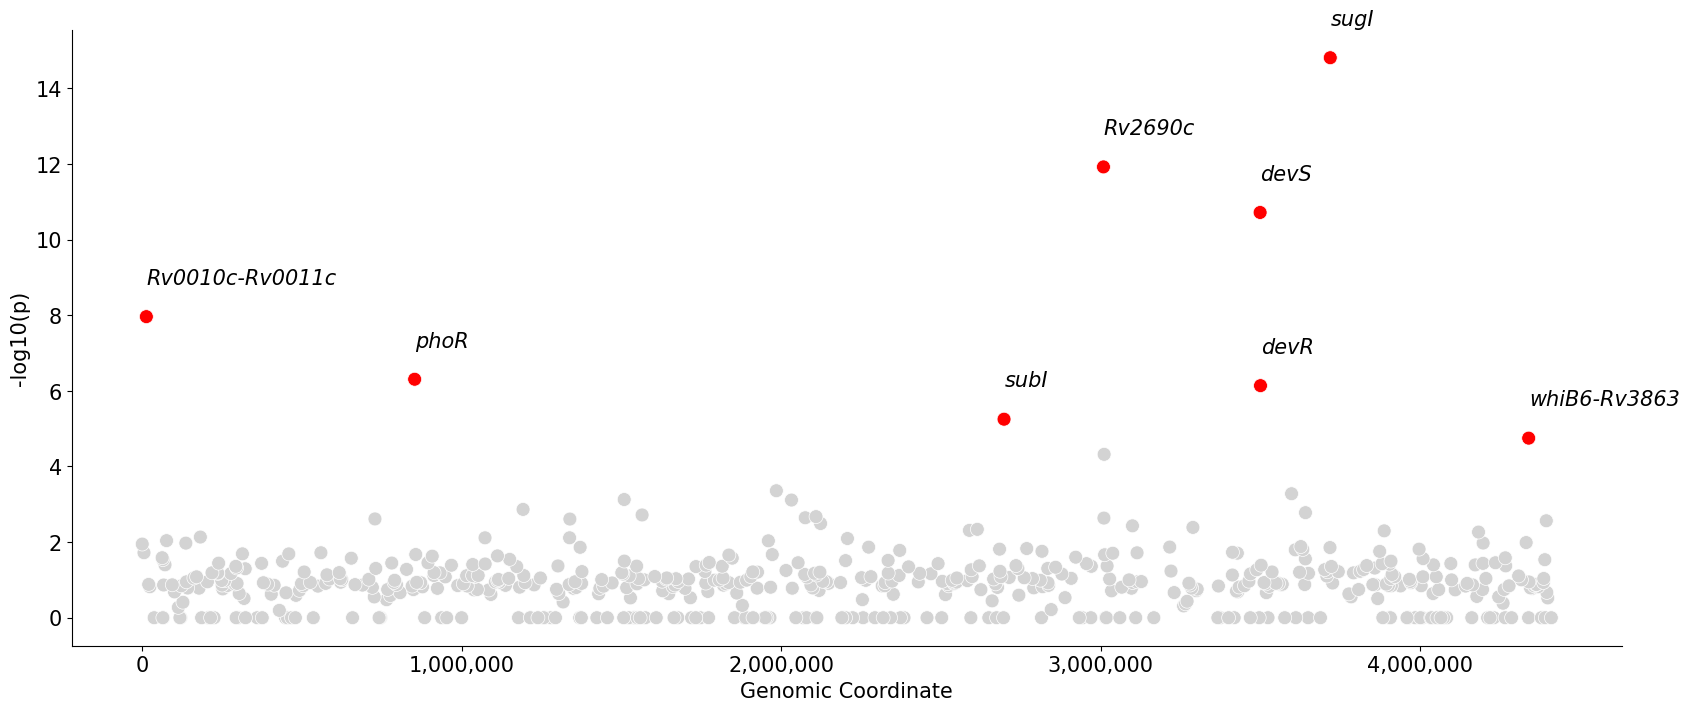

In [246]:
plot_SNV_enrichment_results(df_followup_SNV_enrichment, significance_thresh=1e-2, saveName="../results/figures/Manhattan_plot_SNVs_followup.svg")

In [46]:
# gene_groups = {'sugI': 'Transport',
#                'devR': 'Two-component system',
#                'phoR': 'Two-component system',
#                'devS': 'Two-component system',
#                'Rv1830': 'Transcription factor',
#                'subI': 'Transport',
#                'ceoC': 'Transport',
#                'Rv2690c': 'Transport',
#                'NC_2516': 'Transcription factor',
#                'virS': 'Transcription factor',
#                'NC_2982': 'Transcription factor',
#                'NC_2568': 'Transport',
#                'NC_9': 'Other',
#                'Rv1733c': 'Other'
#               }

# df_combined_results['Midpoint'] = np.mean([df_combined_results['Start'], df_combined_results['End']], axis=0)
# df_combined_results['Group'] = df_combined_results['Gene'].map(gene_groups).fillna('NotSignificant')

# y_axis_var = 'Neg_Log_Enrich_pval'
# # y_axis_var = 'Fold_Enrichment'
# hue_thresh = 1e-2

# df_combined_results['Neg_Log_Enrich_pval'] = -np.log10(df_combined_results['Enrich_pval'])

# df_combined_results.loc[df_combined_results['Bonferroni_pval'] <= hue_thresh, 'Significant'] = 1
# df_combined_results.loc[df_combined_results['Bonferroni_pval'] > hue_thresh, 'Significant'] = 0

# font_size = 15

# fig, ax = plt.subplots(figsize=(20, 8))

# point_palette = {'Transcription factor': '#215F9A',
#                          'Two-component system': '#78206E', 
#                          'Transport': '#3B7D23',
#                          'Other': 'darkgray', 
#                          'NotSignificant': 'whitesmoke'}

# text_palette = {'Transcription factor': '#215F9A',
#                          'Two-component system': '#78206E', 
#                          'Transport': '#3B7D23',
#                          'Other': 'black', 
#                          'NotSignificant': 'whitesmoke'}

# sns.scatterplot(data=df_combined_results.query("Lineage=='Full'").sort_values('Neg_Log_Enrich_pval', ascending=True), # plot gray points lower in case they are overlain so that you can see the red ones
#                 x='Midpoint',
#                 y=y_axis_var,
#                 hue='Group',
#                 palette=point_palette,
#                 legend=False,
#                 ax=ax,
#                 s=100
#                )

# for i, row in df_combined_results.query("Lineage=='Full'").query("Significant==1").iterrows():
    
#     if 'NC' in row['Gene']:
#         name = f"{row['Gene1']}-{row['Gene2']}"
#     else:
#         name = row['Gene']
    
#     plt.text(row['Midpoint']+1000, row[y_axis_var]+0.75, name, fontsize=font_size, ha='left', va='bottom', rotation=0,  style='italic', color=text_palette[row['Group']])

# # ax.ticklabel_format(style='plain', axis='x')
# from matplotlib.ticker import StrMethodFormatter

# ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# sns.despine()

# ax.set_xticklabels(ax.get_xticklabels(), fontsize=font_size)
# ax.set_yticklabels(ax.get_yticklabels(), fontsize=font_size)

# plt.xlabel('Genomic Coordinate', fontsize=font_size)
# plt.ylabel('-log10(p)', fontsize=font_size)

# plt.savefig("../results/figures/Manhattan_plot_SNVs_for_defense.svg", bbox_inches='tight')

# Unfixed Resistance-Associated Mutations

In [8]:
df_combined_variants = pd.concat([df_variants_full, df_indels.query("pid in @df_variants.pid")]).reset_index(drop=True)
df_combined_variants['Variant'] = df_combined_variants['SNP']
df_combined_variants['Variant'] = df_combined_variants['Variant'].fillna(df_combined_variants['Indel'])

df_combined_variants_baseline = pd.concat([df_variants_baseline, df_indels.query("SampleID in @df_variants_baseline.SampleID")]).reset_index(drop=True)
df_combined_variants_baseline['Variant'] = df_combined_variants_baseline['SNP']
df_combined_variants_baseline['Variant'] = df_combined_variants_baseline['Variant'].fillna(df_combined_variants_baseline['Indel'])

In [9]:
df_combined_lowAF_variants = df_combined_variants.query("AF >= 0.05 & AF <= 0.95")
print(len(df_combined_lowAF_variants))

df_combined_lowAF_variants.loc[df_combined_lowAF_variants['Variant_Type']=='Silent', 'variant'] = df_combined_lowAF_variants.loc[df_combined_lowAF_variants['Variant_Type']=='Silent']['GENE'] + '_' + df_combined_lowAF_variants.loc[df_combined_lowAF_variants['Variant_Type']=='Silent']['HGVS_C']
df_combined_lowAF_variants.loc[df_combined_lowAF_variants['Variant_Type']!='Silent', 'variant'] = df_combined_lowAF_variants.loc[df_combined_lowAF_variants['Variant_Type']!='Silent']['GENE'] + '_' + df_combined_lowAF_variants.loc[df_combined_lowAF_variants['Variant_Type']!='Silent']['HGVS_P']

WHO_regions = df_who_variants.gene.unique()
WHO_resistance_regions = df_who_variants.loc[df_who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].gene.unique()

df_lowAF_variants_WHO_annot = df_combined_lowAF_variants.query("Variant_Type != 'Silent'").merge(df_who_variants, how='left', on='variant')
df_lowAF_variants_WHO_annot[['GENE1', 'GENE2']] = df_lowAF_variants_WHO_annot['GENE'].str.split('-', expand=True)

df_lowAF_variants_WHO_annot['longitudinal'] = df_lowAF_variants_WHO_annot['pid'].isin(pids_with_same_lineage_and_low_F2).astype(int)

1820


In [187]:
df_who_variants.loc[df_who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].query("gene in ['rpsL']")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
46687,Streptomycin,rpsL,p.Lys43Arg,rpsL_p.Lys43Arg,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,3489.0,3409.0,...,NaN,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1
46691,Streptomycin,rpsL,p.Lys88Arg,rpsL_p.Lys88Arg,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,1013.0,991.0,...,NaN,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1
46692,Streptomycin,rpsL,p.Lys88Gln,rpsL_p.Lys88Gln,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,9.0,6.0,...,Previous WHO guidance,2) Assoc w R - Interim,NaN,No change,NaN,NaN,yes,Prev. WHO,NaN,1
46693,Streptomycin,rpsL,p.Lys88Met,rpsL_p.Lys88Met,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,23.0,23.0,...,NaN,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1


In [179]:
df_who_variants.query("effect=='upstream_gene_variant'").query("gene in ['rpsL']")['genomic position'].min()

'781326'

In [180]:
df_who_variants.query("effect=='upstream_gene_variant'").query("gene in ['rpsL']")['FINAL CONFIDENCE GRADING'].value_counts()

FINAL CONFIDENCE GRADING
3) Uncertain significance    63
5) Not assoc w R              2
Name: count, dtype: int64

In [181]:
df_who_variants.loc[df_who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].query("gene in ['whiB2', 'fbiA']")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
8358,Delamanid,fbiA,LoF,fbiA_LoF,1,LoF,"(see ""Genomic_coordinates"" sheet)",0.0,0.0,0.0,...,Selection evidence,2) Assoc w R - Interim,Confers DLM-PMD cross-resistance,New AwRI,NaN,NaN,yes,Selection,R,5
8429,Delamanid,fbiA,p.Val329fs,fbiA_p.Val329fs,1,frameshift,"(see ""Genomic_coordinates"" sheet)",0.0,0.0,0.0,...,Indel frameshift or premature stop codon (LoF),2) Assoc w R - Interim,NaN,New AwRI,NaN,NaN,no,NaN,NaN,5


In [260]:
df_trust_patients.query("pid=='T0126'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Kraken_Unclassified_Percent,Median_Depth,Perc_Sites_20x,Sampling_Week,Paired_Sample_Num
353,T0126,S0126-01,MFS-590,MFS-590_lib65696,NaN,NaN,1.0,354.25,1.0,0.9881,...,NaN,0.013356,4.1.2.1,4.1.i1.1.1.1,4.0,0.46,345.0,98.846047,1,1
354,T0126,S0126-05,MFS-591,MFS-591_lib65697,NaN,NaN,1.0,298.08,1.0,0.9898,...,NaN,0.012236,4.1.2.1,4.1.i1.1.1.1,4.0,0.57,294.0,98.819775,5,2


In [395]:
for i, row in df_lowAF_variants_WHO_annot.iterrows():
    
    if not pd.isnull(row['GENE1']) and not pd.isnull(row['GENE2']):
        
        gene1 = row['GENE1']
        gene2 = row['GENE2']
        
        sense_1 = h37Rv_regions.query("Name==@gene1").Strand.values[0]
        sense_2 = h37Rv_regions.query("Name==@gene2").Strand.values[0]
        
        if sense_1 == '-':
            end_1 = h37Rv_regions.query("Name==@gene1").Stop.values[0]
            df_lowAF_variants_WHO_annot.loc[i, 'Variant_1'] = gene1 + '_c.-' + str(row['POS'] - end_1) + str(Seq.Seq(row['REF']).reverse_complement()) + '>' + str(Seq.Seq(row['ALT']).reverse_complement())
        
        if sense_2 == '+':
            start_2 = h37Rv_regions.query("Name==@gene2").Start.values[0]
            df_lowAF_variants_WHO_annot.loc[i, 'Variant_2'] = gene2 + '_c.-' + str(start_2 - row['POS']) + row['REF'] + '>' + row['ALT']

In [398]:
df_lowAF_variants_WHO_annot.query("(Variant_Type not in ['Silent', 'Intergenic']) & (GENE in @WHO_resistance_regions | GENE1 in @WHO_resistance_regions | GENE2 in @WHO_resistance_regions)")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'GENE', 'HGVS_C', 'HGVS_P', 'GENE1', 'GENE2', 'Sampling_Week', 'Variant_1', 'Variant_2', 'Variant_Type', 'longitudinal']].sort_values(['pid', 'POS', 'Sampling_Week'])#.merge(TRUST_phenos, how='left')

,pid,SampleID,POS,REF,ALT,AF,GENE,HGVS_C,HGVS_P,GENE1,GENE2,Sampling_Week,Variant_1,Variant_2,Variant_Type,longitudinal
682,T0058,MFS-546,6923,T,G,0.071429,gyrB,c.1684T>G,p.Phe562Val,gyrB,None,1,nan,nan,Missense,1
684,T0058,MFS-547,6923,T,G,0.112392,gyrB,c.1684T>G,p.Phe562Val,gyrB,None,9,nan,nan,Missense,1
395,T0069,MFS-348,2155174,A,G,0.110145,katG,c.938T>C,p.Ile313Thr,katG,None,1,nan,nan,Missense,1
706,T0106,MFS-56,3640843,T,C,0.757202,fbiA,c.301T>C,p.Trp101Arg,fbiA,None,1,nan,nan,Missense,1
832,T0210,MFS-639,6078,G,T,0.092784,gyrB,c.839G>T,p.Gly280Val,gyrB,None,6,nan,nan,Missense,1
332,T0310,MFS-315,2288760,G,A,0.051118,pncA,c.482C>T,p.Ala161Val,pncA,None,1,nan,nan,Missense,1
452,T0331,MFS-397,2153995,G,T,0.313167,katG,c.2117C>A,p.Ala706Glu,katG,None,1,nan,nan,Missense,1
453,T0331,MFS-397,2154800,A,G,0.258675,katG,c.1312T>C,p.Trp438Arg,katG,None,1,nan,nan,Missense,1
454,T0331,MFS-397,2155667,A,G,0.107807,katG,c.445T>C,p.Trp149Arg,katG,None,1,nan,nan,Missense,1
455,T0331,MFS-397,2155819,T,C,0.073930,katG,c.293A>G,p.Tyr98Cys,katG,None,1,nan,nan,Missense,1


In [160]:
search_variants_lst = ['whiB2_c.-115T>G', 'fbiA_c.-287T>G', 'whiB2_c.-267T>G', 'fbiA_c.-135T>G', 
                       'gyrB_p.Phe562Val', 'katG_p.Ile313Thr',
                       'whiB2_c.-266G>T', 'fbiA_c.-136G>T',
                       'fbiA_p.Trp101Arg', 
                       'rpsL_c.-200G>A',
                       'gyrB_p.Gly280Val',
                       'pncA_p.Ala161Val',
                       'katG_p.Ala706Glu',
                       'katG_p.Trp438Arg',
                       'katG_p.Trp149Arg',
                       'katG_p.Tyr98Cys',
                       'fbiC_p.Phe295Leu'
                      ]

df_who_variants.query("variant in @search_variants_lst")[['variant', 'drug', 'Present_SOLO_R', 'Present_SOLO_S', 'Present_R', 'Present_S']]

,variant,drug,Present_SOLO_R,Present_SOLO_S,Present_R,Present_S
6320,fbiA_c.-136G>T,Clofazimine,0.0,1.0,0.0,1.0
22561,katG_p.Trp149Arg,Isoniazid,2.0,0.0,4.0,0.0
22654,katG_p.Tyr98Cys,Isoniazid,2.0,0.0,4.0,0.0


In [145]:
df_who_variants.query("effect=='upstream_gene_variant' & gene=='whiB2'")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1


In [195]:
df_lowAF_variants_WHO_annot.query("GENE1 in ['fabG1', 'inhA'] | GENE2 in ['fabG1', 'inhA']")

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,longitudinal,Variant_1,Variant_2


In [19]:
# INH_unfixed_muts = []
# INH_genes = df_who_variants.query("drug=='Isoniazid'").gene.unique()

# for pid in missing_INH:
    
#     for sample in df_trust_patients.query("pid==@pid").SampleID.unique():
#         INH_unfixed_muts.append(get_unfixed_resistance_associated_mutations(sample))
        
# INH_unfixed_muts = pd.concat(INH_unfixed_muts).merge(df_trust_patients[['pid', 'SampleID']])

# INH_unfixed_muts.query("GENE.str.contains('|'.join(@INH_genes))")

In [55]:
EMB_unfixed_muts = []
EMB_genes = df_who_variants.query("drug=='Ethambutol'").gene.unique()

for pid in missing_EMB:
    
    for sample in df_trust_patients.query("pid==@pid").SampleID.unique():
        EMB_unfixed_muts.append(get_unfixed_resistance_associated_mutations(sample))
        
EMB_unfixed_muts = pd.concat(EMB_unfixed_muts).merge(df_trust_patients[['pid', 'SampleID']])

EMB_unfixed_muts.query("GENE.str.contains('|'.join(@EMB_genes))")

,POS,REF,ALT,QUAL,FILTER,GENE,HGVS_C,HGVS_P,NS,DP,...,variant,drug,confidence,Present_SOLO_S,Present_SOLO_R,OR_SOLO,Present_S,Present_R,SampleID,pid


In [238]:
PZA_unfixed_muts = []
PZA_genes = df_who_variants.query("drug=='Pyrazinamide'").gene.unique()

for pid in missing_PZA:
    
    for sample in df_trust_patients.query("pid==@pid").SampleID.unique():
        PZA_unfixed_muts.append(get_unfixed_resistance_associated_mutations(sample))
        
PZA_unfixed_muts = pd.concat(PZA_unfixed_muts).merge(df_trust_patients[['pid', 'SampleID']])

PZA_unfixed_muts.query("GENE.str.contains('|'.join(@PZA_genes))")

,POS,REF,ALT,QUAL,FILTER,GENE,HGVS_C,HGVS_P,NS,DP,...,variant,drug,confidence,Present_SOLO_S,Present_SOLO_R,OR_SOLO,OR_SOLO_exact_lb,OR_SOLO_exact_ub,SampleID,pid


# Changes in Unfixed Variants

In [10]:
def convert_variants_to_matrices(df_variants, variant_col, baseline_only=False):
    
    variant_matrix = []

    # fixed_AF_thresh = 1.2
    
    # baseline samples only, so if the column isn't there, assign 1. If doing longitudinal analysis, the Paired_Sample_Num column needs to be added before!
    if baseline_only:
        df_variants['Paired_Sample_Num'] = 1
    else:
        assert sum(pd.isnull(df_variants['Paired_Sample_Num'])) == 0

    # use df_lowAF_variants because the signal for low frequency variants gets drowned out by tons of fixed SNPs
    for pid in df_variants.pid.unique():

        single_pid_matrix = df_variants.query("pid==@pid").pivot(index='Paired_Sample_Num', columns=variant_col, values='AF')
        
        single_pid_matrix.index = pid + '_' + single_pid_matrix.index.astype(str)

        # variant_matrix.append(single_pid_matrix[keep_variants])
        variant_matrix.append(single_pid_matrix)

    variant_matrix = pd.concat(variant_matrix).fillna(0)

    sample_1_variants = variant_matrix.loc[variant_matrix.index.str.endswith('_1')]
    
    # remove the suffixes from the indexes
    sample_1_variants.index = sample_1_variants.index.str.split('_').str[0]
    
    if not baseline_only:
        sample_2_variants = variant_matrix.loc[variant_matrix.index.str.endswith('_2')]
        sample_2_variants.index = sample_2_variants.index.str.split('_').str[0]    

        # make sure they have the same samples
        all_pids = np.sort(list(set(sample_1_variants.index).union(sample_2_variants.index)))

        missing_pids_sample1 = list(set(all_pids) - set(sample_1_variants.index))
        missing_pids_sample2 = list(set(all_pids) - set(sample_2_variants.index))

        sample_1_variants = pd.concat([sample_1_variants,
                                   pd.DataFrame(index=missing_pids_sample1, columns=sample_1_variants.columns).fillna(0)
                                  ]).loc[all_pids]

        sample_2_variants = pd.concat([sample_2_variants,
                                   pd.DataFrame(index=missing_pids_sample2, columns=sample_2_variants.columns).fillna(0)
                                  ]).loc[all_pids]

        variant_differences = sample_2_variants - sample_1_variants
        print(variant_differences.shape)

        return sample_1_variants, sample_2_variants, variant_differences
    
    else:
        print(sample_1_variants.shape)
        return sample_1_variants

In [11]:
# for analyzing variant changes because unfixed --> fixed and vice versa are important to see
sample_1_variants, sample_2_variants, variant_differences = convert_variants_to_matrices(df_combined_variants.query("pid in @pids_with_same_lineage_and_low_F2"), 'Variant')

(285, 12764)


In [12]:
# for analyzing variant changes because unfixed --> fixed and vice versa are important to see
sample_1_variants_baseline = convert_variants_to_matrices(df_combined_variants_baseline, 'Variant', baseline_only=True)

(395, 14694)


In [193]:
# # Rv3132c and Rv3133c are dosS and dosR, repectively
# dosR_regulon_genes = ['Rv0079', 'Rv0080', 'Rv0081', 'Rv0082', 'Rv0083', 
#                       'Rv0569', 'nrdZ', 'Rv0571c', 'Rv0572c', 'Rv0574c',
#                       'MT0639',
#                       'Rv1733c', 'Rv1734c', 'Rv1736c', 'Rv1737c', 'Rv1738',
#                       'Rv1812c', 'Rv1813c', 
#                       'ctpF', 'Rv1997', 
#                       'Rv2003c', 'Rv2004c', 'Rv2005c', 'Rv2006', 'Rv2007c', 
#                       'Rv2028c', 'pfkB', 'Rv2030c', 'Rv2031c', 'Rv2032',
#                       'Rv2623', 'Rv2624c', 'Rv2625c', 'Rv2626c', 'Rv2627c', 'Rv2628', 'Rv2629', 'Rv2630', 'Rv2631',
#                       'Rv2830c',
#                       'Rv3126c', 'Rv3127', 'Rv3128c', 'Rv3129', 'Rv3130c', 'Rv3131', 'Rv3132c', 'Rv3134c',
#                       'bfrB'
#                      ]

# len(dosR_regulon_genes), len(np.unique(dosR_regulon_genes))

In [32]:
# diff_min = 0.05
# diff_max = 0.95

# enriched_genes = ['sugI', 'devR', 'phoR', 'devS', 'Rv1830', 'subI', 'ceoC', 'Rv2690c', 'virS', 'Rv1733c', 'NC_2516', 'NC_2982', 'NC_2568', 'NC_9']
# enriched_genes = df_combined_results.query("Lineage=='Full' & Bonferroni_pval <= 0.01").Gene.unique()

# # enriched genes if you include only samples with baseline WGS (Sampling_Week <= 2)
# # enriched_genes = ['sugI', 'devR', 'phoR', 'Rv1830', 'NC_2516', 'devS', 'virS', 'Rv2690c', 'subI', 'Rv1733c', 'ceoB', 'mtrA', 'Rv3220c']
    
# # df = unfixed_SNVs_wide.query("Abs_Diff >= @diff_min & Abs_Diff <= @diff_max").query("Region in @enriched_genes")
# df = unfixed_SNVs_wide.query("Region in @enriched_genes")#.query("Variant_Type != 'Silent'")
# stat, pval = st.ttest_rel(df['BL'], df['FU'], alternative='greater')
# print(pval)

# plt.figure(figsize=(6, 5))

# # --- 1. Plot all individual paired lines (light gray) ---
# for _, row in df.iterrows():
#     plt.plot([0, 1], [row["BL"], row["FU"]],
#              color="lightgray",
#              alpha=0.4,
#              linewidth=1
#             )

# # --- 2. Compute mean and 95% CI ---
# means = [df["BL"].mean(), df["FU"].mean()]

# # 95% CI using t distribution
# ci_bl = st.sem(df["BL"]) * st.t.ppf(0.975, len(df)-1)
# ci_fu = st.sem(df["FU"]) * st.t.ppf(0.975, len(df)-1)

# cis = [ci_bl, ci_fu]

# # --- 3. Overlay mean line in blue ---
# plt.plot([0, 1], means, linewidth=2)

# # --- 4. Add 95% CI error bars ---
# plt.errorbar([0, 1], means, yerr=cis,
#              fmt='none',
#              capsize=4,
#              linewidth=2)

# # --- 5. Format axes ---
# plt.title(f"Longitudinal Changes in Variant Allele Frequencies")
# plt.xticks([0, 1], ["Baseline", "Follow-Up"])
# plt.ylabel("Allele Frequency")
# plt.tight_layout()
# sns.despine()
# plt.savefig("../results/figures/AF_changes_in_enriched_genes.svg")


In [94]:
# diff_min = 0.05
# diff_max = 0.95

# # enriched_genes = ['sugI', 'devR', 'phoR', 'devS', 'Rv1830', 'subI', 'ceoC', 'Rv2690c', 'virS', 'Rv1733c', 'NC_2516', 'NC_2982', 'NC_2568', 'NC_9']
# # enriched_genes = ['devR', 'phoR', 'devS', 'Rv1830', 'subI', 'ceoC', 'Rv2690c', 'virS', 'Rv1733c', 'NC_2516', 'NC_2982', 'NC_2568', 'NC_9']
# enriched_genes = df_combined_results.query("Lineage=='Full' & Bonferroni_pval <= 0.01").Gene.unique()

# # enriched genes if you include only samples with baseline WGS (Sampling_Week <= 2)
# # enriched_genes = ['sugI', 'devR', 'phoR', 'Rv1830', 'NC_2516', 'devS', 'virS', 'Rv2690c', 'subI', 'Rv1733c', 'ceoB', 'mtrA', 'Rv3220c']
    
# # df = unfixed_SNVs_wide.query("Abs_Diff >= @diff_min & Abs_Diff <= @diff_max").query("Region in @enriched_genes")
# df = unfixed_SNVs_wide.copy()#.query("Variant_Type != 'Silent'")
# stat, pval = st.ttest_rel(df['BL'], df['FU'], alternative='less')
# print(pval)

# plt.figure(figsize=(6, 5))

# # --- 1. Plot all individual paired lines (light gray) ---
# for _, row in df.iterrows():
#     plt.plot([0, 1], [row["BL"], row["FU"]],
#              color="lightgray",
#              alpha=0.4,
#              linewidth=1
#             )

# # --- 2. Compute mean and 95% CI ---
# means = [df["BL"].mean(), df["FU"].mean()]

# # 95% CI using t distribution
# ci_bl = st.sem(df["BL"]) * st.t.ppf(0.975, len(df)-1)
# ci_fu = st.sem(df["FU"]) * st.t.ppf(0.975, len(df)-1)

# cis = [ci_bl, ci_fu]

# # --- 3. Overlay mean line in blue ---
# plt.plot([0, 1], means, linewidth=2)

# # --- 4. Add 95% CI error bars ---
# plt.errorbar([0, 1], means, yerr=cis,
#              fmt='none',
#              capsize=4,
#              linewidth=2)

# # --- 5. Format axes ---
# plt.title(f"Longitudinal Changes in Variant Allele Frequencies")
# plt.xticks([0, 1], ["Baseline", "Follow-Up"])
# plt.ylabel("Allele Frequency")
# plt.tight_layout()
# sns.despine()
# # plt.savefig("../results/figures/nonsilent_enriched_genes.svg")


In [93]:
# def plot_unfixed_SNV_change_heatmap(gene, silent=False, width=5, height=5, saveName=None):
    
#     # include upstream regions???
    
#     if silent:
#         search_SNVs = np.sort(SNV_large_differences_long.query("GENE==@gene | Region.str.contains(@gene)").SNP.unique())
#         matrix_to_plot = SNV_large_differences_long.query("GENE==@gene | Region.str.contains(@gene)").sort_values("POS").pivot(index='Plot_SNP', columns='pid', values='value').fillna(0)
#     else:
#         search_SNVs = np.sort(SNV_large_differences_long.query("Variant_Type != 'Silent' & (GENE==@gene | Region.str.contains(@gene))").SNP.unique())
#         matrix_to_plot = SNV_large_differences_long.query("Variant_Type != 'Silent' & (GENE==@gene | Region.str.contains(@gene))").sort_values("POS").pivot(index='Plot_SNP', columns='pid', values='value').fillna(0)
#     # print(matrix_to_plot.shape)

#     # matrix_to_plot = matrix_to_plot.T
    
#     annot = matrix_to_plot.copy()

#     # have to preformat it yourself
#     annot = np.round(annot, 2).astype(str)
#     annot[matrix_to_plot == 0] = ""

#     fig, ax = plt.subplots(figsize=(width, height))

#     sns.heatmap(matrix_to_plot,
#                 cmap='vlag',
#                 vmin=-1,
#                 center=0,
#                 vmax=1,
#                 ax=ax,
#                 annot=annot,
#                 annot_kws={'fontsize': 10},
#                 fmt='s',
#                )
    
#     x_label = f'Participants (N = {matrix_to_plot.shape[1]})'
#     y_label = 'SNV'
#     ax.set_xticks([]) 
    
#     plt.xlabel(x_label)
#     plt.ylabel(y_label)
    
#     if saveName is None:
#         plt.show()
#     else:
#         plt.savefig(saveName, bbox_inches='tight')

In [71]:
# gene = 'sugI'

# plot_unfixed_SNV_change_heatmap(gene, width=20, height=5, saveName=f"/home/sak0914/MtbLongitudinalDiversity/results/figures/{gene}_nonsilent_changes.svg")

In [72]:
# gene = 'katG'

# plot_unfixed_SNV_change_heatmap(gene, width=2, height=3, saveName=f"/home/sak0914/MtbLongitudinalDiversity/results/figures/{gene}_nonsilent_changes.svg")

In [73]:
# gene = 'Rv1733c'

# plot_unfixed_SNV_change_heatmap(gene, width=4, height=3, saveName=f"/home/sak0914/MtbLongitudinalDiversity/results/figures/{gene}_nonsilent_changes.svg")

In [157]:
# # lower because of variants at 163705 and 163706, which are often in the range 0.9-0.95 and is why we're doing this exclusion in the first place
# fixed_thresh = 0.9

# mask = (SNV_differences.abs() > fixed_thresh) & ((sample_1_SNVs == 0) | (sample_2_SNVs == 0))

# # Get coordinates (row, col) of matches
# matches = mask.stack()  # converts to Series with MultiIndex
# matches = matches[matches]  # filter True values

# exclude_SNPs = matches.reset_index().iloc[:, :2]
# exclude_SNPs.columns = ['pid', 'SNP']

# print(f"Excluding {len(exclude_SNPs)} (pid, SNP) pairs that are suspicious")

# # replace the values. Make the SNPs fixed in both, and the difference 0
# sample_1_SNVs.mask(mask, other=1, inplace=True)
# sample_2_SNVs.mask(mask, other=1, inplace=True)
# SNV_differences.mask(mask, other=0, inplace=True)

# # Convert to tuples for comparison
# to_exclude = set(exclude_SNPs.itertuples(index=False, name=None))

# # # remove the SNPs from df_variants and df_lowAF_variants
# # df_variants = df_variants[~df_variants[['pid', 'SNP']].apply(tuple, axis=1).isin(to_exclude)]
# # df_lowAF_variants = df_lowAF_variants[~df_lowAF_variants[['pid', 'SNP']].apply(tuple, axis=1).isin(to_exclude)]

# # do the same for the baseline ones?
# # df_variants_baseline, df_lowAF_variants_baseline

# Selecting a Diversity Metric

In [117]:
AF_lst = np.linspace(0.005, 0.995, 101)

df_test = pd.DataFrame({'AF': AF_lst})
# df_test['Product'] = df_test['AF'] * (1 - df_test['AF'])
# df_test['Gini_Impurity'] = 1 - df_test['AF']**2 - (1 - df_test['AF'])**2
df_test['Shannon_Entropy'] = - df_test['AF'] * np.log2(df_test['AF']) - (1 - df_test['AF']) * np.log2(1 - df_test['AF'])

df_test = df_test.melt(id_vars='AF')

In [35]:
sns.scatterplot(data=df_test,
                x='AF',
                y='value',
                hue='variable',
                legend=False
               )

# sns.scatterplot(data=df_test,
#                 x='AF',
#                 y='Product',
#                 # legend=False
#                )

# sns.scatterplot(data=df_test,
#                 x='AF',
#                 y='Gini_Impurity',
#                 # legend=False
#                )

# sns.scatterplot(data=df_test,
#                 x='AF',
#                 y='Shannon_Entropy',
#                 # legend=False
#                )

# plt.legend(title='')

plt.xlabel('AF')
plt.ylabel('Shannon Entropy')
# plt.title(f"Product of AF and (1 - AF)")
sns.despine()
plt.savefig("../results/figures/Shannon_Entropy_example.svg")

In [36]:
def LAF_metric(AF_series, AF_min=0.05, AF_max=0.95):
    
    # the series has the SNP names as the indexes
    AF_array = AF_series.values
    
    # exclude absent or fixed variants from the count of low frequency variants
    keep_idx = np.argwhere((AF_array >= AF_min) & (AF_array <= AF_max)).flatten()
    keep_variants = AF_series.iloc[keep_idx].index.values

    # exclude 0s because those are no variants. It's because it's from a matrix, all positions that have a variant anywhere are there
    # any zeroes or ones (zeroes because 1 - AF) will zero out the Shannon entropy
    AF_array = AF_array[(AF_array >= AF_min) & (AF_array <= AF_max)]
    
    if len(AF_array) == 0:
        return [], 0, 0

    LAF = 0

    for i, AF in enumerate(AF_array):        
        # shannon entropy
        LAF += - AF * np.log2(AF) - (1 - AF) * np.log2(1 - AF)

    # return mean Shannon entropy. Also return the number of variable sites
    return keep_variants, LAF, LAF / len(AF_array)


def compute_proportion_variable_sites_shared_2samples(pid, df):
    
    df_sample_1 = df.query("pid == @pid & Paired_Sample_Num == 1")
    df_sample_2 = df.query("pid == @pid & Paired_Sample_Num == 2")
    
    sites_variable_intersect = list(set(df_sample_1.POS).intersection(df_sample_2.POS))
    sites_variable_union = list(set(df_sample_1.POS).union(df_sample_2.POS))
    
    if len(sites_variable_union) == 0:
        return 0
    
    # return proportion of all variable sites that are common between the two samples
    return len(sites_variable_intersect) / len(sites_variable_union)

In [37]:
def compute_diversity_metric_changes(sample_1_SNVs, sample_2_SNVs, SNV_differences, df_pids, silent_SNPs, AF_min=0.05, AF_max=0.95, silent=True):

    # segregating sites is symmetric difference between sample 1 and sample 2. These are the sites that are different between them?
    df_LAF = pd.DataFrame(columns = ['pid', 'SE1', 'SE2', 'SASE1', 'SASE2', 'NumVar1', 'NumVar2', 'NumVar', 'OverlapVarSites', 'ChangeSites'])
    
    if not silent:
        sample_1_SNVs = sample_1_SNVs.drop(columns=silent_SNPs)
        sample_2_SNVs = sample_2_SNVs.drop(columns=silent_SNPs)
        SNV_differences = SNV_differences.drop(columns=silent_SNPs)
        
    print(SNV_differences.shape)

    for i, pid in enumerate(sample_1_SNVs.index.values):

        # remove sites that are fixed (AF > AF_max) in both. Keep those that are fixed in one and not the other though
        single_pid_results = pd.DataFrame(SNV_differences.loc[pid]).query(f"{pid} != 0").merge(pd.DataFrame(sample_1_SNVs.loc[pid]).rename(columns={pid: 'Sample1'}), left_index=True, right_index=True)
        single_pid_results = single_pid_results.merge(pd.DataFrame(sample_2_SNVs.loc[pid]).rename(columns={pid: 'Sample2'}), left_index=True, right_index=True)
        # single_pid_results = single_pid_results.query("~(Sample1 > @AF_max & Sample2 > @AF_max)")

        sample_1_variable_sites, sample_1_SE, sample_1_SASE = LAF_metric(single_pid_results['Sample1'], AF_min=AF_min, AF_max=AF_max)
        sample_2_variable_sites, sample_2_SE, sample_2_SASE = LAF_metric(single_pid_results['Sample2'], AF_min=AF_min, AF_max=AF_max)

        df_LAF.loc[i, :] = [pid, 
                            sample_1_SE, # Shannon entropy for sample 1
                            sample_2_SE, # Shannon entropy for sample 2
                            sample_1_SASE,
                            sample_2_SASE,
                            len(sample_1_variable_sites), # number of variable sites for sample 1
                            len(sample_2_variable_sites), # number of variable sites for sample 2
                            len(list(set(sample_1_variable_sites).union(sample_2_variable_sites))), # union of variable sites in samples 1 and 2
                            len(list(set(sample_1_variable_sites).intersection(sample_2_variable_sites))),
                            len(list(set(sample_1_variable_sites).symmetric_difference(sample_2_variable_sites))), # non-overlapping set of sites from samples 1 and 2 
                           ]

    # add in pids that are not in sample_1_unfixed_SNVs, which don't have a low frequency metric anywhere
    pids_no_LAF_variants = list(set(df_pids.pid) - set(df_LAF.pid))
    df_pids_no_LAF_variants = pd.DataFrame(columns = df_LAF.columns)
    df_pids_no_LAF_variants['pid'] = pids_no_LAF_variants

    for col in df_pids_no_LAF_variants.columns:
        if col != 'pid':
            df_pids_no_LAF_variants[col] = 0

    df_LAF = pd.concat([df_LAF, df_pids_no_LAF_variants])

    df_LAF['SE_Diff'] = df_LAF['SE2'] - df_LAF['SE1']
    df_LAF['SASE_Diff'] = df_LAF['SASE2'] - df_LAF['SASE1']
    df_LAF['Abs_SASE_Diff'] = np.abs(df_LAF['SASE_Diff'])

    df_LAF = df_LAF.merge(df_pids[['pid', 'Coll2014', 'Freschi2020', 'Lineage', 'F2']].drop_duplicates(subset='pid'))
    # df_LAF['Lineage'] = df_LAF['Lineage'].astype(int)
    df_LAF['NumVarDiff'] = df_LAF['NumVar2'] - df_LAF['NumVar1']

    df_LAF.to_csv(f"../results/diversity_metrics_{df_LAF.pid.nunique()}pids.csv", index=False)

    df_lowAF_variants.to_csv(f"../results/lowAF_variants_{df_lowAF_variants.pid.nunique()}pids.csv", index=False)
    
    return df_LAF
    
    
    
    
def compute_diversity_metric_baseline(sample_1_SNVs, df_pids, silent_SNPs, AF_min=0.05, AF_max=0.95, silent=True):

    # segregating sites is symmetric difference between sample 1 and sample 2. These are the sites that are different between them?
    df_LAF = pd.DataFrame(columns = ['pid', 'SE1', 'SASE1', 'NumVar1'])
    
    if not silent:
        sample_1_SNVs = sample_1_SNVs.drop(columns=list(set(silent_SNPs).intersection(sample_1_SNVs.columns)))
        
    print(sample_1_SNVs.shape)

    for i, pid in enumerate(sample_1_SNVs.index.values):

        sample_1_variable_sites, sample_1_SE, sample_1_SASE = LAF_metric(sample_1_SNVs.loc[pid, :], AF_min=AF_min, AF_max=AF_max)

        df_LAF.loc[i, :] = [pid, 
                            sample_1_SE, # Shannon entropy for sample 1
                            sample_1_SASE,
                            len(sample_1_variable_sites), # number of variable sites for sample 1
                           ]

    # add in pids that are not in sample_1_unfixed_SNVs, which don't have a low frequency metric anywhere
    pids_no_LAF_variants = list(set(df_pids.pid) - set(df_LAF.pid))
    df_pids_no_LAF_variants = pd.DataFrame(columns = df_LAF.columns)
    df_pids_no_LAF_variants['pid'] = pids_no_LAF_variants

    for col in df_pids_no_LAF_variants.columns:
        if col != 'pid':
            df_pids_no_LAF_variants[col] = 0

    df_LAF = pd.concat([df_LAF, df_pids_no_LAF_variants])

    df_LAF = df_LAF.merge(df_pids[['pid', 'Coll2014', 'Freschi2020', 'Lineage', 'F2']].drop_duplicates(subset='pid'))

    return df_LAF

In [38]:
df_LAF = compute_diversity_metric_changes(sample_1_variants, 
                                          sample_2_variants, 
                                          variant_differences, 
                                          df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2"), 
                                          df_variants.query("Variant_Type == 'Silent'").SNP.unique(), 
                                          # df_variants.SNP.unique(),
                                          silent=True,
                                          AF_min=0.05,
                                          AF_max=0.95
                                         )

df_LAF = df_LAF.merge(df_longitudinal_pids[['pid', 'Sampling_Interval']].drop_duplicates())
df_LAF = df_LAF.merge(df_longitudinal_pids[['pid', 'Sampling_Week']].sort_values(['pid', 'Sampling_Week']).drop_duplicates(subset='pid', keep='first').rename(columns={'Sampling_Week': 'Week_1'}))
df_LAF = df_LAF.merge(df_longitudinal_pids[['pid', 'Sampling_Week']].sort_values(['pid', 'Sampling_Week']).drop_duplicates(subset='pid', keep='last').rename(columns={'Sampling_Week': 'Week_2'}))

df_LAF = df_LAF.merge(df_trust_patients[['pid', 's_ttp_sputum_specimen_1']].drop_duplicates())

df_LAF['OverlapBinary'] = (df_LAF['OverlapVarSites'] != 0).astype(int)

df_LAF['Abs_NumVarDiff'] = np.abs(df_LAF['NumVarDiff'])

# exclude T0245 because too many fixed SNPs gained, so they might not be from the same person
df_LAF = df_LAF.query("pid != 'T0245'")

df_LAF['NumVarDiff'] = df_LAF['NumVarDiff'].astype(int)

df_LAF_baseline = compute_diversity_metric_baseline(sample_1_variants_baseline, 
                                                    df_baseline_samples, 
                                                    df_combined_variants_baseline.query("Variant_Type=='Silent'").SNP.unique(), 
                                                    # df_variants_baseline.SNP.unique(), 
                                                    silent=True,
                                                    AF_min=0.05,
                                                    AF_max=0.95
                                                   )

df_LAF_baseline = df_LAF_baseline.merge(df_trust_patients[['pid', 's_ttp_sputum_specimen_1']].drop_duplicates())

(285, 12764)
(395, 14694)


In [68]:
pval = st.ttest_rel(df_LAF['NumVar1'],
             df_LAF['NumVar2'],
             alternative='two-sided'
            ).pvalue

print(f"p = {pval}")
print(f"Median diff = {np.median(df_LAF['NumVar2'] - df_LAF['NumVar1'])}")
print(f"Mean diff = {np.mean(df_LAF['NumVar2'] - df_LAF['NumVar1'])}")

p = 0.1640415608158127
Median diff = 0.0
Mean diff = 0.15140845070422534


In [203]:
print(f"Median: {df_LAF_baseline.NumVar1.median()}")
print(f"Min: {df_LAF_baseline.NumVar1.min()}")
print(f"Max: {df_LAF_baseline.NumVar1.max()}")

Median: 1.0
Min: 0
Max: 20


In [34]:
st.ttest_rel(df_LAF['NumVar1'],
             df_LAF['NumVar2'],
             alternative='less'
            )

TtestResult(statistic=-1.4561405051596532, pvalue=0.07323113895869199, df=283)

In [35]:
st.ttest_rel(df_LAF['NumVar1'],
             df_LAF['NumVar2'],
             alternative='two-sided'
            )

TtestResult(statistic=-1.4561405051596532, pvalue=0.14646227791738398, df=283)

In [36]:
np.median(df_LAF['NumVar2'] - df_LAF['NumVar1']), np.mean(df_LAF['NumVar2'] - df_LAF['NumVar1'])

(0.0, 0.27816901408450706)

In [37]:
st.spearmanr(df_LAF['NumVar1'],
             df_LAF['NumVar2']
            )

SignificanceResult(statistic=0.42140200462090527, pvalue=1.183450824845451e-13)

In [321]:
df_unfixed_indel_burden = pd.DataFrame(df_indels.query("AF >= 0.05 & AF <= 0.95").groupby('SampleID')['POS'].count()).reset_index()
df_unfixed_indel_burden.columns = ['SampleID', 'NumIndels']

df_unfixed_indel_burden = pd.concat([df_unfixed_indel_burden,
                                     pd.DataFrame({'SampleID': list(set(df_trust_patients.query("F2 <= 0.03").SampleID) - set(df_unfixed_indel_burden.SampleID))})
                                    ])

df_unfixed_indel_burden['NumIndels'] = df_unfixed_indel_burden['NumIndels'].fillna(0).astype(int)

In [322]:
print(f"Min: {df_unfixed_indel_burden.NumIndels.min()}")
print(f"Max: {df_unfixed_indel_burden.NumIndels.max()}")
print(f"Mean: {df_unfixed_indel_burden.NumIndels.mean()}")
print(f"Median: {df_unfixed_indel_burden.NumIndels.median()}")

Min: 0
Max: 5
Mean: 0.3794037940379404
Median: 0.0


In [323]:
df_unfixed_indel_burden = pd.DataFrame(df_indels.query("AF >= 0.05 & AF <= 0.95 & SampleID in @df_variants_baseline.SampleID").groupby('pid')['POS'].count()).reset_index()
df_unfixed_indel_burden.columns = ['pid', 'NumIndels']

df_unfixed_phase_variant_burden = pd.DataFrame(df_indels.query("phase_variant==1 & AF >= 0.05 & AF <= 0.95 & SampleID in @df_variants_baseline.SampleID").groupby('pid')['POS'].count()).reset_index()
df_unfixed_phase_variant_burden.columns = ['pid', 'NumPhaseVariants']

df_unfixed_SNV_burden = pd.DataFrame(df_variants_baseline.query("AF >= 0.05 & AF <= 0.95").groupby('pid')['POS'].count()).reset_index()
df_unfixed_SNV_burden.columns = ['pid', 'NumSNVs']

df_LAF_baseline = df_LAF_baseline.merge(df_unfixed_indel_burden, how='left').merge(df_unfixed_SNV_burden, how='left').merge(df_unfixed_phase_variant_burden, how='left')
df_LAF_baseline[['NumIndels', 'NumSNVs', 'NumPhaseVariants']] = df_LAF_baseline[['NumIndels', 'NumSNVs', 'NumPhaseVariants']].fillna(0).astype(int)

# double check the sum
assert len(df_LAF_baseline.query("NumIndels + NumSNVs != NumVar1")) == 0

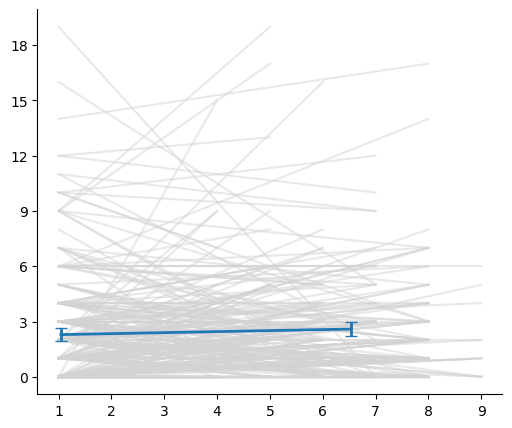

In [352]:
fig, ax = plt.subplots(figsize=(6, 5))

# seen = set()

# --- 1. Plot all individual paired lines (light gray) ---
for _, row in df_LAF.iterrows():
    
    # label = row['Group'] if row['Group'] not in seen else None
    
    plt.plot([int(row['Week_1']), int(row['Week_2'])], 
             [row['NumVar1'], row['NumVar2']],
             # color=row['color'],
             color='lightgray',
             alpha=0.5,
             linewidth=1.5,
             # label=label,
            )
    
    # seen.add(row['Group'])

# --- 2. Compute mean and 95% CI ---
means = [df_LAF['NumVar1'].mean(), df_LAF['NumVar2'].mean()]

# 95% CI using t distribution
ci_bl = st.sem(df_LAF['NumVar1']) * st.t.ppf(0.975, len(df_LAF)-1)
ci_fu = st.sem(df_LAF['NumVar2']) * st.t.ppf(0.975, len(df_LAF)-1)

cis = [ci_bl, ci_fu]

# --- 3. Overlay mean line in blue ---
plt.plot([df_LAF['Week_1'].mean(), df_LAF['Week_2'].mean()], means, linewidth=2)

# --- 4. Add 95% CI error bars ---
plt.errorbar([df_LAF['Week_1'].mean(), df_LAF['Week_2'].mean()], means, yerr=cis,
             fmt='none',
             capsize=4,
             linewidth=2,
            )

ax.yaxis.set_major_locator(MaxNLocator(integer=True))
sns.despine()

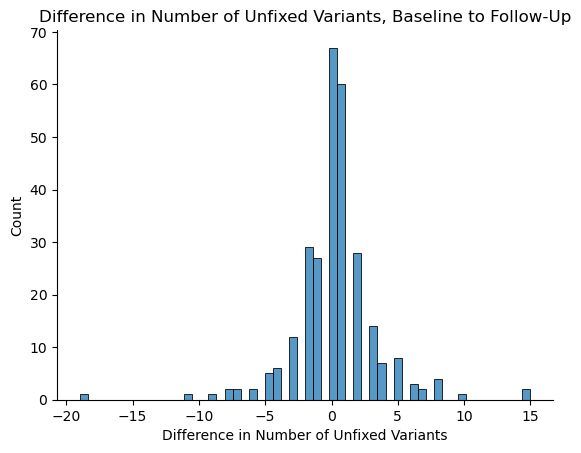

In [39]:
sns.histplot(data=df_LAF,
             x='NumVarDiff',
             # hue='Lineage',
             # multiple='dodge',
             # common_norm=False,
             # stat='probability'
            )

plt.title('Difference in Number of Unfixed Variants, Baseline to Follow-Up')
plt.xlabel('Difference in Number of Unfixed Variants')

sns.despine()
plt.savefig("../results/figures/NumVarDiff_hist.svg", bbox_inches='tight')

In [323]:
for sampling_interval_thresh in np.sort(df_LAF.Sampling_Interval.unique()):
    
    increase_pval = st.ttest_rel(df_LAF.query("Sampling_Interval >= @sampling_interval_thresh").NumVar1,
                         df_LAF.query("Sampling_Interval >= @sampling_interval_thresh").NumVar2,
                         alternative='less'
                        ).pvalue
    
    decrease_pval = st.ttest_rel(df_LAF.query("Sampling_Interval < @sampling_interval_thresh").NumVar1,
                         df_LAF.query("Sampling_Interval < @sampling_interval_thresh").NumVar2,
                         alternative='greater'
                        ).pvalue
    
    print(f"{sampling_interval_thresh}: site increase = {np.round(increase_pval, 3)}, site decrease = {np.round(decrease_pval, 3)}")

3: site increase = 0.054, site decrease = nan
4: site increase = 0.14, site decrease = 0.934
5: site increase = 0.437, site decrease = 0.995
6: site increase = 0.467, site decrease = 0.982
7: site increase = 0.058, site decrease = 0.845
8: site increase = 0.446, site decrease = 0.945


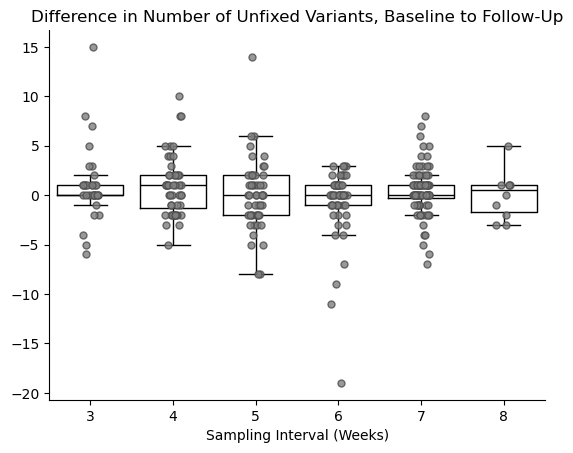

In [215]:
fig, ax = plt.subplots()

sns.stripplot(data=df_LAF,
                x='Sampling_Interval',
                y='NumVarDiff',
              color='gray',
              alpha=0.8,
              linewidth=1,
              ax=ax
               )

sns.boxplot(data=df_LAF,
                x='Sampling_Interval',
                y='NumVarDiff',
            fill=False,
            fliersize=0,
            color='black',
            linewidth=1,
            ax=ax
               )

plt.xlabel('Sampling Interval (Weeks)')
plt.ylabel('')
plt.title('Difference in Number of Unfixed Variants, Baseline to Follow-Up')

sns.despine()
# plt.show()
plt.savefig("../results/figures/NumVarDiff_by_sampling_interval.svg", bbox_inches='tight')

In [39]:
def convert_variant_differences_matrix_to_long(sample_1_variants, sample_2_variants, variant_differences, col_name):
    
    variant_differences_long = variant_differences.reset_index().melt(id_vars='index').rename(columns={'index': 'pid', 'value': 'Change'})

    variant_differences_long = variant_differences_long.merge(sample_1_variants.reset_index().melt(id_vars='index').rename(columns={'index': 'pid', 'value': 'Sample1'}), on=['pid', col_name], how='left')

    variant_differences_long = variant_differences_long.merge(sample_2_variants.reset_index().melt(id_vars='index').rename(columns={'index': 'pid', 'value': 'Sample2'}), on=['pid', col_name], how='left')

    # remove variants that are absent at both timepoint 1 and 2. These are there because they are present in another sample
    variant_differences_long = variant_differences_long.query("~(Sample1==0 & Sample2==0)").reset_index(drop=True)

    # remove variants that are fixed everywhere
    variant_differences_long = variant_differences_long.query("~(Sample1 > @AF_max & Sample2 > @AF_max)").reset_index(drop=True)

    # I think these are suspicious also. Just problems with detection
    # variant_differences_long = variant_differences_long.query("Change >= -0.95 & Change <= 0.95").reset_index(drop=True)

    variant_differences_long['Abs_Change'] = np.abs(variant_differences_long['Change'])

    # variant_differences_long = variant_differences_long.query("Abs_Change >= 0.05").reset_index(drop=True)

    variant_differences_long[['POS', 'REF', 'ALT']] = variant_differences_long[col_name].str.split('_', n=3, expand=True)
    variant_differences_long['POS'] = variant_differences_long['POS'].astype(int)

    variant_differences_long['Region'] = variant_differences_long['POS'].map(h37Rv_coords_dict)

    # exclude it because it seems like the samples are not from the same person
    variant_differences_long = variant_differences_long.query("pid != 'T0245'").reset_index(drop=True)
    
    return variant_differences_long

In [40]:
variant_differences_long = convert_variant_differences_matrix_to_long(sample_1_variants, sample_2_variants, variant_differences, 'Variant')

len(variant_differences_long), variant_differences_long.Change.min(), variant_differences_long.Change.max()

(1856, -1.0, 1.0)

In [50]:
variant_differences_long

,pid,Variant,Change,Sample1,Sample2,Abs_Change,POS,REF,ALT,Region
0,T0151,1010204_C_CG,-1.000000,1.000000,0.000000,1.000000,1010204,C,CG,Rv0907
1,T0005,1042692_T_TCTTGTTCACCCAGTACCTGTCCAA,0.976190,0.000000,0.976190,0.976190,1042692,T,TCTTGTTCACCCAGTACCTGTCCAA,pstS1
2,T0018,1042692_T_TCTTGTTCACCCAGTACCTGTCCAA,1.000000,0.000000,1.000000,1.000000,1042692,T,TCTTGTTCACCCAGTACCTGTCCAA,pstS1
3,T0026,1042692_T_TCTTGTTCACCCAGTACCTGTCCAA,0.973684,0.000000,0.973684,0.973684,1042692,T,TCTTGTTCACCCAGTACCTGTCCAA,pstS1
4,T0040,1042692_T_TCTTGTTCACCCAGTACCTGTCCAA,0.984127,0.000000,0.984127,0.984127,1042692,T,TCTTGTTCACCCAGTACCTGTCCAA,pstS1
...,...,...,...,...,...,...,...,...,...,...
1851,T0179,428228_G_T,1.000000,0.000000,1.000000,1.000000,428228,G,T,PPE8
1852,T0179,428229_C_A,1.000000,0.000000,1.000000,1.000000,428229,C,A,PPE8
1853,T0179,428231_A_G,1.000000,0.000000,1.000000,1.000000,428231,A,G,PPE8
1854,T0179,958387_GC_G,0.191565,0.802721,0.994286,0.191565,958387,GC,G,fadB


In [59]:
AF_min = 0.05
AF_max = np.round(1 - AF_min, 2)

col_1 = 'Sample1_MinorAF'
col_2 = 'Sample2_MinorAF'

df_variant_diff_plot = variant_differences_long.copy()
df_variant_diff_plot = df_variant_diff_plot.merge(df_trust_patients[['pid', 'Lineage']].drop_duplicates(), how='left')
df_variant_diff_plot['Lineage'] = df_variant_diff_plot['Lineage'].astype(float).astype(int)

df_variant_diff_plot = df_variant_diff_plot.merge(df_longitudinal_pids[['pid', 'Sampling_Interval']].drop_duplicates())
df_variant_diff_plot = df_variant_diff_plot.merge(pd.DataFrame(df_longitudinal_pids.groupby('pid')['Sampling_Week'].apply(lambda x: f"{min(x),max(x)}")), on='pid')

df_variant_diff_plot.loc[df_variant_diff_plot['Sample1'] <= 0.5, 'Sample1_MinorAF'] = df_variant_diff_plot['Sample1']
df_variant_diff_plot.loc[df_variant_diff_plot['Sample1'] > 0.5, 'Sample1_MinorAF'] = 1 - df_variant_diff_plot['Sample1']

# minor AF needs to be relative to what the minor allele at BL is
df_variant_diff_plot.loc[df_variant_diff_plot['Sample1'] <= 0.5, 'Sample2_MinorAF'] = df_variant_diff_plot['Sample2']
df_variant_diff_plot.loc[df_variant_diff_plot['Sample1'] > 0.5, 'Sample2_MinorAF'] = 1 - df_variant_diff_plot['Sample2']

df_variant_diff_plot['MinorAF_Change'] = df_variant_diff_plot['Sample2_MinorAF'] - df_variant_diff_plot['Sample1_MinorAF']

df_variant_diff_plot = df_variant_diff_plot.query(f"(({col_1} >= @AF_min & {col_1} <= @AF_max) | ({col_2} >= @AF_min & {col_2} <= @AF_max))")
print(len(df_variant_diff_plot))

1269


In [41]:
# SNV_differences_long = convert_variant_differences_matrix_to_long(sample_1_SNVs, sample_2_SNVs, SNV_differences, 'SNP')

# len(SNV_differences_long), SNV_differences_long.Change.min(), SNV_differences_long.Change.max()

1269
6.835070018431115e-36


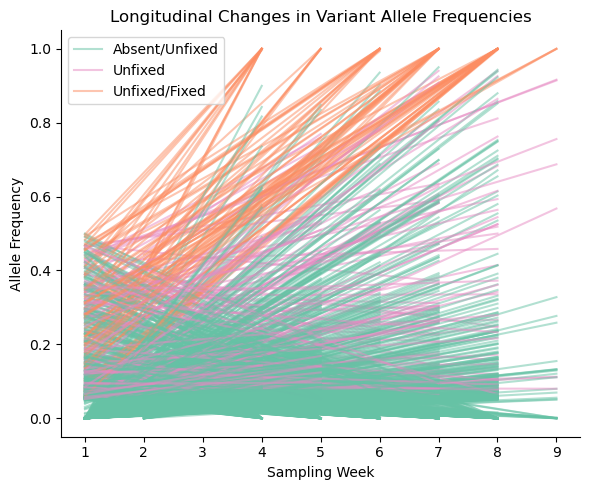

In [42]:
AF_min = 0.05
AF_max = np.round(1 - AF_min, 2)

col_1 = 'Sample1_MinorAF'
col_2 = 'Sample2_MinorAF'

df_variant_diff_plot = variant_differences_long.copy()
df_variant_diff_plot = df_variant_diff_plot.merge(df_trust_patients[['pid', 'Lineage']].drop_duplicates(), how='left')
df_variant_diff_plot['Lineage'] = df_variant_diff_plot['Lineage'].astype(float).astype(int)

df_variant_diff_plot = df_variant_diff_plot.merge(df_longitudinal_pids[['pid', 'Sampling_Interval']].drop_duplicates())
df_variant_diff_plot = df_variant_diff_plot.merge(pd.DataFrame(df_longitudinal_pids.groupby('pid')['Sampling_Week'].apply(lambda x: f"{min(x),max(x)}")), on='pid')

df_variant_diff_plot.loc[df_variant_diff_plot['Sample1'] <= 0.5, 'Sample1_MinorAF'] = df_variant_diff_plot['Sample1']
df_variant_diff_plot.loc[df_variant_diff_plot['Sample1'] > 0.5, 'Sample1_MinorAF'] = 1 - df_variant_diff_plot['Sample1']

# minor AF needs to be relative to what the minor allele at BL is
df_variant_diff_plot.loc[df_variant_diff_plot['Sample1'] <= 0.5, 'Sample2_MinorAF'] = df_variant_diff_plot['Sample2']
df_variant_diff_plot.loc[df_variant_diff_plot['Sample1'] > 0.5, 'Sample2_MinorAF'] = 1 - df_variant_diff_plot['Sample2']

df_variant_diff_plot['MinorAF_Change'] = df_variant_diff_plot['Sample2_MinorAF'] - df_variant_diff_plot['Sample1_MinorAF']

# df_variant_diff_plot.loc[df_variant_diff_plot[col_1] > df_variant_diff_plot[col_2], 'color'] = sns.color_palette("tab10").as_hex()[0]
# df_variant_diff_plot.loc[df_variant_diff_plot[col_2] > df_variant_diff_plot[col_1], 'color'] = sns.color_palette("tab10").as_hex()[1]

# absent to unfixed and vice versa
df_variant_diff_plot.loc[(df_variant_diff_plot[col_1] < 0.05) & (df_variant_diff_plot[col_2] >= 0.05) & (df_variant_diff_plot[col_2] <= 0.95), ['color', 'Group']] = [sns.color_palette("Set2").as_hex()[0], 'Absent/Unfixed']
df_variant_diff_plot.loc[(df_variant_diff_plot[col_2] < 0.05) & (df_variant_diff_plot[col_1] >= 0.05) & (df_variant_diff_plot[col_1] <= 0.95), ['color', 'Group']] = [sns.color_palette("Set2").as_hex()[0], 'Absent/Unfixed']

# unfixed to fixed and vice versa
df_variant_diff_plot.loc[(df_variant_diff_plot[col_1] > 0.95) & (df_variant_diff_plot[col_2] >= 0.05) & (df_variant_diff_plot[col_2] <= 0.95), ['color', 'Group']] = [sns.color_palette("Set2").as_hex()[1], 'Unfixed/Fixed']
df_variant_diff_plot.loc[(df_variant_diff_plot[col_2] > 0.95) & (df_variant_diff_plot[col_1] >= 0.05) & (df_variant_diff_plot[col_1] <= 0.95), ['color', 'Group']] = [sns.color_palette("Set2").as_hex()[1], 'Unfixed/Fixed']

# unfixed at both timepoints
df_variant_diff_plot.loc[(df_variant_diff_plot[col_1] >= 0.05) & (df_variant_diff_plot[col_1] <= 0.95) & (df_variant_diff_plot[col_2] >= 0.05) & (df_variant_diff_plot[col_2] <= 0.95), ['color', 'Group']] = [sns.color_palette("Set2").as_hex()[3], 'Unfixed']

# only unfixed variants at at least one timepoint. Exclude changes from absent to fixed and vice versa
df_variant_diff_plot = df_variant_diff_plot.query(f"(({col_1} >= @AF_min & {col_1} <= @AF_max) | ({col_2} >= @AF_min & {col_2} <= @AF_max))")
print(len(df_variant_diff_plot))

df_indels_diff = df_variant_diff_plot.query("REF.str.len() != ALT.str.len()").merge(df_indels[['Indel', 'HT_Region', 'phase_variant']].drop_duplicates(), left_on='Variant', right_on='Indel')

stat, pval = st.ttest_rel(df_variant_diff_plot[col_1], 
                          df_variant_diff_plot[col_2], 
                          alternative='less'
                         )
print(pval)

plt.figure(figsize=(6, 5))

seen = set()

# --- 1. Plot all individual paired lines (light gray) ---
for _, row in df_variant_diff_plot.iterrows():
    
    week_1, week_2 = row['Sampling_Week'].strip('(').strip(')').split(',')
    
    label = row['Group'] if row['Group'] not in seen else None
    
    plt.plot([int(week_1), int(week_2)], 
             [row[col_1], row[col_2]],
             color=row['color'],
             alpha=0.5,
             linewidth=1.5,
             label=label
            )
    
    seen.add(row['Group'])

# --- 2. Compute mean and 95% CI ---
means = [df_variant_diff_plot[col_1].mean(), df_variant_diff_plot[col_2].mean()]

# 95% CI using t distribution
ci_bl = st.sem(df_variant_diff_plot[col_1]) * st.t.ppf(0.975, len(df_variant_diff_plot)-1)
ci_fu = st.sem(df_variant_diff_plot[col_2]) * st.t.ppf(0.975, len(df_variant_diff_plot)-1)

cis = [ci_bl, ci_fu]

# # --- 3. Overlay mean line in blue ---
# plt.plot([0, 1], means, linewidth=2)

# # --- 4. Add 95% CI error bars ---
# plt.errorbar([0, 1], means, yerr=cis,
#              fmt='none',
#              capsize=4,
#              linewidth=2)

plt.legend()

# --- 5. Format axes ---
plt.title(f"Longitudinal Changes in Variant Allele Frequencies")
# plt.xticks([0, 1], ["Baseline", "Follow-Up"])
plt.xlabel('Sampling Week')
plt.ylabel("Allele Frequency")
plt.tight_layout()
sns.despine()
plt.savefig("../results/figures/AF_changes_variants.svg")

# total number of variants in a given region with a change
df_variant_diff_plot = df_variant_diff_plot.merge(pd.DataFrame(df_variant_diff_plot.Region.value_counts()).rename(columns={'count': 'Region_total'}).reset_index())
df_variant_diff_plot['MinorAF_Change_Norm'] = df_variant_diff_plot['MinorAF_Change'] / df_variant_diff_plot['Region_total']

# proportion of variants that changed in that pid that had large changes
df_variant_diff_plot = df_variant_diff_plot.merge(pd.DataFrame(df_variant_diff_plot.pid.value_counts()).rename(columns={'count': 'pid_total'}).reset_index())
df_variant_diff_plot = df_variant_diff_plot.merge(pd.DataFrame(df_variant_diff_plot.query("MinorAF_Change > 0.5").pid.value_counts()).rename(columns={'count': 'pid_high_total'}).reset_index(), how='left')
df_variant_diff_plot['pid_high_total'] = df_variant_diff_plot['pid_high_total'].fillna(0).astype(int)
df_variant_diff_plot['prop_high_change_of_pid_total'] = df_variant_diff_plot['pid_high_total'] / df_variant_diff_plot['pid_total']

# proportion of variants that changed in that region that had large changes
df_variant_diff_plot = df_variant_diff_plot.merge(pd.DataFrame(df_variant_diff_plot.query("MinorAF_Change > 0.5").Region.value_counts()).rename(columns={'count': 'Region_high_total'}).reset_index(), how='left')
df_variant_diff_plot['Region_high_total'] = df_variant_diff_plot['Region_high_total'].fillna(0).astype(int)
df_variant_diff_plot['prop_high_change_of_Region_total'] = df_variant_diff_plot['Region_high_total'] / df_variant_diff_plot['Region_total']

In [44]:
np.min(np.abs(df_variant_diff_plot['MinorAF_Change']))

0.0010748485440688071

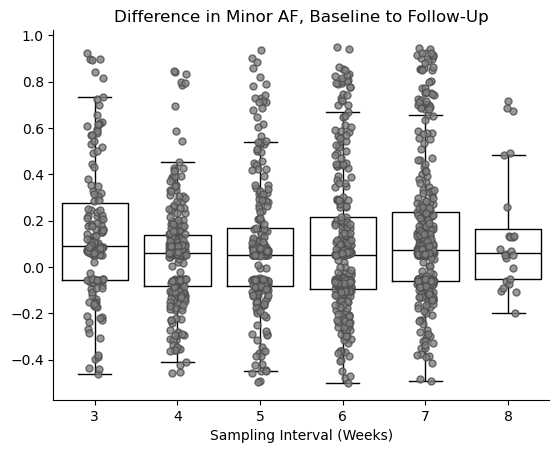

In [44]:
fig, ax = plt.subplots()

sns.stripplot(data=df_variant_diff_plot,
                x='Sampling_Interval',
                y='MinorAF_Change',
              color='gray',
              alpha=0.8,
              linewidth=1,
              ax=ax
               )

sns.boxplot(data=df_variant_diff_plot,
                x='Sampling_Interval',
                y='MinorAF_Change',
            fill=False,
            fliersize=0,
            color='black',
            linewidth=1,
            ax=ax
               )

plt.xlabel('Sampling Interval (Weeks)')
plt.ylabel('')
plt.title('Difference in Minor AF, Baseline to Follow-Up')

sns.despine()
# plt.show()
# plt.savefig("../results/figures/NumVarDiff_by_sampling_interval.svg", bbox_inches='tight')

In [45]:
df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2 & pid != 'T0245'").drop_duplicates(subset='pid').Sampling_Interval.median()

6.0

In [46]:
df_variant_diff_plot.shape

(1269, 25)

In [47]:
df_variant_diff_plot['MinorAF_Change'].mean(), df_variant_diff_plot['MinorAF_Change'].median()

(0.10534306088408038, 0.0651340996168582)

In [223]:
st.ttest_rel(df_variant_diff_plot['Sample1_MinorAF'],
             df_variant_diff_plot['Sample2_MinorAF'],
             alternative='less'
            )

TtestResult(statistic=-12.844998094753688, pvalue=6.83507001843141e-36, df=1268)

<Axes: xlabel='MinorAF_Change', ylabel='Probability'>

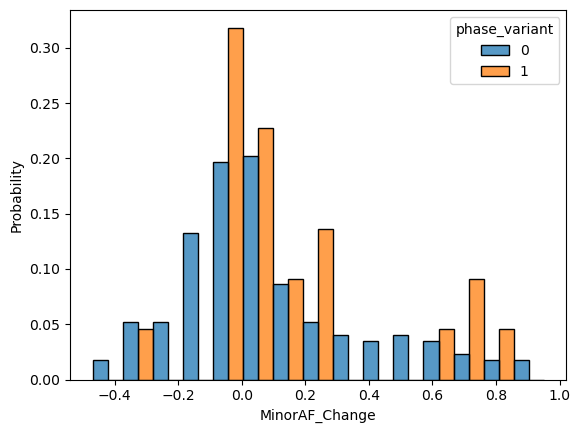

In [224]:
sns.histplot(data=df_indels_diff,
             x='MinorAF_Change',
             hue='phase_variant',
             common_norm=False,
             stat='probability',
             multiple='dodge'
            )

In [225]:
st.ttest_rel(df_indels_diff.query("phase_variant==1")[col_1],
             df_indels_diff.query("phase_variant==1")[col_2],
             alternative='less'
            )

TtestResult(statistic=-2.524320075585696, pvalue=0.009856467554484773, df=21)

In [226]:
df_indels_diff.query("phase_variant==1 & MinorAF_Change > 0.6")

,pid,Variant,Change,Sample1,Sample2,Abs_Change,POS,REF,ALT,Region,...,Sampling_Interval,Sampling_Week,Sample1_MinorAF,Sample2_MinorAF,MinorAF_Change,color,Group,Indel,HT_Region,phase_variant
47,T0090,4323354_C_CG,0.678357,0.315412,0.993769,0.678357,4323354,C,CG,NC_2971,...,5,"(1, 6)",0.315412,0.993769,0.678357,#fc8d62,Unfixed/Fixed,4323354_C_CG,1,1
54,T0222,854252_GC_G,-0.831805,0.995495,0.163690,0.831805,854252,GC,G,NC_597,...,6,"(1, 7)",0.004505,0.836310,0.831805,#66c2a5,Absent/Unfixed,854252_GC_G,1,1
147,T0140,4007271_CG_C,-0.726531,0.726531,0.000000,0.726531,4007271,CG,C,aspB,...,3,"(1, 4)",0.273469,1.000000,0.726531,#fc8d62,Unfixed/Fixed,4007271_CG_C,1,1


In [76]:
df_longitudinal_pids.query("pid=='T0140'")

,pid,Original_ID,SampleID,Sampling_Week,screen_prevpid,Kraken_Unclassified_Percent,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,...,p_val_wsrst,abs_diff,mix_index,mix_node,mix_phylotype,mix_prop,failed,mix_phylotypes,mix_props,Sampling_Interval
188,T0140,S0140-01,MFS-68,1,NaN,0.56,4.3.4.1,4.2.1.2.1.1.i3.2,lam,NaN,...,-1.0,inf,1,89,4.3.4.1,1.0,False,4.3.4.1,1.0,3
189,T0140,S0140-04,MFS-69,4,NaN,0.86,4.3.4.1,4.2.1.2.1.1.i3.2,lam,NaN,...,-1.0,inf,1,89,4.3.4.1,1.0,False,4.3.4.1,1.0,3


In [48]:
st.ttest_rel(df_variant_diff_plot[col_1],
             df_variant_diff_plot[col_2],
             alternative='less'
            )

TtestResult(statistic=-12.844998094753688, pvalue=6.83507001843141e-36, df=1268)

In [403]:
sampling_interval_thresh = 7

# require that variant was present at baseline and stratify by sampling interval
st.ttest_rel(df_variant_diff_plot.query(f"{col_1} > 0 & Sampling_Interval >= @sampling_interval_thresh")[col_1],
             df_variant_diff_plot.query(f"{col_1} > 0 & Sampling_Interval >= @sampling_interval_thresh")[col_2],
             alternative='less'
            )

TtestResult(statistic=-3.4763733619985295, pvalue=0.0003142273240581858, df=192)

In [389]:
sampling_interval_thresh = 6

st.ttest_rel(df_variant_diff_plot.query("Sampling_Interval < @sampling_interval_thresh")[col_1],
             df_variant_diff_plot.query("Sampling_Interval < @sampling_interval_thresh")[col_2],
             alternative='less'
            )

TtestResult(statistic=-7.932688628301183, pvalue=5.206444784346859e-15, df=605)

In [390]:
sampling_interval_thresh = 6

st.ttest_rel(df_variant_diff_plot.query("Sampling_Interval >= @sampling_interval_thresh")[col_1],
             df_variant_diff_plot.query("Sampling_Interval >= @sampling_interval_thresh")[col_2],
             alternative='less'
            )

TtestResult(statistic=-10.133777916770342, pvalue=8.60413651615731e-23, df=643)

In [378]:
st.ttest_rel(df_variant_diff_plot.query(f"Sample1 != 0 & Sample2 != 0 & {col_1} != 0 & {col_2} != 0 & REF.str.len() == ALT.str.len()")[col_1],
             df_variant_diff_plot.query(f"Sample1 != 0 & Sample2 != 0 & {col_1} != 0 & {col_2} != 0 & REF.str.len() == ALT.str.len()")[col_2],
             alternative='less'
            )

TtestResult(statistic=-7.037294821753406, pvalue=3.3281998659145234e-11, df=149)

In [1004]:
pids_increase_variant_frequency = df_variant_diff_plot.query(f"Sample1 != 0 & Sample2 != 0 & {col_1} != 0 & {col_2} != 0 & REF.str.len() == ALT.str.len()").query("MinorAF_Change > 0.5").pid.values




In [604]:
INH_R_pids = TRUST_phenos.query("INH_lower_bound >= 0.1").pid.unique()
INH_R_SampleIDs = df_trust_patients.query("pid in @INH_R_pids").sort_values(['pid', 'Sampling_Week']).drop_duplicates('pid').SampleID.values

In [624]:
SampleIDs_with_INH_R_muts = isolate_variants.query("SampleID in @INH_R_SampleIDs & drug=='Isoniazid' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").SampleID.values

In [625]:
len(SampleIDs_with_INH_R_muts), len(INH_R_SampleIDs)

(14, 26)

In [632]:
unexplained_samples = list(set(INH_R_SampleIDs) - set(SampleIDs_with_INH_R_muts))

In [644]:
df_lowAF_variants_full.query("SampleID in @unexplained_samples")[['pid', 'SampleID', 'Region', 'HGVS_P']].merge(who_catalog.query("drug=='Isoniazid'")[['gene', 'mutation', 'FINAL CONFIDENCE GRADING']].rename(columns={'gene': 'Region', 'mutation': 'HGVS_P'}))

,pid,SampleID,Region,HGVS_P,FINAL CONFIDENCE GRADING
0,T0331,MFS-397,katG,p.Trp149Arg,3) Uncertain significance
1,T0331,MFS-397,katG,p.Tyr98Cys,3) Uncertain significance


In [646]:
df_lowAF_variants_full.query("SampleID in @unexplained_samples").query("Region.str.contains('NC')")

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,pred_class,Sampling_Week,SNP,Region,Variant_Type,REF_AA,ALT_AA,Paired_Sample_Num,GENE1,GENE2


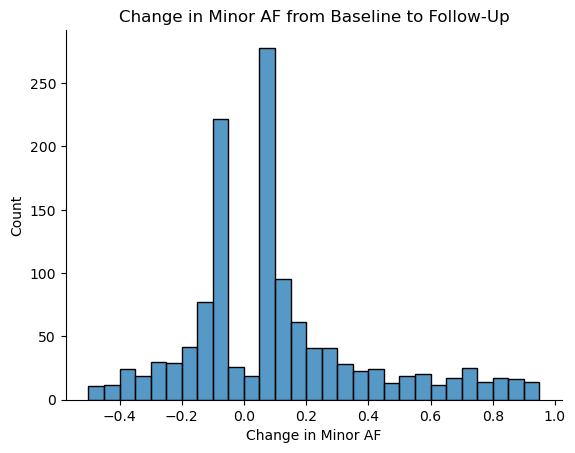

In [49]:
sns.histplot(data=df_variant_diff_plot,
             x='MinorAF_Change'
            )

sns.despine()
plt.title('Change in Minor AF from Baseline to Follow-Up')
plt.xlabel('Change in Minor AF')
plt.savefig("../results/figures/minorAF_change.svg", bbox_inches='tight')

In [50]:
st.ttest_rel(df_variant_diff_plot.query("MinorAF_Change <= 0.5")[col_1],
             df_variant_diff_plot.query("MinorAF_Change <= 0.5")[col_2],
             alternative='less'
            )

TtestResult(statistic=-3.6748343748891603, pvalue=0.00012466428054577522, df=1114)

In [51]:
len(df_variant_diff_plot.query("MinorAF_Change > 0.5"))

154

In [69]:
AF_min = 0.05
AF_max = 0.95

# require at least one of the variants to be unfixed (BL or FU)
unfixed_variant_differences_long = variant_differences_long.query("(Sample1 >= @AF_min & Sample1 <= @AF_max) | (Sample2 >= @AF_min & Sample2 <= @AF_max)")

num_unfixed_to_fixed = len(unfixed_variant_differences_long.query("Sample1 >= @AF_min & Sample1 <= @AF_max & Sample2 > @AF_max"))

num_stay_unfixed = len(unfixed_variant_differences_long.query("Sample1 >= @AF_min & Sample1 <= @AF_max & Sample2 >= @AF_min & Sample2 <= @AF_max"))

num_fixed_to_unfixed = len(unfixed_variant_differences_long.query("Sample1 > @AF_max & Sample2 >= @AF_min & Sample2 <= @AF_max"))

num_absent_to_unfixed = len(unfixed_variant_differences_long.query("Sample1 <= @AF_min & Sample2 >= @AF_min & Sample2 <= @AF_max"))

num_unfixed_to_absent = len(unfixed_variant_differences_long.query("Sample2 <= @AF_min & Sample1 >= @AF_min & Sample1 <= @AF_max"))

num_absent_to_fixed = len(unfixed_variant_differences_long.query("Sample1 < @AF_min & Sample2 > @AF_max"))

print(f"{len(unfixed_variant_differences_long)} total")
print(f"    {num_absent_to_fixed} ({np.round(num_absent_to_fixed/len(unfixed_variant_differences_long), 4)}) absent to fixed")
print(f"    {num_absent_to_unfixed} ({np.round(num_absent_to_unfixed/len(unfixed_variant_differences_long), 4)}) absent to unfixed")
print(f"    {num_unfixed_to_fixed} ({np.round(num_unfixed_to_fixed/len(unfixed_variant_differences_long), 4)}) unfixed to fixed")
print(f"    {num_stay_unfixed} ({np.round(num_stay_unfixed/len(unfixed_variant_differences_long), 4)}) remain unfixed")
print(f"    {num_fixed_to_unfixed} ({np.round(num_fixed_to_unfixed/len(unfixed_variant_differences_long), 4)}) fixed to unfixed")
print(f"    {num_unfixed_to_absent} ({np.round(num_unfixed_to_absent/len(unfixed_variant_differences_long), 4)}) unfixed to absent")

1269 total
    0 (0.0) absent to fixed
    581 (0.4578) absent to unfixed
    39 (0.0307) unfixed to fixed
    140 (0.1103) remain unfixed
    23 (0.0181) fixed to unfixed
    486 (0.383) unfixed to absent


In [102]:
df_recovered_timepoint_1 = []
num_not_found = 0

for i, row in unfixed_variant_differences_long.query("Sample1 <= @AF_min & Sample2 >= @AF_min & Sample2 <= @AF_max").iterrows():
    
    pid = row['pid']
    ref = row['REF']
    alt = row['ALT']
    pos = row['POS']
    assert row['Sample1'] == 0
    
    timepoint_1_sample = df_longitudinal_pids.query("pid==@pid").sort_values('Sampling_Week').SampleID.values[0]

    df_pre_filt_variants = pd.read_csv(f"{H37Rv_ref_dir}/{timepoint_1_sample}/freebayes/{timepoint_1_sample}.cleaned.excludeLowConf.fixedAO.tsv", sep='\t')
    df_pre_filt_variants['recomputed_AF'] = df_pre_filt_variants['AO'] / df_pre_filt_variants['DP']

    df_recovered = df_pre_filt_variants.query("POS==@pos & REF==@ref & ALT==@alt")
    
    if len(df_recovered) > 0:
        df_recovered[['pid', 'SampleID']] = [[pid, timepoint_1_sample]]
        df_recovered_timepoint_1.append(df_recovered[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'recomputed_AF', 'SAF', 'SAR', 'AO', 'DP']])
    else:
        num_not_found += 1
        
df_recovered_timepoint_1 = pd.concat(df_recovered_timepoint_1)
print(f"Did not find {num_not_found}/{num_absent_to_unfixed}")

Did not find 524/581


In [109]:
df_recovered_timepoint_1.recomputed_AF.min(), df_recovered_timepoint_1.recomputed_AF.max()

(0.010101010101010102, 0.4268292682926829)

In [103]:
df_recovered_timepoint_2 = []
num_not_found = 0

for i, row in unfixed_variant_differences_long.query("Sample2 <= @AF_min & Sample1 >= @AF_min & Sample1 <= @AF_max").iterrows():
    
    pid = row['pid']
    ref = row['REF']
    alt = row['ALT']
    pos = row['POS']
    assert row['Sample2'] == 0
    
    timepoint_2_sample = df_longitudinal_pids.query("pid==@pid").sort_values('Sampling_Week').SampleID.values[-1]

    df_pre_filt_variants = pd.read_csv(f"{H37Rv_ref_dir}/{timepoint_2_sample}/freebayes/{timepoint_2_sample}.cleaned.excludeLowConf.fixedAO.tsv", sep='\t')
    df_pre_filt_variants['recomputed_AF'] = df_pre_filt_variants['AO'] / df_pre_filt_variants['DP']

    df_recovered = df_pre_filt_variants.query("POS==@pos & REF==@ref & ALT==@alt")
    
    if len(df_recovered) > 0:
        df_recovered[['pid', 'SampleID']] = [[pid, timepoint_2_sample]]
        df_recovered_timepoint_2.append(df_recovered[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'recomputed_AF', 'SAF', 'SAR', 'AO', 'DP']])
    else:
        num_not_found += 1
        
df_recovered_timepoint_2 = pd.concat(df_recovered_timepoint_2)
print(f"Did not find {num_not_found}/{num_unfixed_to_absent}")

Did not find 450/486


In [108]:
df_recovered_timepoint_2.recomputed_AF.min(), df_recovered_timepoint_2.recomputed_AF.max()

(0.010582010582010581, 0.7948717948717948)

In [ ]:
1269 total
    0 (0.0) absent to fixed
    524 (0.4129) absent to unfixed
    39 (0.0307) unfixed to fixed
    233 (0.1836) remain unfixed
    23 (0.0181) fixed to unfixed
    450 (0.3546) unfixed to absent

In [296]:
num_sites_thresh = 0

alt = 'less'

df_check = df_LAF.query("NumVar1 >= @num_sites_thresh & NumVar2 >= @num_sites_thresh & pid != 'T0245'")

num_keep = len(df_check)

sase_pval = st.ttest_rel(df_check['SASE1'],
                         df_check['SASE2'],
                        alternative=alt
                       ).pvalue

se_pval = st.ttest_rel(df_check['SE1'],
                       df_check['SE2'],
                      alternative=alt
                      ).pvalue

num_sites_pval = st.ttest_rel(df_check['NumVar1'],
                              df_check['NumVar2'],
                             alternative=alt
                            ).pvalue

print(f"{num_keep} pids have ≥ {num_sites_thresh} unfixed sites at both timepoints")
print(f"SASE change: {sase_pval}")
print(f"SE change: {se_pval}")
print(f"Number of sites change: {num_sites_pval}")

284 pids have ≥ 0 unfixed sites at both timepoints
SASE change: 0.05877313298734433
SE change: 0.06778301940798238
Number of sites change: 0.04307788471538511


In [301]:
df_check.NumVar1.mean(), df_check.NumVar2.mean(), df_check.NumVarDiff.mean()

(2.306338028169014, 2.630281690140845, 0.323943661971831)

In [304]:
num_sites_thresh = 1

alt = 'two-sided'

df_check = df_LAF.query("NumVar1 >= @num_sites_thresh & NumVar2 >= @num_sites_thresh & pid != 'T0245'")

num_keep = len(df_check)

sase_pval = st.ttest_rel(df_check['SASE1'],
                         df_check['SASE2'],
                        alternative=alt
                       ).pvalue

se_pval = st.ttest_rel(df_check['SE1'],
                       df_check['SE2'],
                      alternative=alt
                      ).pvalue

num_sites_pval = st.ttest_rel(df_check['NumVar1'],
                              df_check['NumVar2'],
                             alternative=alt
                            ).pvalue

print(f"{num_keep} pids have ≥ {num_sites_thresh} unfixed sites at both timepoints")
print(f"SASE change: {sase_pval}")
print(f"SE change: {se_pval}")
print(f"Number of sites change: {num_sites_pval}")

164 pids have ≥ 1 unfixed sites at both timepoints
SASE change: 0.9044406960654924
SE change: 0.10246768641039197
Number of sites change: 0.08178106871644408


In [288]:
num_sites_thresh = 2

alt = 'less'

df_check = df_LAF.query("NumVar1 >= @num_sites_thresh & NumVar2 >= @num_sites_thresh & pid != 'T0245'")

num_keep = len(df_check)

sase_pval = st.ttest_rel(df_check['SASE1'],
                         df_check['SASE2'],
                        alternative=alt
                       ).pvalue

se_pval = st.ttest_rel(df_check['SE1'],
                       df_check['SE2'],
                      alternative=alt
                      ).pvalue

num_sites_pval = st.ttest_rel(df_check['NumVar1'],
                              df_check['NumVar2'],
                             alternative=alt
                            ).pvalue

print(f"{num_keep} pids have ≥ {num_sites_thresh} unfixed sites at both timepoints")
print(f"SASE change: {sase_pval}")
print(f"SE change: {se_pval}")
print(f"Number of sites change: {num_sites_pval}")

90 pids have ≥ 2 unfixed sites at both timepoints
SASE change: 0.6324769018346516
SE change: 0.11580978035211321
Number of sites change: 0.10154961504258302


# Analyze Site Turnover

In [233]:
df_compare_variants_timepoints = df_lowAF_variants.query("pid != 'T0245'").query("Paired_Sample_Num==1")[['pid', 'POS']].merge(df_lowAF_variants.query("pid != 'T0245'").query("Paired_Sample_Num==2")[['pid', 'POS']], how='outer', on=['pid', 'POS'], indicator=True)

sample_1_only = df_compare_variants_timepoints.query("_merge=='left_only'")
sample_2_only = df_compare_variants_timepoints.query("_merge=='right_only'")
overlap = df_compare_variants_timepoints.query("_merge=='both'")
union = df_compare_variants_timepoints.copy()
              
# print(f"Sample 1: {len(sample_1_sites)}")
# print(f"Sample 2: {len(sample_2_sites)}")
print(f"Overlap: {len(overlap)} ({len(overlap) / len(union)})")
print(f"Sample 1 ONLY: {len(sample_1_only)} ({len(sample_1_only) / len(union)})")
print(f"Sample 2 ONLY: {len(sample_2_only)} ({len(sample_2_only) / len(union)})")

Overlap: 121 (0.11172668513388735)
Sample 1 ONLY: 434 (0.4007386888273315)
Sample 2 ONLY: 528 (0.48753462603878117)


In [116]:
# lineage_col = 'Coll2014'

# for lineage in df_LAF[lineage_col].unique():
    
#     num_isolates = len(df_LAF.query(f"{lineage_col}==@lineage & ~(SASE1 == 0 & SASE2 == 0)"))
    
#     if num_isolates > 1:
    
#         increase_pval = st.wilcoxon(df_LAF.query(f"{lineage_col}==@lineage")['SASE2'],
#                                     df_LAF.query(f"{lineage_col}==@lineage")['SASE1'],
#                                     alternative='greater'
#                                    ).pvalue
        
#         decrease_pval = st.wilcoxon(df_LAF.query(f"{lineage_col}==@lineage")['SASE2'],
#                                     df_LAF.query(f"{lineage_col}==@lineage")['SASE1'],
#                                     alternative='less'
#                                    ).pvalue

#         if increase_pval <= 0.05:
#             print(f"L{lineage} increase: p = {np.round(increase_pval, 2)}, N = {num_isolates}")
            
#         if decrease_pval <= 0.05:
#             print(f"L{lineage} decrease: p = {np.round(decrease_pval, 2)}, N = {num_isolates}")

In [117]:
# lineage_order = df_LAF.groupby('Coll2014')['SASE_Diff'].mean().sort_values().index.values

# fig, ax = plt.subplots(figsize=(10, 6))

# sns.stripplot(data=df_LAF,
#                 x='SASE_Diff',
#              y='Coll2014',
#              # multiple='dodge',
#              # common_norm=False,
#              palette='tab20',
#               order=lineage_order,
#               edgecolor='black',
#               linewidth=0.5,
#               ax=ax
#                )

# # plt.title('Difference in SASE between Follow-Up and Baseline')
# plt.xlabel('Difference in SASE')

# sns.despine()
# # plt.savefig("../results/figures/SASE_diff_by_lineage.svg", bbox_inches='tight')

# Nucleotide Diversity and Estimated Population Size Calculations

In [ ]:
# df_exclude = pd.read_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/references/BED_files/exclude_regions_50bp.EBRlessThan95Percent.bed", sep='\t', header=None)

# excluded_sites = []

# for i, row in df_exclude.iterrows():
#     excluded_sites += list(np.arange(row[1] + 1, row[2] + 1))
    
# # also excluded [2337869, 2340874], inclusive
# excluded_sites += list(np.arange(2337869, 2340874 + 1))

# excluded_sites = np.unique(excluded_sites)

# num_total_sites = len(h37Rv_seq) - len(excluded_sites)

In [153]:
# def compute_nucleotide_diversity_Ne(pid, mutation_rate=5e-8):
    
#     # remove sites that are fixed (AF > 0.95) in both. Keep those that are fixed in one and not the other though
#     df_sample_1 = pd.DataFrame(sample_1_SNVs.loc[pid]).rename(columns={pid: 'Sample1'})
#     df_sample_2 = pd.DataFrame(sample_2_SNVs.loc[pid]).rename(columns={pid: 'Sample2'})

#     df_sample_1['Sample1_Inv'] = 1 - df_sample_1['Sample1']
#     df_sample_2['Sample2_Inv'] = 1 - df_sample_2['Sample2']

#     ND_1 = np.sum(2 * df_sample_1.product(axis=1)) / len(df_sample_1)
#     ND_2 = np.sum(2 * df_sample_2.product(axis=1)) / len(df_sample_2)

#     Ne_1 = ND_1 / (2 * mutation_rate)
#     Ne_2 = ND_2 / (2 * mutation_rate)

#     return pd.DataFrame({'pid': pid, 'ND_1': ND_1, 'ND_2': ND_2, 'Ne_1': Ne_1, 'Ne_2': Ne_2}, index=[0])

In [154]:
# df_population_sizes = []

# for pid in df_longitudinal_pids.pid.unique():
#     df_population_sizes.append(compute_nucleotide_diversity_Ne(pid))
    
# df_population_sizes = pd.concat(df_population_sizes)

# print(np.round(df_population_sizes[['Ne_1', 'Ne_2']].max().max()))

# df_population_sizes = df_population_sizes.merge(df_longitudinal_pids[['pid', 'Paired_Sample_Num', 'F2']].pivot(index='pid', columns='Paired_Sample_Num', values='F2').rename(columns={1: 'F2_1', 2: 'F2_2'}).reset_index())

In [155]:
# sns.scatterplot(data=df_population_sizes.query("pid in @pids_with_low_F2"),
#                 x='Ne_1',
#                 y='Ne_2'
#                )

# plt.xscale('log')
# plt.yscale('log')

# sns.despine()

# Associate diversity metrics with outcomes

In [120]:
import sys
sys.path.append(os.path.join(os.getcwd(), "scripts"))
from epi_utils import *


In [121]:
def find_best_variant_burden_binarization_threshold(df_pids_for_outcomes_model, df_LAF, df_outcomes, cols_lst, event_col, time_col, tb_deaths_only, invert_OR, stratify_covariates, thresh, binarize=False, diversity_metric='NumVar1'):

    df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid'] + [diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])
    # df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid'] + diversity_metrics])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])
        
    if binarize:
        df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > thresh).astype(int)
        model_variables = cols_lst + [diversity_metric]
    
    # if not binarizing, then we're testing where the threshold is that the response is truly dose-dependent. 
    # Based on stratified KM curves, it looks like the relationship is not dose-dependent at the low values. Probably because the distribution of the metric is not normal
    else:
        df_add_metric_for_model[f'{diversity_metric}_leq_{thresh}'] = df_add_metric_for_model[diversity_metric].clip(upper=thresh)
        df_add_metric_for_model[f'{diversity_metric}_above_{thresh}'] = (df_add_metric_for_model[diversity_metric] - thresh).clip(lower=0)
        model_variables = cols_lst + [f'{diversity_metric}_leq_{thresh}', f'{diversity_metric}_above_{thresh}']
        
    df_test_results_diversity, df_model_processed, cph_model = fit_cox_models_all_imputations(df_add_metric_for_model,
                                                                                              TRUST_phenos, 
                                                                                                TRUST_phenos,
                                                                                              df_outcomes,
                                                                                           model_variables,
                                                                                              event_col=event_col,
                                                                                              time_col=time_col,
                                                                                              MIC_type='none',
                                                                                              tb_deaths_only=tb_deaths_only,
                                                                                              invert_OR=invert_OR,
                                                                                              stratify_variables=stratify_covariates,
                                                                                             binary_lineage=True,
                                                                                              PLI_thresh=PLI_thresh
                                                                                             )

    df_model_processed = df_model_processed[0]
    cph_model = cph_model[0]

    # cph_model.check_assumptions(df_model_processed)

    print(f"Final: {df_model_processed.pid.nunique()} pids")
    
    return cph_model.AIC_partial_, cph_model.concordance_index_, cph_model.log_likelihood_

In [122]:
cols_lst = [
            'screen_sex',
            'screen_years',
            'underweight',
            'fstrom1_baseline', # smoking yes or no
            # 'smoked_substance_use',
            # 'peth_value_baseline',
            'HIV_CD4',
            'bl_prevtb',
            'TTP_baseline',
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            # 'adherence_rate_by_observed',
            # 'high_lung_involvement',
            # 'human_PLI',
            'human_high_lung_involvement',
            # 'cxr_effusion_chest_radiograph_1',
            # 'cxr_cavity_chest_radiograph_1',
            # 'Lineage', # Lineage_3 is so rare and causes instabilities / needs to be stratified by
            # 'F2',
            # 'Phase_Variant'
           ]

PLI_thresh = 25

stratify_covariates = ['human_high_lung_involvement', 'smear_pos_no_contam_sputum_specimen_1', 'bl_prevtb', 'underweight'] #['', 'HIV_CD4', 'screen_sex', 'underweight']#, 'bl_prevtb']#, 'high_lung_involvement'
# stratify_covariates = ['smear_pos_no_contam_sputum_specimen_1', 'HIV_CD4', 'smoked_substance_use', 'screen_sex', 'underweight']

non_linear_term_variables = []

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_imputed_TCC = pd.read_csv(f"{TRUST_data_dir}/imputed_TCC.csv").query("pid in @df_trust_patients.pid")

df_TCC = df_imputed_TCC.query("imp_num==0").reset_index(drop=True)
df_imputed_TCC = df_imputed_TCC.query("imp_num > 0").reset_index(drop=True)

CNN_results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

# this includes TTP, PK AUC, and CXR data merged in
df_processed_patients = pd.read_csv(f"{TRUST_data_dir}/20251126_cleaned_patient_outcomes_data.csv")

df_pids_for_outcomes_model, TRUST_phenos = read_combine_all_TRUST_data(df_processed_patients, 
                                                                                         {'RIF': 'lineage_amino_acid',
                                                                                          'INH': 'lineage_amino_acid',
                                                                                          'EMB': 'lineage_amino_acid',
                                                                                          'PZA': 'amino_acid'}, 
                                                                                         CNN_results_dir=None,
                                                                                         F2_thresh=1, 
                                                                                         baseline_only=True
                                                                                        )

# baseline_samples_no_F2_thresh = df_trust_patients.query("Sampling_Week <= 2").SampleID.values
# df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("SampleID in @baseline_samples_no_F2_thresh").sort_values(['pid', 'Sampling_Week']).drop_duplicates(subset='pid').reset_index(drop=True)
df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("pid in @df_baseline_samples.pid & Sampling_Week <= 2")
df_pids_for_outcomes_model['inh_resistant'] = (df_pids_for_outcomes_model['pid'].isin(TRUST_phenos.query("INH_lower_bound >= 0.1").pid.values)).astype(int)

df_pids_for_outcomes_model['underweight'] = (df_pids_for_outcomes_model['bl_bmi'] < 18).astype(int)
df_pids_for_outcomes_model['MixedInfect'] = (df_pids_for_outcomes_model['F2'] > F2_max).astype(int)
df_pids_for_outcomes_model['High_TTP'] = (df_pids_for_outcomes_model['TTP_baseline'] > 300).astype(int)

age_thresh = 50
df_pids_for_outcomes_model['advanced_age'] = (df_pids_for_outcomes_model['screen_years'] > age_thresh).astype(int)
df_pids_for_outcomes_model['Age_Squared'] = df_pids_for_outcomes_model['screen_years']**2

del df_pids_for_outcomes_model['predicted_PLI']
# df_PLI = pd.read_csv("~/MtbQuantCNN/analysis/TRUST/processed_data/PLI_Timika_predictions.csv")
df_PLI = pd.read_csv("~/TRUST_data_processing/processed_data/CXR_predictions.csv").query("Status=='Normal' & Time=='BL' & View=='PA'").sort_values(['pid', 'predicted_PLI']).drop_duplicates('pid', keep='first')
df_human_PLI = pd.read_csv("~/TRUST_data_processing/processed_data/20260507_TBPortals_data.csv").query("Image_Time=='BL'").reset_index(drop=True)

df_pids_for_outcomes_model = df_pids_for_outcomes_model.merge(df_PLI[['pid', 'predicted_PLI']], on='pid', how='left')
df_pids_for_outcomes_model = df_pids_for_outcomes_model.merge(df_human_PLI[['pid', 'human_PLI', 'cavities_present']], on='pid', how='left')

df_pids_for_outcomes_model['cxr_cavity_chest_radiograph_1'] = df_pids_for_outcomes_model['cxr_cavity_chest_radiograph_1'].replace(2, np.nan)
df_pids_for_outcomes_model['cxr_effusion_chest_radiograph_1'] = df_pids_for_outcomes_model['cxr_effusion_chest_radiograph_1'].replace(2, np.nan)

# df_pids_for_outcomes_model['inv_adherence_rate_by_observed'] = 1 - df_pids_for_outcomes_model['adherence_rate_by_observed']

# df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("Sampling_Week <= 2")
df_pids_for_outcomes_model = df_pids_for_outcomes_model.sort_values(['pid', 'Original_ID']).drop_duplicates(subset='pid', keep='first').reset_index(drop=True)

if 'high_lung_involvement' in cols_lst:
    df_pids_for_outcomes_model = df_pids_for_outcomes_model.dropna(subset='predicted_PLI')
    df_pids_for_outcomes_model['high_lung_involvement'] = (df_pids_for_outcomes_model['predicted_PLI'] > PLI_thresh).astype(int)

if 'human_high_lung_involvement' in cols_lst:
    df_pids_for_outcomes_model = df_pids_for_outcomes_model.dropna(subset='human_PLI')
    df_pids_for_outcomes_model['human_high_lung_involvement'] = (df_pids_for_outcomes_model['human_PLI'] > PLI_thresh).astype(int)
    
df_tbtyper = pd.read_csv("~/MtbLongitudinalDiversity/TBtypeR/culture_TBtypeR_results.csv")
df_tbtyper['SampleID'] = df_tbtyper['sample_id'].str.split('.').str[0]
df_pids_for_outcomes_model = df_pids_for_outcomes_model.merge(df_tbtyper[['SampleID', 'n_phy']].drop_duplicates())
df_pids_for_outcomes_model['TBtypeR_MixedInfect'] = (df_pids_for_outcomes_model['n_phy'] > 1).astype(int)

pids_with_phase_variant = df_combined_variants_baseline.query("AF >= 0.05 & AF <= 0.95 & phase_variant==1").pid.values
df_pids_for_outcomes_model['Phase_Variant'] = df_pids_for_outcomes_model['pid'].isin(pids_with_phase_variant).astype(int)

len(df_pids_for_outcomes_model), df_pids_for_outcomes_model.pid.nunique()

406 patients with uncontaminated WGS samples
400 patients with uncontaminated WGS samples taken in the first 2 weeks

8 patients: ['T0402' 'T0206' 'T0128' 'T0042' 'T0404' 'T0032' 'T0403' 'T0170'] have multiple sequences at the same timepoint
403 patients have MICs for RIF
403 patients have MICs for INH
403 patients have MICs for EMB
282 patients have MICs for PZA
398 patients have measured MICs in the first 2 weeks



(366, 366)

In [240]:
df_pids_for_outcomes_model['High_NumVar1'] = df_pids_for_outcomes_model['pid'].isin(df_LAF_baseline.loc[df_LAF_baseline['NumVar1'] > 3].pid.values).astype(int)

contingency_table = pd.crosstab(df_pids_for_outcomes_model['Phase_Variant'], df_pids_for_outcomes_model['High_NumVar1'])
contingency_table

High_NumVar1,0,1
Phase_Variant,,
0,277,75
1,5,9


In [241]:
chi_stat, pval, dof, expected_table = st.chi2_contingency(contingency_table)
print(pval)

0.0006119249837329284


In [242]:
st.fisher_exact(contingency_table, alternative='greater')

SignificanceResult(statistic=6.648, pvalue=0.000878688612476886)

In [52]:
df_pids_for_outcomes_model['Phase_Variant'].value_counts()

Phase_Variant
0    364
1     15
Name: count, dtype: int64

In [171]:
df_PLI = pd.read_csv("~/TRUST_data_processing/processed_data/CXR_predictions.csv").query("Status=='Normal' & Time=='BL' & View=='PA'").sort_values(['pid', 'predicted_PLI']).drop_duplicates('pid', keep='first')
df_human_PLI = pd.read_csv("~/TRUST_data_processing/processed_data/20260507_TBPortals_data.csv").query("Image_Time=='BL'").reset_index(drop=True)

df_pids_for_outcomes_model = df_pids_for_outcomes_model.merge(df_PLI[['pid', 'predicted_PLI']], on='pid', how='left')
df_pids_for_outcomes_model = df_pids_for_outcomes_model.merge(df_human_PLI[['pid', 'human_PLI', 'cavities_present']], on='pid', how='left')

df_pids_for_outcomes_model['cxr_cavity_chest_radiograph_1'] = df_pids_for_outcomes_model['cxr_cavity_chest_radiograph_1'].replace(2, np.nan)
df_pids_for_outcomes_model['cxr_effusion_chest_radiograph_1'] = df_pids_for_outcomes_model['cxr_effusion_chest_radiograph_1'].replace(2, np.nan)


In [175]:
df_pids_for_outcomes_model.query("pid=='T0331'")[['screen_sex', 'screen_years', 'TTP_baseline', 'smear_grade', 'F2', 'Lineage', 'HIV_CD4', 'diabetes', 'human_PLI', 'cxr_cavity_chest_radiograph_1', 'bl_inh_monoresistant']]

,screen_sex,screen_years,TTP_baseline,smear_grade,F2,Lineage,HIV_CD4,diabetes,human_PLI,cxr_cavity_chest_radiograph_1,bl_inh_monoresistant
268,1,20,219.0,2.0,0.009749,2,0.0,0,67.0,1.0,True


In [230]:
df_combined_variants_baseline.query("AF >= 0.05 & AF <= 0.95 & phase_variant==1")[['pid', 'POS', 'REF', 'ALT', 'AF', 'Region']].sort_values('POS')

,pid,POS,REF,ALT,AF,Region
404645,T0009,691887,G,GCCC,0.941980,mce2D
392436,T0217,854252,GC,G,0.412844,NC_597
394207,T0408,854252,GC,G,0.869388,NC_597
408744,T0355,854252,G,GC,0.072414,NC_597
411746,T0052,854252,GC,G,0.945525,NC_597
414131,T0007,854252,GC,G,0.939683,NC_597
395743,T0440,1333661,C,CGG,0.948980,Rv1190
406977,T0334,1333661,C,CGG,0.879699,Rv1190
416036,T0033,1333661,C,CGG,0.901099,Rv1190
410578,T0141,1760164,T,TGGG,0.862637,frdB


In [179]:
df_tbtyper_DS = pd.read_csv("~/MtbLongitudinalDiversity/TBtypeR/TBTypeR_full_results_matched_culture_DS.csv")

In [182]:
df_tbtyper_DS.query("SampleID=='MFS-397'")

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,Num_Culture_Samples,Paired_Culture_Sample,Sample,mix_phylotypes,mix_props,n_phy,defaultParams,Median_Depth,Exact_Match
106,MFS-397,2.2.M2.5,1.0,1,1,T0331,S0331-01,1,0.009749,2.2.1,2.0,1,S0331-01_K064729,"2.2.M2.5,4.9","0.9856,0.0144",2.0,1.0,193.0,1.0


In [181]:
df_tbtyper_DS#.query("sample_id.str.contains('S0331')")

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,Num_Culture_Samples,Paired_Culture_Sample,Sample,mix_phylotypes,mix_props,n_phy,defaultParams,Median_Depth,Exact_Match
0,MFS-1,2.2.M1.1,1.0,1,1,T0004,S0004-01,1,0.011212,2.2.1.1,2.0,1,S0004-01,"2.2.M1.1,2.2.M4.4,4.3.2.1","0.3188,0.5991,0.0821",3.0,1.0,89.0,1.0
1,MFS-4,4.1.1.1,1.0,1,1,T0008,S0008-01,1,0.007025,4.1.1.1,2.0,1,S0008-01,"2.2.M4.4,4.1.1.1,4.3.2.1","0.7967,0.1159,0.0874",3.0,1.0,27.0,1.0
2,MFS-7,2.2.M1.1,1.0,1,1,T0018,S0018-01,1,0.010706,2.2.1.1,2.0,1,S0018-01,"2.2.M1.1,4.1,4.3.2.1","0.1848,0.0732,0.742",3.0,0.0,9.0,1.0
3,MFS-521,4.3.3,1.0,1,1,T0019,S0019-01,1,0.006151,4.3.3,2.0,1,S0019-01,"2.2.M2,4.3.2.1,4.3.3","0.2087,0.1454,0.6459",3.0,1.0,28.0,1.0
4,MFS-9,4.3.2.1,1.0,1,1,T0021,S0021-01,1,0.008753,4.3.2.1,2.0,1,S0021-01,"2.2.M4.4,4.3.2.1","0.0443,0.9557",2.0,1.0,223.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,MFS-702,4.3.2.1,1.0,1,1,T0437,S0437-01,1,0.009478,4.3.2.1,2.0,1,S0437-01,"2.2.M4.4,4.3.2.1,4.9","0.0105,0.9675,0.022",3.0,1.0,118.0,1.0
137,MFS-713,2.2.M1.1,1.0,1,1,T0451,S0451-01,1,0.010139,2.2.1.1,2.0,1,S0451-01,"2.2.M1.1,4.3.2.1,4.9","0.4929,0.1552,0.3519",3.0,1.0,35.0,1.0
138,MFS-715,2.2.M1.1,1.0,1,1,T0453,S0453-01,1,0.009421,2.2.1.1,2.0,1,S0453-01,"2.2.M1.1,4.9","0.9141,0.0859",2.0,1.0,25.0,1.0
139,MFS-894,3.1.3.1,1.0,1,1,T0476,S0476-01,1,0.008622,3,1.0,1,S0476-01,"2.2.M4,3.1.3.1,4.1.1.3","0.0687,0.8343,0.097",3.0,0.0,6.0,1.0


In [182]:
df_pids_for_outcomes_model.query("n_phy > 1 & MixedInfect==0")[['pid', 'SampleID', 'n_phy', 'F2']]

,pid,SampleID,n_phy,F2
25,T0030,MFS-15,2,0.014411
191,T0224,MFS-133,2,0.012533
216,T0253,MFS-281,2,0.023156
361,T0440,MFS-704,2,0.010406
375,T0465,MFS-848,2,0.022986


In [185]:
df_pids_for_outcomes_model['MixedInfect'].mean(), df_pids_for_outcomes_model['TBtypeR_MixedInfect'].mean()

(0.05181347150259067, 0.06476683937823834)

In [184]:
df_pids_for_outcomes_model['MixedInfect'].value_counts()

MixedInfect
0    366
1     20
Name: count, dtype: int64

In [183]:
df_pids_for_outcomes_model['TBtypeR_MixedInfect'].value_counts()

TBtypeR_MixedInfect
0    361
1     25
Name: count, dtype: int64

In [342]:
df_compare_extra_stats = df_LAF_baseline[['pid', 'NumVar1']].merge(df_human_PLI, on='pid', how='left')
df_compare_extra_stats = df_compare_extra_stats.merge(df_trust_patients[['pid', 's_ttpday_sputum_specimen_1', 's_ttphours_sputum_specimen_1', 'smear_pos_no_contam_sputum_specimen_1', 's_concafb_sputum_specimen_1']].drop_duplicates(), how='left')
df_compare_extra_stats['TTP_baseline'] = df_compare_extra_stats['s_ttpday_sputum_specimen_1'] * 24 + df_compare_extra_stats['s_ttphours_sputum_specimen_1']

smear_encoding_dict = {6: np.nan, # I think this was already done in their data cleaning
                       5: np.nan, # I think this was already done in their data cleaning
                       0: 0, # no AFB
                       4: 1, # scanty
                       1: 2, # +
                       2: 3, # ++
                       3: 4, # +++
                      }

df_compare_extra_stats['smear_grade_baseline'] = df_compare_extra_stats['s_concafb_sputum_specimen_1'].map(smear_encoding_dict)

df_compare_extra_stats['NumVar1'] = df_compare_extra_stats['NumVar1'].astype(int)
df_compare_extra_stats.shape

(395, 155)

In [343]:
df_compare_extra_stats.groupby('cavities_present')['NumVar1'].mean()

cavities_present
0.0    2.304688
1.0    2.350394
Name: NumVar1, dtype: float64

In [344]:
len(df_compare_extra_stats.query("smear_grade_baseline >= 2")) / len(df_compare_extra_stats)

0.5949367088607594

In [345]:
df_compare_extra_stats.cavities_present.mean()

0.6649214659685864

In [346]:
df_compare_extra_stats['human_PLI'].mean(), df_compare_extra_stats['human_PLI'].median()

(29.327225130890053, 25.0)

In [347]:
for covar in ['cavities_present', 'smear_pos_no_contam_sputum_specimen_1']:

    pval = st.mannwhitneyu(df_compare_extra_stats.query(f"{covar}==1")['NumVar1'],
                            df_compare_extra_stats.query(f"{covar}==0")['NumVar1'],
                            alternative='two-sided'
                           ).pvalue
    
    print(covar, pval)

cavities_present 0.751207872744192
smear_pos_no_contam_sputum_specimen_1 0.9747212089330303


In [ ]:
st.mannwhitneyu(df_compare_extra_stats.query("cavities_present==1")['NumVar1'],
                df_compare_extra_stats.query("cavities_present==0")['NumVar1'],
                alternative='greater'
               )

In [348]:
for covar in ['human_PLI', 'TTP_baseline']:

    result = st.spearmanr(df_compare_extra_stats[['NumVar1', covar]].dropna()['NumVar1'],
                          df_compare_extra_stats[['NumVar1', covar]].dropna()[covar]
                         )
    
    print(covar, result.statistic, result.pvalue)

human_PLI 0.08859301236556097 0.08376228455903556
TTP_baseline 0.055176046100096215 0.2801712393419268


In [349]:
df_compare_extra_stats.groupby('smear_grade_baseline').NumVar1.mean()

smear_grade_baseline
0.0    2.301887
1.0    2.250000
2.0    2.675325
3.0    2.224138
4.0    2.300000
Name: NumVar1, dtype: float64

In [351]:
group_var = 'smear_grade_baseline'
count_var = 'NumVar1'

df_unfixed_variant_burden_by_smear_grade = df_compare_extra_stats[['pid', group_var, count_var]].dropna()
# df_unfixed_variant_burden_by_smear_grade[group_var] = df_unfixed_variant_burden_by_smear_grade[group_var].astype(int).astype(str)

lambda_params_dict = exponential_LRT(df_unfixed_variant_burden_by_smear_grade, count_var, group_var, min_count=5)

print(f"Min: {df_unfixed_variant_burden_by_smear_grade[count_var].min()}")
print(f"Median: {df_unfixed_variant_burden_by_smear_grade[count_var].median()}")
print(f"Mean: {df_unfixed_variant_burden_by_smear_grade[count_var].mean()}")
print(f"Max: {df_unfixed_variant_burden_by_smear_grade[count_var].max()}")

λ for smear_grade_baseline = 0.0: 0.43442622950819676
λ for smear_grade_baseline = 1.0: 0.4444444444444444
λ for smear_grade_baseline = 2.0: 0.37378640776699035
λ for smear_grade_baseline = 3.0: 0.4496124031007752
λ for smear_grade_baseline = 4.0: 0.4347826086956522
λ for full = 0.4244060475161987

Likelihood ratio test statistic: 1.710
P-value: 0.7889
Min: 0
Median: 1.0
Mean: 2.356234096692112
Max: 20


In [101]:
df_PLI_summary_stats = df_trust_patients.query("F2 <= 0.03")[['pid']].drop_duplicates().merge(df_PLI[['pid', 'predicted_PLI']], on='pid', how='left').merge(df_human_PLI[['pid', 'human_PLI']], on='pid', how='left')
len(df_PLI_summary_stats)

418

In [102]:
sum(pd.isnull(df_PLI_summary_stats['predicted_PLI'])), sum(pd.isnull(df_PLI_summary_stats['human_PLI']))

(41, 14)

In [106]:
df_PLI_summary_stats['predicted_PLI'].min(), df_PLI_summary_stats['predicted_PLI'].max()

(3.2148814, 77.53317)

In [107]:
df_PLI_summary_stats['human_PLI'].min(), df_PLI_summary_stats['human_PLI'].max()

(0.0, 83.0)

In [141]:
sum(pd.isnull(df_PLI_summary_stats.query("pid in @pids_with_same_lineage_and_low_F2 & pid != 'T0245'")['predicted_PLI'])), sum(pd.isnull(df_PLI_summary_stats.query("pid in @pids_with_same_lineage_and_low_F2 & pid != 'T0245'")['human_PLI']))

(28, 8)

In [142]:
df_PLI_summary_stats.query("pid in @pids_with_same_lineage_and_low_F2 & pid != 'T0245'")['predicted_PLI'].min(), df_PLI_summary_stats.query("pid in @pids_with_same_lineage_and_low_F2 & pid != 'T0245'")['predicted_PLI'].max()

(3.2148814, 77.53317)

In [143]:
df_PLI_summary_stats.query("pid in @pids_with_same_lineage_and_low_F2 & pid != 'T0245'")['human_PLI'].min(), df_PLI_summary_stats.query("pid in @pids_with_same_lineage_and_low_F2 & pid != 'T0245'")['human_PLI'].max()

(2.0, 83.0)

In [144]:
df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2 & pid != 'T0245'").drop_duplicates('pid').Lineage.value_counts(), df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2 & pid != 'T0245'").drop_duplicates('pid').Lineage.value_counts() / len(pids_with_same_lineage_and_low_F2)

(Lineage
 2    148
 4    121
 3     15
 Name: count, dtype: int64,
 Lineage
 2    0.519298
 4    0.424561
 3    0.052632
 Name: count, dtype: float64)

In [650]:
st.ttest_rel(df_LAF['SASE1'],
             df_LAF['SASE2'],
             alternative='less'
            )

TtestResult(statistic=-1.6157150292805946, pvalue=0.05363508342835022, df=283)

In [691]:
st.ttest_rel(df_LAF['NumVar1'],
             df_LAF['NumVar2'],
             alternative='less'
            )

TtestResult(statistic=-1.5806625018069822, pvalue=0.05753610225461756, df=283)

In [703]:
tx_failure_pids = df_tx_outcomes.query("to_studyto_treatment_outcome in [3, 4, 5]").pid.values
len(tx_failure_pids)

19

In [727]:
# completed_or_still_enrolled_pids = df_tx_outcomes.loc[(df_tx_outcomes['esp_reason_end_of_study_parti'].isin([1, np.nan]))].query("to_studyto_treatment_outcome in [1, 2]").pid.unique()
# len(completed_or_still_enrolled_pids)

# completed_or_still_enrolled_pids = df_tx_outcomes.loc[(df_tx_outcomes['esp_reason_end_of_study_parti'].isin([1, np.nan]))].query("to_studyto_treatment_outcome in [1, 2]").pid.unique()
completed_or_still_enrolled_pids = df_tx_outcomes.loc[(df_tx_outcomes['esp_reason_end_of_study_parti'].isin([1]))].query("to_studyto_treatment_outcome in [1, 2]").pid.unique()

completed_or_still_enrolled_pids = list(set(completed_or_still_enrolled_pids) - set(['T0288']))

len(completed_or_still_enrolled_pids)



256

In [728]:
st.ttest_rel(df_LAF.query("pid in @completed_or_still_enrolled_pids")['NumVar1'],
             df_LAF.query("pid in @completed_or_still_enrolled_pids")['NumVar2'],
             alternative='less'
            )

TtestResult(statistic=-1.4880217830043252, pvalue=0.06921475239438496, df=187)

In [729]:
st.wilcoxon(df_LAF.query("pid in @completed_or_still_enrolled_pids")['NumVarDiff'],
             alternative='greater'
            )

WilcoxonResult(statistic=6574.0, pvalue=0.041512401212315794)

In [124]:
labels_dict = {'RIF_AUC': 'Rifampicin PK AUC',
              'INH_AUC': 'Isoniazid PK AUC',
              'EMB_AUC': 'Ethambutol PK AUC',
              'PZA_AUC': 'Pyrazinamide PK AUC',
              'screen_sex': 'Male Sex',
              'screen_years': 'Age',
              'bl_bmi': 'Body Mass Index',
              'smoked_substance_use': 'Smoked Substance Use',
              'HIV_High_CD4': 'HIV, CD4 ≥ 200 cells/$\mathregular{mm^3}$',
              'HIV_Low_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$',
              'bl_prevtb': 'Previous TB Disease',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity at Baseline',
              'diabetes': 'Diabetes',
              'Lineage_1': 'Lineage 1',
              'Lineage_2': 'Lineage 2',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4',
              'total_adherence': 'Adherence Rate',
              'F2': 'F2 Strain Mixing Metric',
              'inh_resistant': 'INH Resistance',
              'high_lung_involvement': '>20% Lung Affected',
              'RIF_pred_MIC': 'Predicted RIF MIC',
              'INH_pred_MIC': 'Predicted INH MIC',
              'EMB_pred_MIC': 'Predicted EMB MIC',
              'PZA_pred_MIC': 'Predicted PZA MIC',
              'RIF_midpoint': 'Measured RIF MIC',
              'INH_midpoint': 'Measured INH MIC',
              'EMB_midpoint': 'Measured EMB MIC',
              'PZA_midpoint': 'Measured PZA MIC',
               'delayed_TCC': 'TCC > 8 Weeks',
               'TTP_baseline': 'TTP at Baseline',
               'peth_value_baseline': 'PEth',
               'fstrom1_baseline': 'Smoking',
               'RIF_pred_MIC_high': 'Predicted RIF MIC > 0.06 µg/mL',
               # 'INH_pred_MIC_high': 'Predicted Isoniazid MIC',
               'PZA_pred_MIC_high': 'Predicted Pyrazinamide MIC > 24.6 µg/mL',
               'HIV_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$', # when we computed the relative risk, it was this group vs. the other two groups,
               'high_lung_involvement': f'PLI > {PLI_thresh}%',
               'Not_Lineage_2': 'Not Lineage 2',
               # 'NumVar': '# of low-AF Segregating Sites',
               # 'NumVar1': '# of low-AF Sites at Baseline',
               # 'NumVar2': '# of low-AF Sites at Follow-Up',
               'NumVar1': 'Unfixed Variants at Baseline',
               'NumVar2': 'Unfixed Variants at Follow-Up',
               'ChangeSites': '# of low-AF Sites with a Change',
               'underweight': 'BMI < 18',
               'adherence_rate_by_observed': 'Tx Adherence',
               'SASE1': 'Site-Averaged Shannon Entropy at Baseline',
               'cxr_cavity_chest_radiograph_1': 'Cavitation',
               'predicted_PLI': 'Percent Lung Involvement',
               'advanced_age': f'> {age_thresh} years',
               'NumSNVs': 'Unfixed SNVs at Baseline',
               'NumIndels': 'Unfixed Indels at Baseline',
               'NumPhaseVariants': 'Unfixed Phase Variants at Baseline',
               'human_PLI': 'Percent Lung Involvement',
               'human_high_lung_involvement': f'Human-Read PLI > {PLI_thresh}%',
               'cavities_present': 'Cavitation',
               'MixedInfect': 'F2 > 0.03',
             }

In [125]:
# df_processed_patients = pd.read_csv(f"/home/sak0914/TRUST_data_processing/processed_data/.snapshot/o2_home_2025-11-24_17_15_04_UTC/20251111_cleaned_patient_outcomes_data.csv")
# df_processed_patients['screen_sex'] = df_processed_patients['screen_sex'].replace(2, 0)
# df_processed_patients.to_csv(f"/home/sak0914/TRUST_data_processing/processed_data/20251111_cleaned_patient_outcomes_data.csv", index=False)

In [356]:
df_test_results, df_model_processed, cph_models_imputations = fit_cox_models_all_imputations(df_pids_for_outcomes_model,
                                                                                                  TRUST_phenos,
                                                                                                   TRUST_phenos,
                                                                                                  df_imputed_TCC,
                                                                                                  cols_lst,
                                                                                                  event_col = 'culture_convert',
                                                                                                  time_col = 'TCC',
                                                                                                 MIC_type = 'none',
                                                                                                  invert_OR=True,
                                                                                                  stratify_variables=stratify_covariates,
                                                                                                 binary_lineage=True,
                                                                                             PLI_thresh=PLI_thresh
                                                                                                 )

df_violating_covariates = []

for model_idx in range(len(cph_models_imputations)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], df_model_processed[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)

print(len(df_violating_covariates.query("p <= 0.01")))

# convert to HR per 10 years
OR_col = 'HR_TCC_assoc'

df_test_results.loc[df_test_results['covariate'].isin(['screen_years', 'human_PLI', 'predicted_PLI']), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate'].isin(['screen_years', 'human_PLI', 'predicted_PLI']), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

# df_test_results.to_csv("../results/TCC/Cox_model_results.csv", index=False)

    323 total pids
0


In [366]:
covariates_order = list(df_test_results.sort_values(['pval', OR_col], ascending=[True, False]).covariate.values)

forest_plot(df_test_results, 
            df_test_results.sort_values(['pval', OR_col], ascending=[True, False]).covariate.values,
            labels_dict, 
            val_col='HR_TCC_assoc',
            alpha=0.05, 
            log=False, 
            pval_offset=1.05, 
            df_stratify_variables_results=None, 
            saveName="../results/figures/TCC/forest_plot.svg"
           )

In [357]:
# if imp_num is not in the dataframe, it is automatically added as df['imp_num'] = 1
# the model fitting code only fits models for imp_num >= 1, so this is to get around idiosyncrasies of my previous code
if 'imp_num' in df_TCC.columns:
    del df_TCC['imp_num']
    
df_AIC_thresholded = pd.DataFrame(columns = ['Thresh', 'AIC', 'CI', 'LL'])

diversity_var = 'NumVar1'

df_diversity = df_LAF_baseline.copy()
# df_diversity = df_LAF.copy()

for i, thresh in enumerate(np.arange(df_diversity[diversity_var].min(), df_diversity[diversity_var].max() + 1)):
        
    try:
        AIC, CI, LL = find_best_variant_burden_binarization_threshold(df_pids_for_outcomes_model, 
                                                                  df_diversity, 
                                                                  df_TCC,
                                                                      cols_lst,
                                                                  'culture_convert',
                                                                  'TCC',
                                                                  False,
                                                                  True,
                                                                  stratify_covariates,
                                                                  thresh, 
                                                                  binarize=False, 
                                                                  diversity_metric=diversity_var
                                                                 )
        df_AIC_thresholded.loc[i, :] = [thresh, AIC, CI, LL]
    except:
        print(f"{thresh} failed")

    323 total pids
Final: 323 pids
    323 total pids
Final: 323 pids
    323 total pids
Final: 323 pids
    323 total pids
Final: 323 pids
    323 total pids
Final: 323 pids
    323 total pids
Final: 323 pids
    323 total pids
Final: 323 pids
    323 total pids
Final: 323 pids
    323 total pids
Final: 323 pids
    323 total pids
Final: 323 pids
    323 total pids
Final: 323 pids
    323 total pids
Final: 323 pids
    323 total pids
Final: 323 pids
    323 total pids
Final: 323 pids
    323 total pids
Final: 323 pids
    323 total pids
Final: 323 pids
    323 total pids
Final: 323 pids
    323 total pids
Final: 323 pids
    323 total pids
Final: 323 pids
    323 total pids
Final: 323 pids
    323 total pids
Final: 323 pids


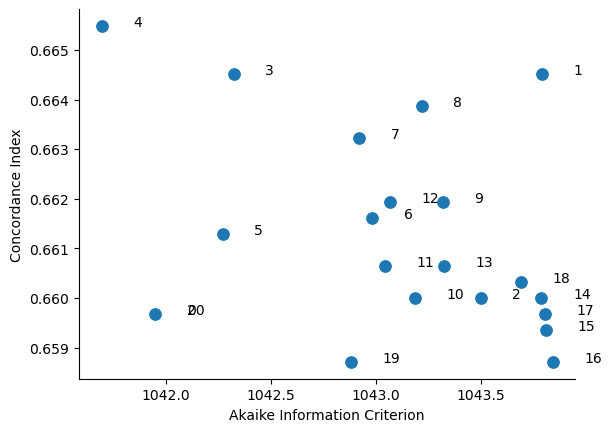

In [358]:
fig, ax = plt.subplots()

sns.scatterplot(data=df_AIC_thresholded,
            x='AIC',
            y='CI',
            # hue='Thresh',
              s=100,
              ax=ax
           )

for i, row in df_AIC_thresholded.iterrows():
    ax.text(row['AIC'] + 0.15, row['CI'], row['Thresh'])
    
plt.xlabel('Akaike Information Criterion')
plt.ylabel('Concordance Index')
    
sns.despine()
# plt.show()
plt.savefig("../results/figures/TCC/thresholded_NumVar1_AIC_CI.svg", bbox_inches='tight')

In [359]:
df_AIC_thresholded.LL.min()

-512.9757164421759

In [370]:
_, df_model_processed, cph_model = fit_cox_models_all_imputations(df_pids_for_outcomes_model,
                                                                                                  TRUST_phenos,
                                                                                                   TRUST_phenos,
                                                                                                  df_TCC,
                                                                                                  cols_lst,
                                                                                                  event_col = 'culture_convert',
                                                                                                  time_col = 'TCC',
                                                                                                 MIC_type = 'none',
                                                                                                  invert_OR=True,
                                                                                                  stratify_variables=stratify_covariates,
                                                                                                 binary_lineage=True,
                                                                                             PLI_thresh=PLI_thresh
                                                                                                 )

cph_model = cph_model[0]

    323 total pids


In [361]:
# adding unfixed variant burden actually worsens AIC (increases it). Not much difference to the LL or CI
cph_model.log_likelihood_, cph_model.AIC_partial_, cph_model.concordance_index_

(-513.2094832154249, 1040.4189664308499, 0.6635483870967742)

In [362]:
diversity_metric = 'NumVar1'
# diversity_metrics = ['NumVar2']
# diversity_metrics = ['NumVar1', 'NumVar2'] # don't put them both in. They are correlated
binarize = False
thresh = 3

df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid'] + [diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])
# df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid'] + [diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])

if binarize:
    df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > thresh).astype(int)
    model_variables = cols_lst + [diversity_metric]

# if not binarizing, then we're testing where the threshold is that the response is truly dose-dependent. 
# Based on stratified KM curves, it looks like the relationship is not dose-dependent at the low values. Probably because the distribution of the metric is not normal
elif diversity_metric != 'NumVarDiff':
    model_variables = cols_lst.copy()
    
    df_add_metric_for_model[f'{diversity_metric}_leq_{thresh}'] = df_add_metric_for_model[diversity_metric].clip(upper=thresh)
    df_add_metric_for_model[f'{diversity_metric}_above_{thresh}'] = (df_add_metric_for_model[diversity_metric] - thresh).clip(lower=0)
    model_variables += [f'{diversity_metric}_leq_{thresh}', f'{diversity_metric}_above_{thresh}']
    
else:
    # don't binarize because it's an integer, not a natral number
    model_variables = cols_lst + [diversity_metric]

df_test_results_diversity, _, _ = fit_cox_models_all_imputations(df_add_metric_for_model,
                                                              TRUST_phenos, 
                                                                TRUST_phenos,
                                                              df_imputed_TCC,
                                                           model_variables,
                                                              event_col = 'culture_convert',
                                                              time_col = 'TCC',
                                                              invert_OR=True,
                                                              stratify_variables=stratify_covariates,
                                                             binary_lineage=True,
                                                                 PLI_thresh=PLI_thresh
                                                             )

# convert to HR per 10 years
OR_col = 'HR_TCC_assoc'

df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin(['screen_years', 'human_PLI', 'predicted_PLI']), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin(['screen_years', 'human_PLI', 'predicted_PLI']), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

# convert to HR per 5 variants
df_test_results_diversity.loc[df_test_results_diversity['covariate']=='NumVar1', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results_diversity.loc[df_test_results_diversity['covariate']=='NumVar1', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

    323 total pids


In [363]:
df_test_results_diversity.query("pval <= 0.05").sort_values('pval')[['pval', 'covariate', f"{OR_col}_lower", OR_col, f"{OR_col}_upper"]]

,pval,covariate,HR_TCC_assoc_lower,HR_TCC_assoc,HR_TCC_assoc_upper
4,0.000049,TTP_baseline,0.159388,0.287154,0.517339
8,0.000733,screen_years,1.107468,1.270125,1.456670


In [367]:
labels_dict[f'{diversity_metric}_leq_{thresh}'] = f'Unfixed Variants ≤ {thresh}'
labels_dict[f'{diversity_metric}_above_{thresh}'] = f'Unfixed Variants > {thresh}'

forest_plot(df_test_results_diversity, 
            [f'{diversity_metric}_leq_{thresh}', f'{diversity_metric}_above_{thresh}'] + covariates_order,
            labels_dict,
            val_col='HR_TCC_assoc', 
            alpha=0.05,
            log=False, 
            pval_offset=1.05, 
            df_stratify_variables_results=None, 
            saveName="../results/figures/TCC/forest_plot_with_diversity.svg"
           )

df_test_results_diversity.to_csv("../results/TCC/Cox_model_results_with_diversity.csv", index=False)

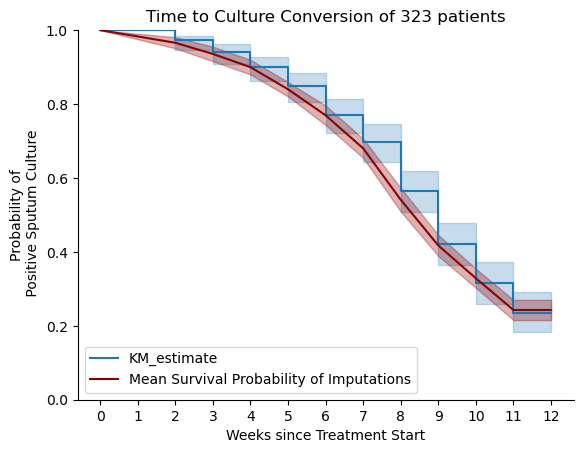

In [542]:
pids_with_TCC = df_model_processed[0].pid.unique()
df_imputed_TCC = df_imputed_TCC.query("pid in @pids_with_TCC")

median_survival_imputations = {}

# Prepare a list to collect survival functions from each imputation
survival_curves = []

# Fit Kaplan-Meier for each imputation and store survival function
for imp in df_imputed_TCC['imp_num'].unique():
    
    if imp > 0:
        imputed_data = df_imputed_TCC.query("imp_num==@imp")

        kmf = lifelines.KaplanMeierFitter()
        kmf.fit(durations=imputed_data['TCC'], event_observed=imputed_data['culture_convert'])

        survival_curves.append(kmf.survival_function_.rename(columns={"KM_estimate": f"imp_{imp}"}))

        median_survival_imputations[imp] = kmf.median_survival_time_

# Combine all imputed survival functions into one DataFrame
df_survival = pd.concat(survival_curves, axis=1)

kmf_full_dataset = lifelines.KaplanMeierFitter()
kmf_full_dataset.fit(df_TCC.query("pid in @pids_with_TCC")['TCC'], event_observed=df_TCC.query("pid in @pids_with_TCC")['culture_convert'])

fig, ax = plt.subplots()

kmf_full_dataset.plot_survival_function()#show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5})
plt.ylim(0, 1)

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, df_imputed_TCC.TCC.max() + 1))

mean_survival = df_survival.mean(axis=1)
sd_survival = df_survival.std(axis=1)

# plot the mean survival probability at each week across the imputations
# plt.step(df_survival.index, mean_survival, label='KM Estimate of Imputed Datasets', where='post')
plt.plot(df_survival.index, mean_survival, label='Mean Survival Probability of Imputations', color='darkred')#, where='post')

# Calculate and plot the confidence interval using 1.96 * std for ~95% CI
ci_upper = mean_survival + 1.96 * sd_survival
ci_lower = mean_survival - 1.96 * sd_survival

# 'tab:blue'
plt.fill_between(df_survival.index, ci_lower, ci_upper, alpha=0.3, color='darkred')#, label='95% CI')

plt.title(f"Time to Culture Conversion of {df_imputed_TCC.pid.nunique()} patients")
plt.ylabel("Probability of\n Positive Sputum Culture") #
plt.xlabel("Weeks since Treatment Start")

plt.gca().get_legend().remove()
plt.legend()

sns.despine()
plt.savefig(f"/home/sak0914/MtbLongitudinalDiversity/results/figures/TCC/KM_estimate.svg", bbox_inches='tight')

In [88]:
diversity_metrics = ['NumVar1']
# diversity_metrics = ['NumVar2']
# diversity_metrics = ['NumVar1', 'NumVar2'] # don't put them both in. They are correlated
binarize = True
thresh = 4

df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid'] + diversity_metrics]).query("pid in @df_TCC.pid")
len(df_add_metric_for_model)

323

251
72
Balanced: p = 0.2208
Early: p = 0.3136
Late: p = 0.1653


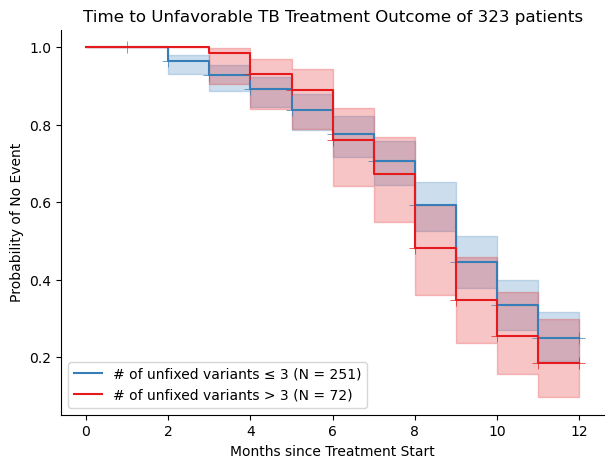

In [373]:
thresh = 3

df_KM_plot = df_TCC.merge(df_LAF_baseline[['pid', 'NumVar1']]).query("pid in @df_model_processed[0].pid")
df_KM_plot['NumVar1'] = df_KM_plot['NumVar1'].astype(int)
df_KM_plot['var_group'] = (df_KM_plot['NumVar1'] > thresh).astype(int)

fig, ax = plt.subplots(figsize=(7, 5))

kmf = lifelines.KaplanMeierFitter()

# stratify_col = f'{diversity_metric}_Binary'
# df_KM_plot[stratify_col] = (df_KM_plot[diversity_metric] > thresh).astype(int)
# label_dict = {0: f'# Low-AF Sites ≤ {thresh}', 1: f'# Low-AF Sites > {thresh}'}
# color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

stratify_col = 'var_group'

color_dict = {0: sns.color_palette('Set1').as_hex()[1], 1: sns.color_palette('Set1').as_hex()[0]}
label_dict = {0: f"≤ {thresh}", 1: f"> {thresh}"}

for group in np.sort(df_KM_plot[stratify_col].unique()):
    
    df_single_group = df_KM_plot.query(f"{stratify_col}==@group")
    print(len(df_single_group))

    kmf.fit(df_single_group['TCC'], event_observed=df_single_group['culture_convert'])
    
    kmf.plot_survival_function(ax=ax, 
                               show_censors=True, 
                               color=color_dict[group], 
                               censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                               label=f"# of unfixed variants {label_dict[group]} (N = {len(df_single_group)})",
                              )

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_KM_plot.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

logRank_balanced_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['TCC'], df_KM_plot[stratify_col], df_KM_plot['culture_convert'], p=0, q=0, weightings="fleming-harrington").p_value
logRank_early_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['TCC'], df_KM_plot[stratify_col], df_KM_plot['culture_convert'], p=1, q=0, weightings="fleming-harrington").p_value
logRank_late_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['TCC'], df_KM_plot[stratify_col], df_KM_plot['culture_convert'], p=0, q=1, weightings="fleming-harrington").p_value

print(f"Balanced: p = {np.round(logRank_balanced_pval, 4)}")
print(f"Early: p = {np.round(logRank_early_pval, 4)}")
print(f"Late: p = {np.round(logRank_late_pval, 4)}")

plt.legend(loc='lower left')
sns.despine()
# plt.savefig(f"../results/figures/outcomes/KM_estimate_binarized_{thresh}.svg", bbox_inches='tight')

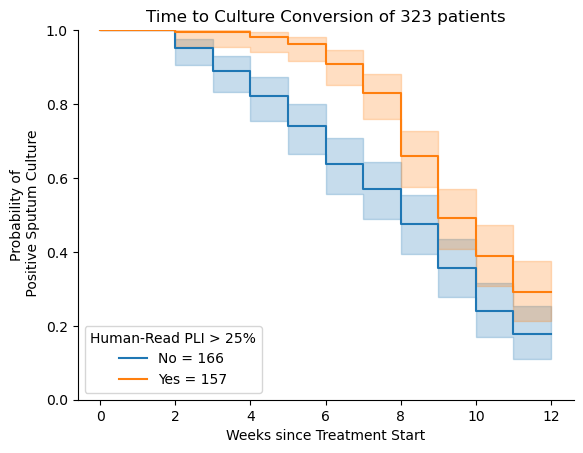

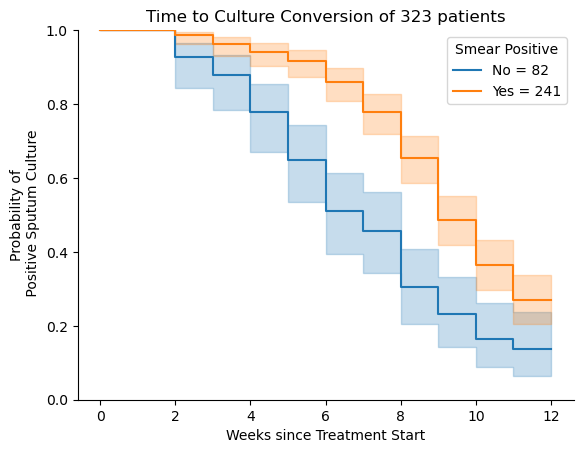

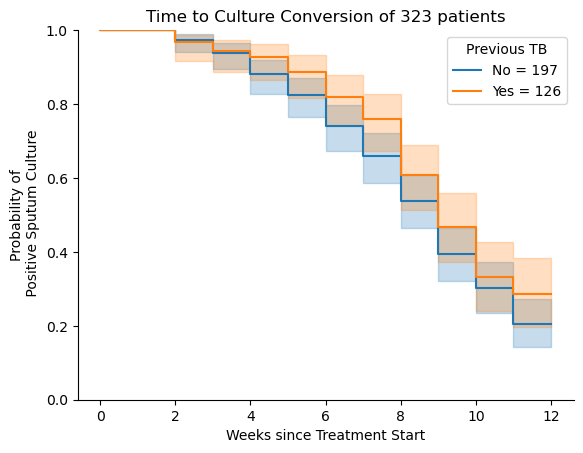

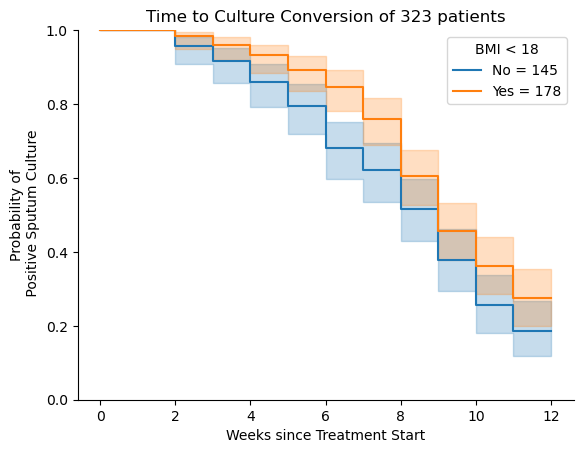

In [543]:
df_check_stratify_vars = df_pids_for_outcomes_model.query("pid in @pids_with_TCC").merge(df_TCC, on='pid')

categorical_cols = ['human_high_lung_involvement', 'smear_pos_no_contam_sputum_specimen_1', 'bl_prevtb', 'underweight'] #['HIV_CD4', 'smear_pos_no_contam_sputum_specimen_1', 'underweight', 'screen_sex']#, 'smoked_substance_use']
labels_lst = [f'Human-Read PLI > {PLI_thresh}%', 'Smear Positive', 'Previous TB', 'BMI < 18']#, 'Smoked Substance']

legend_name_dict = dict(zip(categorical_cols, labels_lst))

df_logrank_pvalues = pd.DataFrame(columns = ['covariate', 'pval', 'TCC_ratio']).set_index('covariate')

for variable in categorical_cols:
    
    fig, ax = plt.subplots()
    
    df_single_variable = df_check_stratify_vars.dropna(subset=variable)
    df_single_variable[variable] = df_single_variable[variable].astype(int)
    
    if variable == 'HIV_CD4':
        legend_marker_dict = {0: 'HIV–', 1: 'HIV+, CD4 ≥ 200 cells/mm\u00B3', 2: 'HIV+, CD4 < 200 cells/mm\u00B3'}
        color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))
    # elif variable == 'Lineage 2':
    #     legend_marker_dict = {1: 'L1', 2: 'L2', 3: 'L3', 4: 'L4'}
    #     color_dict = {1: "#DF83AC", 2: "#7098CB", 3: "#815D9F", 4: "#E76956"}
    else:
        legend_marker_dict = {0: 'No', 1: 'Yes'}
        color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

    # sort so that 0 is plotted before 1
    for group in np.sort(df_single_variable[variable].unique()):
        
        df_single_group = df_single_variable.query(f"{variable}==@group")
            
        kmf = lifelines.KaplanMeierFitter()
        kmf.fit(df_single_group['TCC'], event_observed=df_single_group['culture_convert'], label=group)
        kmf.plot_survival_function(ax=ax, show_censors=False, color=color_dict[group], censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, label=f"{legend_marker_dict[group]} = {len(df_single_group)}")

        if variable != 'HIV_CD4':
            plt.legend(title=legend_name_dict[variable])

    # HIV with high CD4 and HIV-negative are not significantly different, so just compare HIV with low CD4 to the other 2 groups
    if variable == 'HIV_CD4':
        
        # do them separately for each of the two HIV groups relative to the no HIV group
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==1")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==1")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )
        
        df_logrank_pvalues.loc['HIV_High_CD4', :] = [logRank_test_results.p_value,
                                                     df_single_variable.query(f"{variable}==1")['TCC'].mean() / df_single_variable.query(f"{variable}==0")['TCC'].mean()
                                                    ]
        
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==2")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==2")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )
        
        df_logrank_pvalues.loc['HIV_Low_CD4', :] = [logRank_test_results.p_value, 
                                                    df_single_variable.query(f"{variable}==2")['TCC'].mean() / df_single_variable.query(f"{variable}==0")['TCC'].mean()
                                                   ]
        
    else:
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==1")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==1")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )
        
        df_logrank_pvalues.loc[variable, :] = [logRank_test_results.p_value, 
                                               df_single_variable.query(f"{variable}==1")['TCC'].mean() / df_single_variable.query(f"{variable}==0")['TCC'].mean()
                                              ]

    # print(f"{legend_name_dict[variable]}: χ^2 = {logRank_test_results.test_statistic}, p = {logRank_test_results.p_value}")
    plt.ylim(0, 1)

    sns.despine()
    plt.title(f"Time to Culture Conversion of {df_single_variable.pid.nunique()} patients")
    plt.ylabel("Probability of\n Positive Sputum Culture") #
    plt.xlabel("Weeks since Treatment Start")
    sns.despine()
            
    if variable in stratify_covariates:
        #plt.show()
        plt.savefig(f"/home/sak0914/MtbLongitudinalDiversity/results/figures/TCC/KM_estimate_stratified_{legend_name_dict[variable]}.svg", bbox_inches='tight')
    else:
        plt.close()
    
df_logrank_pvalues.sort_values('pval').to_csv("/home/sak0914/MtbLongitudinalDiversity/results/TCC/KM_logRank_test_pvalues.csv")

In [136]:
df_logrank_pvalues.sort_values('pval')#.pval.values

,pval,TCC_ratio
covariate,,
smear_pos_no_contam_sputum_specimen_1,0.0,1.291674
human_high_lung_involvement,0.000066,1.241909
underweight,0.017278,1.103082
bl_prevtb,0.10827,1.029863


In [316]:
df_LAF_baseline

,pid,SE1,SASE1,NumVar1,Coll2014,Freschi2020,Lineage,F2,s_ttp_sputum_specimen_1,NumIndels,NumSNVs,NumPhaseVariants
0,T0004,0.717554,0.358777,2,2.2.1.1,2.2.1.1.1,2,0.011212,251.0,1,1,0
1,T0183,0.317472,0.317472,1,4.4.1.1,4.2.1.2.2.1.1,4,0.008850,134.0,0,1,0
2,T0184,2.159082,0.431816,5,4.1.1.3,4.1.i1.2.1,4,0.018669,313.0,0,5,0
3,T0185,0,0,0,4.1.1.1,4.1.i1.2.1,4,0.007504,83.0,0,0,0
4,T0186,0,0,0,4.8,4.2.1.1.1.1.1.1.i1,4,0.009906,153.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
390,T0173,0,0,0,4.3.3,4.2.1.2.1.1.i4.1,4,0.007304,99.0,0,0,0
391,T0176,0.329846,0.329846,1,2.2.1.1,2.2.1.1.1,2,0.011959,164.0,0,1,0
392,T0179,2.037693,0.679231,3,4.1.1.3,4.1.i1.2.1,4,0.019837,150.0,1,2,0
393,T0180,0.375212,0.375212,1,2.2.1.1,2.2.1.1.1,2,0.010201,83.0,0,1,0


In [408]:
enriched_genes = ['sugI', 'devR', 'phoR', 'Rv2690c',
                  'Rv1830', 'whiB6', 'devS', 'virS',
                  'NC_2516', 'subI', 'Rv1733c', 'Rv3220c',
                  'ceoB', 'mtrA', 'Rv33861', 'katG'
                 ]

In [409]:
df_LAF_baseline_enriched_genes = df_combined_variants_baseline.query("Region in @enriched_genes & AF >= 0.05 & AF <= 0.95").groupby('pid')['POS'].count().reset_index().rename(columns={'POS': 'NumVar1_enriched_genes'})

if 'NumVar1_enriched_genes' in df_LAF_baseline.columns:
    del df_LAF_baseline['NumVar1_enriched_genes']
    
df_LAF_baseline = df_LAF_baseline.merge(df_LAF_baseline_enriched_genes, how='left')
df_LAF_baseline['NumVar1_enriched_genes'] = df_LAF_baseline['NumVar1_enriched_genes'].fillna(0).astype(int)

df_LAF_baseline['NumVar1_enriched_genes_binary'] = (df_LAF_baseline['NumVar1_enriched_genes'] > 0).astype(int)

In [414]:
st.spearmanr(df_LAF_baseline['NumVar1'],
             df_LAF_baseline['NumVar1_enriched_genes']
            )

SignificanceResult(statistic=0.4750797464079504, pvalue=1.2433468837052473e-23)

In [420]:
df_LAF_baseline['High_BL_Diversity'] = (df_LAF_baseline['NumVar1'] > 3).astype(int)

contingency_table = pd.crosstab(df_LAF_baseline['High_BL_Diversity'], df_LAF_baseline['NumVar1_enriched_genes_binary'])

In [421]:
chi2, p, dof, expected = st.chi2_contingency(contingency_table)
p

2.8293290374548965e-10

In [422]:
expected

array([[233.18987342,  68.81012658],
       [ 71.81012658,  21.18987342]])

In [423]:
contingency_table

NumVar1_enriched_genes_binary,0,1
High_BL_Diversity,,
0,256,46
1,49,44


## Composite Poor Outcomes

In [126]:
# to_studyto_treatment_outcome column. 
# Other descriptions in to_studyto_other_treatment_outcome
# additional comments in to_comments_treatment_outcome
treatment_outcome_dict = {1: 'cure',
                          2: 'complete',
                          3: 'defaulted', # typically they stopped taking treatment entirely, not just interruption. May have been doctor-recommended, like due to liver injury or something
                          4: 'failure',
                          5: 'extension',
                          6: 'death',
                          7: 'transferred',
                          8: 'lost_fu',
                          9: 'other'
                        }

# esp_reason_end_of_study_parti column
# Other descriptions in esp_reasonoth_end_of_study_parti
esp_dict = {1: 'complete', # completed all study requirements
            2: 'inappropriate', # should not have been included in the study
            3: 'withdrew',
            4: 'failure', # includes both groups 4 and 5 in treatment_outcome_dict, meaning the patient was culture positive at month 5 or tx was extended
            5: 'relapse',
            6: 'moved', # moved/transferred out,
            7: 'lost_fu',
            8: 'death',
            9: 'other'
            }

cols_lst = [
            'screen_sex',
            'screen_years',
            # 'advanced_age',
            'underweight',
            'fstrom1_baseline', # smoking yes or no
            # 'smoked_substance_use',
            # 'peth_value_baseline',
            'HIV_CD4',
            'bl_prevtb',
            # 'TTP_baseline', # too much missingness, so don't include. But keep in TCC model because it's actually associated with TCC
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            # 'adherence_rate_by_observed',
            # 'high_lung_involvement',
            'human_PLI',
            # 'human_high_lung_involvement',
            # 'cxr_effusion_chest_radiograph_1',
            # 'cavities_present',
            # 'cxr_cavity_chest_radiograph_1',
            # 'RIF_AUC',
            # 'predicted_PLI',
            # 'cxr_cavity_chest_radiograph_1',
            # 'Lineage', # Lineage_3 is so rare and causes instabilities / needs to be stratified by
            # 'F2',
            # 'MixedInfect',
            # 'TBtypeR_MixedInfect',
            # 'Phase_Variant',
           ]

tb_deaths_only = True

# try these first, as they were required for the full TCC model
stratify_covariates = []
# non_linear_term_variables = ['screen_years']
non_linear_term_variables = []

MIC_type = 'none'

df_tx_outcomes_full = pd.read_csv(f"{TRUST_data_dir}/tx_outcomes.csv")
df_tx_outcomes = pd.read_csv(f"{TRUST_data_dir}/tx_outcomes.csv").query("pid in @df_pids_for_outcomes_model.pid")

# idk what this is, but some events occurred soon after the ESP date, which seems to suggest that the event is valid, but the ESP date was just recorded too early
# so include events up to 2 years after screen_date
df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti'], 'event'] = 0
df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti'], 'censor_date'] = df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti']]['esp_date_end_of_study_parti']
df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti'], 'date'] = df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti']]['time_in_trial']

# max_thresh = 365*2
# df_tx_outcomes.loc[df_tx_outcomes['date'] > max_thresh, 'event'] = 0
# df_tx_outcomes.loc[df_tx_outcomes['date'] > max_thresh, 'censor_date'] = df_tx_outcomes.loc[df_tx_outcomes['date'] > max_thresh]['esp_date_end_of_study_parti']
# df_tx_outcomes.loc[df_tx_outcomes['date'] > max_thresh, 'date'] = df_tx_outcomes.loc[df_tx_outcomes['date'] > max_thresh]['time_in_trial']

df_tx_outcomes['weeks'] = df_tx_outcomes['date'] / 7
df_tx_outcomes['months'] = df_tx_outcomes['date'] / 30

print(f"Maximum event date: {df_tx_outcomes.weeks.max()} weeks")

Maximum event date: 99.0 weeks


In [127]:
df_tx_outcomes.merge(df_pids_for_outcomes_model.dropna(subset='smear_pos_no_contam_sputum_specimen_1'), on='pid').event.value_counts()

event
0    334
1     30
Name: count, dtype: int64

In [128]:
df_tx_outcomes.merge(df_pids_for_outcomes_model.dropna(subset='smear_pos_no_contam_sputum_specimen_1'), on='pid').query("event==1 & TB_death==0")

,pid,date,event_type,to_studyto_treatment_outcome_x,esp_reason_end_of_study_parti_x,esp_reasonoth_end_of_study_parti_x,esp_date_end_of_study_parti_x,waiver_reason_end_of_study_parti_x,esp_cod_end_of_study_parti_x,waiver_deathcause_end_of_study_parti_x,...,High_TTP,advanced_age,Age_Squared,predicted_PLI,human_PLI,cavities_present,human_high_lung_involvement,n_phy,TBtypeR_MixedInfect,Phase_Variant
3,T0046,304.0,death,1.0,8.0,NaN,2018-12-05,4.0,Probably cancer of oesophagus. (According to f...,Esophageal cancer,...,0,1,3600,44.448162,38.0,0.0,1,1,0,0
5,T0051,481.0,death,1.0,8.0,NaN,2019-06-13,4.0,Cancer,Cancer,...,1,0,1764,19.002690,16.0,1.0,0,1,0,0
17,T0182,53.0,death,6.0,8.0,NaN,2019-10-09,4.0,Car accident,Car accident,...,0,0,1369,24.146807,16.0,1.0,0,1,0,0
19,T0197,350.0,death,1.0,8.0,NaN,2020-10-22,4.0,Cardiovascular Accident,Heart attack,...,0,1,2916,26.137562,30.0,0.0,1,1,0,0
38,T0399,217.0,death,1.0,8.0,NaN,2023-09-29,4.0,"Unknown, participant was referred for psycholo...",Lung cancer,...,0,1,4096,19.684391,48.0,1.0,1,1,0,0


In [136]:
df_tx_outcomes.merge(df_pids_for_outcomes_model.dropna(subset='smear_pos_no_contam_sputum_specimen_1'), on='pid').query("event==1").event_type.value_counts()

event_type
relapse       12
tx_failure    10
death          8
Name: count, dtype: int64

In [123]:
df_trust_patients.query("pid in ['T0116', 'T0305', 'T0322', 'T0441']").drop_duplicates(subset='pid')[['pid', 'to_studyto_treatment_outcome', 'esp_reason_end_of_study_parti']]

,pid,to_studyto_treatment_outcome,esp_reason_end_of_study_parti
232,T0441,1,1.0
340,T0116,1,1.0
563,T0322,5,4.0
762,T0305,1,1.0


In [139]:
q1 = np.percentile(df_tx_outcomes.query("esp_reason_end_of_study_parti != 7").dropna(subset='time_in_trial')['time_in_trial'], 25) / 365
q2 = np.percentile(df_tx_outcomes.query("esp_reason_end_of_study_parti != 7").dropna(subset='time_in_trial')['time_in_trial'], 50) / 365
q3 = np.percentile(df_tx_outcomes.query("esp_reason_end_of_study_parti != 7").dropna(subset='time_in_trial')['time_in_trial'], 75) / 365

q2, q3 - q1

(1.4958904109589042, 0.12876712328767126)

In [141]:
0.13*365, 0.13*12

(47.45, 1.56)

In [156]:
df_tx_outcomes.query("esp_reason_end_of_study_parti != 7").time_in_trial.max()

693.0

In [151]:
df_tx_outcomes.query("event==1 & TB_death != 0").event_type.value_counts()

event_type
relapse       12
tx_failure    10
death          3
Name: count, dtype: int64

In [80]:
# df_lowAF_variants_baseline.query("GENE in ['sugI', 'dacB1-sugI']")

In [309]:
df_tx_outcomes.query("pid in @df_baseline_samples.pid").query("TB_death != 0 & event == 1").event_type.value_counts()

event_type
relapse       12
tx_failure    10
death          3
Name: count, dtype: int64

In [310]:
27 / len(df_tx_outcomes.query("pid in @df_baseline_samples.pid"))

0.07377049180327869

In [311]:
binary_cols = ['diabetes', 'bl_prevtb', 'underweight', 'fstrom1_baseline']

for col in binary_cols:
    print(col, df_pids_for_outcomes_model[col].sum(), df_pids_for_outcomes_model[col].mean())

diabetes 17 0.04644808743169399
bl_prevtb 141 0.38524590163934425
underweight 199 0.5437158469945356
fstrom1_baseline 251.0 0.6857923497267759


In [312]:
df_pids_for_outcomes_model['screen_years'].min(), df_pids_for_outcomes_model['screen_years'].max(), df_pids_for_outcomes_model['screen_years'].median()

(15, 77, 37.0)

In [313]:
df_pids_for_outcomes_model['HIV_CD4'].value_counts()

HIV_CD4
0.0    264
1.0     61
2.0     36
Name: count, dtype: int64

In [447]:
df_pids_for_outcomes_model['screen_sex'].value_counts()

screen_sex
1    226
0    146
Name: count, dtype: int64

In [448]:
214 / len(df_pids_for_outcomes_model), len(df_pids_for_outcomes_model)

(0.5752688172043011, 372)

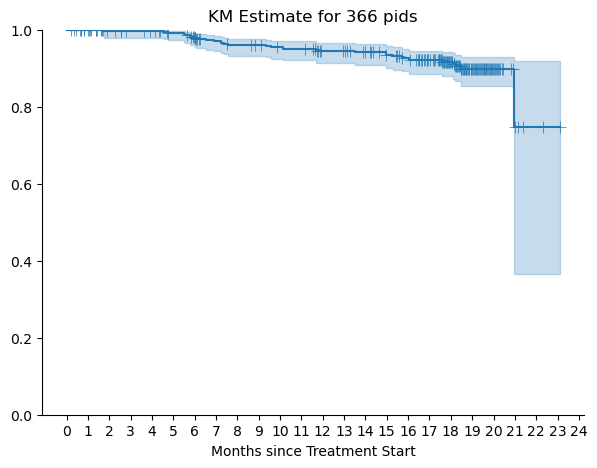

In [314]:
fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_tx_outcomes.months.max()))

kmf = lifelines.KaplanMeierFitter()

kmf.fit(df_tx_outcomes['months'], event_observed=df_tx_outcomes['event'],)# label=group_name)

kmf.plot_survival_function(ax=ax, 
                           show_censors=True, 
                           censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                           # label=f"# Sites ≥ {int(group)} = {len(df_single_group)}",
                          )

# Original event table (indexed by actual event/censor times)
event_table = kmf.event_table

# Define integer time points of interest
integer_times = np.arange(0, max_val + 1)

# Reindex to integer times
event_table_int = (
    event_table.reindex(integer_times, method="ffill").fillna(method="bfill")
)

# Now you can extract at-risk and censored at integer times
at_risk_int = event_table_int["at_risk"]
censored_int = event_table_int["censored"]

every_other_month = np.linspace(0, max_val, 13)

sns.despine()
ax.get_legend().remove()
plt.xlabel('Months since Treatment Start')
ax.set_xticks(range(0, max_val + 1))

plt.ylim(0, 1)
plt.title(f"KM Estimate for {df_tx_outcomes.pid.nunique()} pids")
plt.savefig("../results/figures/outcomes/KM_estimate.svg", bbox_inches='tight')

In [134]:
event_table_int[['at_risk', 'censored']].loc[every_other_month].T

event_at,0,2,4,6,8,10,12,14,16,18,20,22,24
at_risk,379,354,347,331,317,310,299,291,275,197,22,3,1
censored,0,1,1,1,0,1,1,1,1,4,1,1,1


In [451]:
df_pids_for_outcomes_model.shape, df_pids_for_outcomes_model.pid.nunique()

((372, 7904), 372)

In [452]:
df_pids_for_outcomes_model.pid.nunique()

372

In [453]:
df_pids_for_outcomes_model.F2.max()

0.0253793307962239

In [454]:
df_pids_for_outcomes_model.pid.nunique()

372

In [227]:
# df_age_knots = pd.DataFrame(columns = ['dof', 'AIC', 'LL', 'CI'])

# # age_spline_lb = np.percentile(df_model_processed['screen_years'], 25)
# # age_spline_ub = np.percentile(df_model_processed['screen_years'], 75)

# age_spline_lb = -0.8
# age_spline_ub = 0.8

# for i, dof in enumerate(np.arange(2, 9)):

#     df_test_results, df_model_processed, cph_model = fit_cox_models_all_imputations(df_pids_for_outcomes_model,#.query("pid in @df_LAF.pid"),
#                                                                                       TRUST_phenos,
#                                                                                        TRUST_phenos,
#                                                                                       df_tx_outcomes,
#                                                                                       cols_lst,
#                                                                                       event_col = 'event',
#                                                                                       time_col = 'date',
#                                                                                     MIC_type = 'none',
#                                                                                     binarize_drugs=['RIF'],
#                                                                                       tb_deaths_only=tb_deaths_only,
#                                                                                       invert_OR=False,
#                                                                                       stratify_variables=stratify_covariates,
#                                                                                     non_linear_term_variables=non_linear_term_variables,
#                                                                                     knots_tup=(age_spline_lb, age_spline_ub),
#                                                                                     number_nonlinear_knots=dof,
#                                                                                      binary_lineage=True,
#                                                                                     PLI_thresh=PLI_thresh
#                                                                                      )


#     # convert to HR per 10 years
#     OR_col = 'OR'
#     df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

#     df_violating_covariates = []

#     for model_idx in range(len(cph_model)):

#         df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_model[model_idx], df_model_processed[model_idx], time_transform='rank').summary

#         # diabetes has a p-value of like 0.0105
#         violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})

#         violating_covariates['imp_num'] = model_idx + 1

#         df_violating_covariates.append(violating_covariates)

#     df_violating_covariates = pd.concat(df_violating_covariates)
#     print(len(df_violating_covariates.query("p <= 0.05")))

#     df_model_processed = df_model_processed[0]
#     cph_model = cph_model[0]

#     cph_model.check_assumptions(df_model_processed)
    
#     df_age_knots.loc[i, :] = [dof, cph_model.AIC_partial_, cph_model.log_likelihood_, cph_model.concordance_index_]

In [129]:
labels_dict = {'RIF_AUC': 'Rifampicin PK AUC',
              'INH_AUC': 'Isoniazid PK AUC',
              'EMB_AUC': 'Ethambutol PK AUC',
              'PZA_AUC': 'Pyrazinamide PK AUC',
              'screen_sex': 'Male Sex',
              'screen_years': 'Age',
              'bl_bmi': 'Body Mass Index',
              'smoked_substance_use': 'Smoked Substance Use',
              'HIV_High_CD4': 'HIV, CD4 ≥ 200 cells/$\mathregular{mm^3}$',
              'HIV_Low_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$',
              'bl_prevtb': 'Previous TB Disease',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity at Baseline',
              'diabetes': 'Diabetes',
              'Lineage_1': 'Lineage 1',
              'Lineage_2': 'Lineage 2',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4',
              'total_adherence': 'Adherence Rate',
              'F2': 'F2 Strain Mixing Metric',
              'inh_resistant': 'INH Resistance',
              'high_lung_involvement': '>20% Lung Affected',
              'RIF_pred_MIC': 'Predicted RIF MIC',
              'INH_pred_MIC': 'Predicted INH MIC',
              'EMB_pred_MIC': 'Predicted EMB MIC',
              'PZA_pred_MIC': 'Predicted PZA MIC',
              'RIF_midpoint': 'Measured RIF MIC',
              'INH_midpoint': 'Measured INH MIC',
              'EMB_midpoint': 'Measured EMB MIC',
              'PZA_midpoint': 'Measured PZA MIC',
               'delayed_TCC': 'TCC > 8 Weeks',
               'TTP_baseline': 'TTP at Baseline',
               'peth_value_baseline': 'PEth',
               'fstrom1_baseline': 'Smo"king',
               'RIF_pred_MIC_high': 'Predicted RIF MIC > 0.06 µg/mL',
               # 'INH_pred_MIC_high': 'Predicted Isoniazid MIC',
               'PZA_pred_MIC_high': 'Predicted Pyrazinamide MIC > 24.6 µg/mL',
               'HIV_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$', # when we computed the relative risk, it was this group vs. the other two groups,
               'high_lung_involvement': f'PLI > {PLI_thresh}%',
               'Not_Lineage_2': 'Not Lineage 2',
               # 'NumVar': '# of low-AF Segregating Sites',
               # 'NumVar1': '# of low-AF Sites at Baseline',
               # 'NumVar2': '# of low-AF Sites at Follow-Up',
               'NumVar1': 'Unfixed Variants at Baseline',
               'NumVar2': 'Unfixed Variants at Follow-Up',
               'ChangeSites': '# of low-AF Sites with a Change',
               'underweight': 'BMI < 18',
               'adherence_rate_by_observed': 'Tx Adherence',
               'SASE1': 'Site-Averaged Shannon Entropy at Baseline',
               'cxr_cavity_chest_radiograph_1': 'Cavitation',
               'predicted_PLI': 'Percent Lung Involvement',
               'advanced_age': f'> {age_thresh} years',
               'NumSNVs': 'Unfixed SNVs at Baseline',
               'NumIndels': 'Unfixed Indels at Baseline',
               'NumPhaseVariants': 'Unfixed Phase Variants at Baseline',
               'human_PLI': 'Percent Lung Involvement',
               'human_high_lung_involvement': f'Human-Read PLI > {PLI_thresh}%',
               'cavities_present': 'Cavitation'
               # f'bs(screen_years, knots=({age_spline_lb}, 0.8), lower_bound=-2, upper_bound=4, degree=0)[1]': 'Age < 25th Percentile',
               # f'bs(screen_years, knots=({age_spline_lb}, 0.8), lower_bound=-2, upper_bound=4, degree=0)[2]': 'Age > 75th Percentile'
             }

# Univariate Patient Associations

In [130]:
df_univariate_associations = []

for col in cols_lst + ['TTP_baseline']:# + ['NumVar1']:# + # + list(df_pids_for_outcomes_model.columns[df_pids_for_outcomes_model.columns.str.contains('AUC')]):
    
    if col in ['NumSNVs', 'NumVar1', 'NumVar2', 'NumIndels']:
        df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid'] + [col]])#.query("pid in @pids_with
    else:
        df_add_metric_for_model = df_pids_for_outcomes_model.copy()
    
    df_test_results, df_model_processed, cph_model = fit_cox_models_all_imputations(df_add_metric_for_model,#.query("pid in @pids_with_low_F2"),
                                                                                  TRUST_phenos,
                                                                                   TRUST_phenos,
                                                                                  df_tx_outcomes,
                                                                                    [col],
                                                                                  event_col = 'event',
                                                                                  time_col = 'date',
                                                                                MIC_type = 'none',
                                                                                  # MIC_type=MIC_type,
                                                                                 # include_drugs=['RIF'],
                                                                                 # binarize_drugs=['RIF'],
                                                                                  tb_deaths_only=tb_deaths_only,
                                                                                  invert_OR=False,
                                                                                  stratify_variables=stratify_covariates,
                                                                                 binary_lineage=True,
                                                                                    PLI_thresh=PLI_thresh,
                                                                                 )


    # convert to HR per 10 years
    OR_col = 'OR'
    scale_lst = ['screen_years', 'human_PLI', 'predicted_PLI', 'RIF_AUC']
    df_test_results.loc[df_test_results['covariate'].isin(scale_lst), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate'].isin(scale_lst), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

    df_violating_covariates = []

    for model_idx in range(len(cph_model)):

        df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_model[model_idx], df_model_processed[model_idx], time_transform='rank').summary

        # diabetes has a p-value of like 0.0105
        violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})

        violating_covariates['imp_num'] = model_idx + 1

        df_violating_covariates.append(violating_covariates)

    df_violating_covariates = pd.concat(df_violating_covariates)
    
    if len(df_violating_covariates.query("p <= 0.05")) > 0:
        print(col, len(df_violating_covariates.query("p <= 0.05")))
        break
        
    df_model_processed = df_model_processed[0]
    cph_model = cph_model[0]

    cph_model.check_assumptions(df_model_processed)
    
#     if col == 'screen_years':
#         df_test_results[['OR', 'OR_lower', 'OR_upper']] = df_test_results[['OR', 'OR_lower', 'OR_upper']]**10
    
    df_univariate_associations.append(df_test_results)
    # print(f"    AIC: {cph_model.AIC_partial_}")
    # print(f"    Concordance Index: {cph_model.concordance_index_}")
    # print(f"    Log Likelihood: {cph_model.log_likelihood_}")

    # base_model_LL = cph_model.log_likelihood_
    
df_univariate_associations = pd.concat(df_univariate_associations)

# convert to HR per 10 years
OR_col = 'OR'
scale_cols = ['screen_years', 'RIF_AUC']
scale_factor = 5
df_univariate_associations.loc[df_univariate_associations['covariate'].isin(scale_cols), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_univariate_associations.loc[df_univariate_associations['covariate'].isin(scale_cols), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**scale_factor

OR_col = 'OR'
scale_cols = ['human_PLI', 'predicted_PLI']
scale_factor = 5
df_univariate_associations.loc[df_univariate_associations['covariate'].isin(scale_cols), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_univariate_associations.loc[df_univariate_associations['covariate'].isin(scale_cols), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**scale_factor

    Censored 6 patients with non-TB deaths
    366 total pids
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    366 total pids
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    366 total pids
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    366 total pids
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    366 total pids
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    366 total pids
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    364 total pids
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    366 total pids
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    366 total pids
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    353 tota

In [131]:
df_univariate_associations.query("pval <= 0.05")

,covariate,coef,exp(coef),se(coef),coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper
0,HIV_Low_CD4,0.324275,1.383028,0.154619,1.087408,0.518492,1,0.035971,2.966575,1.073778,8.195892
0,human_PLI,0.440299,1.553171,0.193399,0.023904,0.010500,1,0.022808,3.304215,1.180866,9.245617


In [132]:
outcomes_covariates_lst = list(df_univariate_associations.sort_values(['pval', 'OR'], ascending=[True, False]).covariate.values)

forest_plot(df_univariate_associations, 
            outcomes_covariates_lst,
            labels_dict, 
            val_col='OR', 
            alpha=0.05, 
            log=True, 
            pval_offset=1.25, 
            df_stratify_variables_results=None, 
            saveName="../results/figures/outcomes/forest_plot_univariate_assoc.svg"
           )


In [157]:
df_test_results, df_model_processed, cph_model = fit_cox_models_all_imputations(df_pids_for_outcomes_model,#.query("pid in @df_LAF.pid"),
                                                                                  TRUST_phenos,
                                                                                   TRUST_phenos,
                                                                                  df_tx_outcomes,
                                                                                  cols_lst,
                                                                                  event_col = 'event',
                                                                                  time_col = 'date',
                                                                                  tb_deaths_only=tb_deaths_only,
                                                                                  invert_OR=False,
                                                                                  stratify_variables=stratify_covariates,
                                                                                non_linear_term_variables=non_linear_term_variables,
                                                                                # knots_tup=(age_spline_lb, age_spline_ub),
                                                                                number_nonlinear_knots=2,
                                                                                 binary_lineage=True,
                                                                                PLI_thresh=PLI_thresh
                                                                                 )


# convert to HR per 10 years
# convert to HR per 10 years
OR_col = 'OR'
scale_cols = ['screen_years', 'RIF_AUC']
scale_factor = 5
df_test_results.loc[df_test_results['covariate'].isin(scale_cols), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate'].isin(scale_cols), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**scale_factor

OR_col = 'OR'
scale_cols = ['human_PLI', 'predicted_PLI']
scale_factor = 5
df_test_results.loc[df_test_results['covariate'].isin(scale_cols), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate'].isin(scale_cols), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**scale_factor

df_violating_covariates = []

for model_idx in range(len(cph_model)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_model[model_idx], df_model_processed[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)
print(len(df_violating_covariates.query("p <= 0.05")))

df_model_processed = df_model_processed[0]
cph_model = cph_model[0]

cph_model.check_assumptions(df_model_processed)
print(f"    AIC: {cph_model.AIC_partial_}")
print(f"    Concordance Index: {cph_model.concordance_index_}")
print(f"    Log Likelihood: {cph_model.log_likelihood_}")

base_model_LL = cph_model.log_likelihood_

    Censored 6 patients with non-TB deaths
    364 total pids
0
Proportional hazard assumption looks okay.
    AIC: 278.13436538556215
    Concordance Index: 0.6833059333432969
    Log Likelihood: -129.06718269278107


In [379]:
forest_plot(df_test_results,
            list(outcomes_covariates_lst),
            labels_dict, 
            val_col='OR', 
            alpha=0.05, 
            log=True, 
            pval_offset=1.25, 
            df_stratify_variables_results=None, 
            # x_lim=[0.01, 20],
            saveName="../results/figures/outcomes/forest_plot.svg"
           )


In [159]:
df_AIC_thresholded = pd.DataFrame(columns = ['Thresh', 'AIC', 'CI', 'LL'])

diversity_var = 'NumVar1'

df_diversity = df_LAF_baseline.copy()
# df_diversity = df_LAF.copy()

for i, thresh in enumerate(np.arange(df_diversity[diversity_var].min(), df_diversity[diversity_var].max() + 1)):
        
    try:
        AIC, CI, LL = find_best_variant_burden_binarization_threshold(df_pids_for_outcomes_model, 
                                                                  df_diversity, 
                                                                  df_tx_outcomes,
                                                                      cols_lst,
                                                                  'event',
                                                                  'date',
                                                                  tb_deaths_only,
                                                                  False,
                                                                  stratify_covariates,
                                                                  thresh, 
                                                                  binarize=False, 
                                                                  diversity_metric=diversity_var
                                                                 )
        df_AIC_thresholded.loc[i, :] = [thresh, AIC, CI, LL]
    except:
        print(f"{thresh} failed")

    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Fi

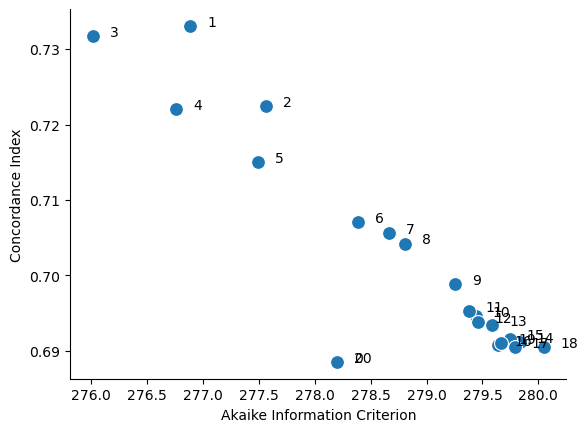

In [160]:
fig, ax = plt.subplots()

sns.scatterplot(data=df_AIC_thresholded,
            x='AIC',
            y='CI',
            # hue='Thresh',
              s=100,
              ax=ax
           )

for i, row in df_AIC_thresholded.iterrows():
    ax.text(row['AIC'] + 0.15, row['CI'], row['Thresh'])
    
plt.xlabel('Akaike Information Criterion')
plt.ylabel('Concordance Index')
    
sns.despine()
# plt.savefig(f"../results/figures/outcomes/thresholded_{diversity_var}_longitudinal_AIC_CI.svg", bbox_inches='tight')
plt.savefig(f"../results/figures/outcomes/thresholded_{diversity_var}_baseline_AIC_CI.svg", bbox_inches='tight')

In [172]:
diversity_metric = 'NumVar1'
binarize = False
thresh = 1

# df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid'] + [diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])
df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid'] + [diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])

if binarize:
    df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > thresh).astype(int)
    model_variables = cols_lst + [diversity_metric]

# if not binarizing, then we're testing where the threshold is that the response is truly dose-dependent. 
# Based on stratified KM curves, it looks like the relationship is not dose-dependent at the low values. Probably because the distribution of the metric is not normal
elif diversity_metric != 'NumVarDiff':
    model_variables = cols_lst.copy()
    
    df_add_metric_for_model[f'{diversity_metric}_leq_{thresh}'] = df_add_metric_for_model[diversity_metric].clip(upper=thresh)
    df_add_metric_for_model[f'{diversity_metric}_above_{thresh}'] = (df_add_metric_for_model[diversity_metric] - thresh).clip(lower=0)
    model_variables += [f'{diversity_metric}_leq_{thresh}', f'{diversity_metric}_above_{thresh}']
    
else:
    # don't binarize because it's an integer, not a natral number
    model_variables = cols_lst + [diversity_metric]

df_test_results_diversity, df_model_processed, cph_model = fit_cox_models_all_imputations(df_add_metric_for_model,
                                                              TRUST_phenos, 
                                                                TRUST_phenos,
                                                              df_tx_outcomes,
                                                           model_variables,
                                                              event_col = 'event',
                                                              time_col = 'date',
                                                                                          MIC_type='none',
                                                           # MIC_type=MIC_type,
                                                             # include_drugs=['RIF'],
                                                             # binarize_drugs=['RIF'],
                                                              tb_deaths_only=True,
                                                              invert_OR=False,
                                                              stratify_variables=stratify_covariates,
                                                                                          non_linear_term_variables=non_linear_term_variables,
                                                                                # knots_tup=(age_spline_lb, age_spline_ub),
                                                                                number_nonlinear_knots=2,
                                                             binary_lineage=True,
                                                                                          PLI_thresh=PLI_thresh
                                                             )

df_model_processed = df_model_processed[0]
cph_model = cph_model[0]

df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_model, df_model_processed, time_transform='rank').summary

# diabetes has a p-value of like 0.0105
df_violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
print(len(df_violating_covariates.query("p <= 0.05")))

OR_col = 'OR'

cph_model.check_assumptions(df_model_processed)
print(f"    AIC: {cph_model.AIC_partial_}")
print(f"    Concordance Index: {cph_model.concordance_index_}")
print(f"    Log Likelihood: {cph_model.log_likelihood_}")

diversity_metric_LL = cph_model.log_likelihood_

# scale age
if not binarize:
    scale_factor = 5
    scale_cols = ['screen_years', 'RIF_AUC']
    df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin(scale_cols), [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]] = df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin(scale_cols), [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]]**scale_factor

    scale_factor = 5
    scale_cols = ['predicted_PLI', 'human_PLI']
    df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin(scale_cols), [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]] = df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin(scale_cols), [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]]**scale_factor

    # for the unfixed variant burdens
    scale_factor = 5
    df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin([f'{diversity_metric}_above_{thresh}'] + [diversity_metric]), [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]] = df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin([f'{diversity_metric}_above_{thresh}'] + [diversity_metric]), [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]]**scale_factor

print(f"Final: {df_model_processed.pid.nunique()} pids")

    Censored 6 patients with non-TB deaths
    262 total pids
0
Proportional hazard assumption looks okay.
    AIC: 212.46160715282815
    Concordance Index: 0.7698159509202454
    Log Likelihood: -94.23080357641408
Final: 262 pids


In [163]:
def LRT(LL_1, LL_2):
    
    test_stat = np.abs(2 * (LL_1 - LL_2))

    # p-value from the chi-squared distribution
    return 1 - st.chi2.cdf(test_stat, 1)

In [167]:
LRT(diversity_metric_LL, base_model_LL)

0.013373487619671942

In [165]:
# Cox Snell Pseudo R^2.
# There is not a good consensus on how to compute R^2 for survival regression models, so I picked this one
1 - np.exp(2/len(df_model_processed) * (base_model_LL - diversity_metric_LL))

0.01666998821831578

In [173]:
df_test_results_diversity.query("pval <= 0.05").sort_values(['pval'])

,covariate,coef,exp(coef),se(coef),coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper
11,NumVar1_above_1,0.466936,1.595099,0.165229,0.168734,0.059708,1,0.004714,2.324880,1.295040,4.173669
0,human_PLI,0.628803,1.875364,0.235174,0.035930,0.013438,1,0.007500,1.196797,1.049130,1.365250
3,NumVar1_leq_1,-0.559168,0.571685,0.274952,-1.203566,0.591813,1,0.041982,0.300122,0.094091,0.957304


In [384]:
labels_dict[f'{diversity_metric}_leq_{thresh}'] = f'Unfixed Variants ≤ {thresh}'
labels_dict[f'{diversity_metric}_above_{thresh}'] = f'Unfixed Variants > {thresh}'

if binarize:
    forest_plot(df_test_results_diversity,
                [f'{diversity_metric}_leq_{thresh}', f'{diversity_metric}_above_{thresh}'] + list(outcomes_covariates_lst),
                labels_dict, 
                val_col='OR', 
                alpha=0.05, 
                log=True, 
                pval_offset=1.25, 
                df_stratify_variables_results=None, 
                # x_lim=[0.01, 20],
                saveName=f"../results/figures/outcomes/forest_plot_with_diversity_binarized_{thresh}.svg"
               )
else:
    forest_plot(df_test_results_diversity,
                [f'{diversity_metric}_leq_{thresh}', f'{diversity_metric}_above_{thresh}'] + list(outcomes_covariates_lst),
                labels_dict, 
                val_col='OR', 
                alpha=0.05, 
                log=True, 
                pval_offset=1.25, 
                df_stratify_variables_results=None, 
                # x_lim=[0.01, 20],
                 saveName=f"../results/figures/outcomes/forest_plot_with_diversity.svg"
               )

In [147]:
df_Trauner = pd.read_csv("~/MtbLongitudinalDiversity/data/Trauner_et_al_vSNPs.csv", index_col=[0])
df_Trauner['UNIQUE_ID'] = df_Trauner['PATIENT_ID'] + '_' + df_Trauner['TIME'].astype(str)

df_compare = df_Trauner.query("FREQUENCY >= 0.05 & FREQUENCY <= 0.95")

len(df_Trauner), len(df_compare)

(492, 204)

<Axes: xlabel='FREQUENCY', ylabel='Count'>

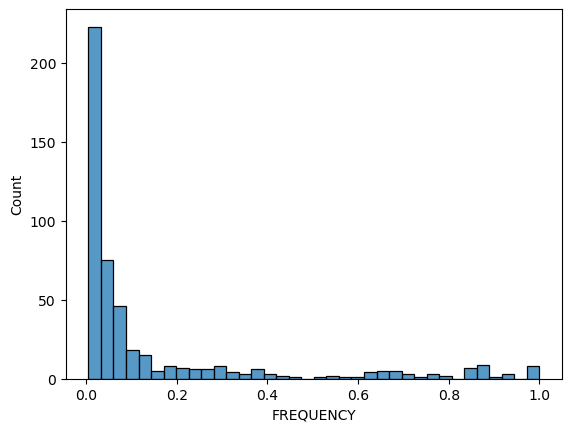

In [148]:
sns.histplot(data=df_Trauner,
             x='FREQUENCY'
            )

<Axes: xlabel='FREQUENCY', ylabel='Count'>

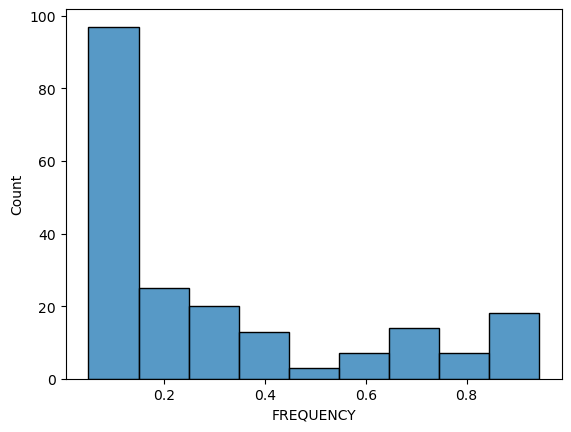

In [149]:
sns.histplot(data=df_compare,
             x='FREQUENCY'
            )

In [150]:
df_compare.PATIENT_ID.nunique()

12

In [151]:
df_compare_summary = pd.DataFrame(df_compare.groupby(['PATIENT_ID', 'TIME', 'UNIQUE_ID', 'RESISTANCE']).FREQUENCY.count()).reset_index()

df_compare_summary = pd.concat([df_compare_summary,
                                pd.DataFrame({'UNIQUE_ID': list(set(df_Trauner.UNIQUE_ID) - set(df_compare_summary.UNIQUE_ID)), 'FREQUENCY': 0})
                               ])

df_compare_summary.FREQUENCY.mean(), df_compare_summary.FREQUENCY.median(), len(df_compare_summary)

(4.25, 3.0, 48)

In [152]:
df_compare_summary.FREQUENCY.min(), df_compare_summary.FREQUENCY.max()

(0, 21)

In [290]:
df_to_compare_to_Trauner = pd.DataFrame(df_lowAF_variants.query("REF.str.len() == ALT.str.len()").groupby('SampleID')['POS'].count()).reset_index()


In [298]:
df_to_compare_to_Trauner.query("POS > 25")

,SampleID,POS,pid,Hr
292,MFS-578,26,T0116,True


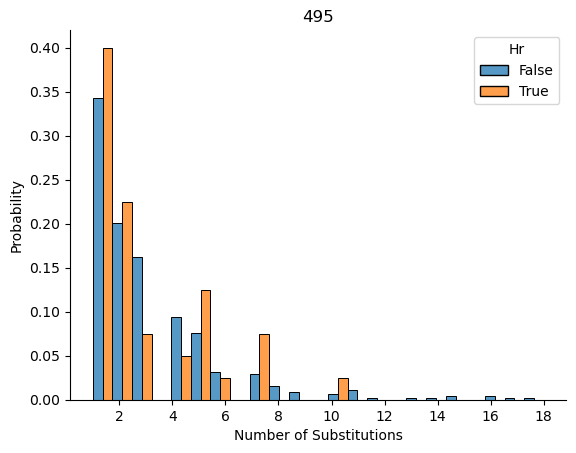

In [303]:
df_to_compare_to_Trauner = pd.DataFrame(df_lowAF_variants_full.query("REF.str.len() == ALT.str.len() & pid in @df_baseline_samples.pid").groupby('SampleID')['POS'].count()).reset_index()

df_to_compare_to_Trauner = df_to_compare_to_Trauner.merge(df_trust_patients[['pid', 'SampleID', 'bl_inh_monoresistant']]).rename(columns={'bl_inh_monoresistant': 'Hr'})

fig, ax = plt.subplots()

sns.histplot(data=df_to_compare_to_Trauner,
             hue='Hr',
             x='POS',
             common_norm=False,
             stat='probability',
             multiple='dodge',
             ax=ax
            )

plt.title(len(df_to_compare_to_Trauner))

from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.xlabel('Number of Substitutions')
sns.despine()
plt.show()

In [312]:
st.mannwhitneyu(df_to_compare_to_Trauner.query("Hr==True")['POS'],
                df_to_compare_to_Trauner.query("Hr==False")['POS'],
               )

MannwhitneyuResult(statistic=8281.0, pvalue=0.5560758178877374)

In [308]:
st.ttest_ind(df_to_compare_to_Trauner.query("Hr==True")['POS'],
                df_to_compare_to_Trauner.query("Hr==False")['POS'],
             equal_var=False
               )

TtestResult(statistic=-0.7103224422142964, pvalue=0.4807899480471346, df=50.21932658032302)

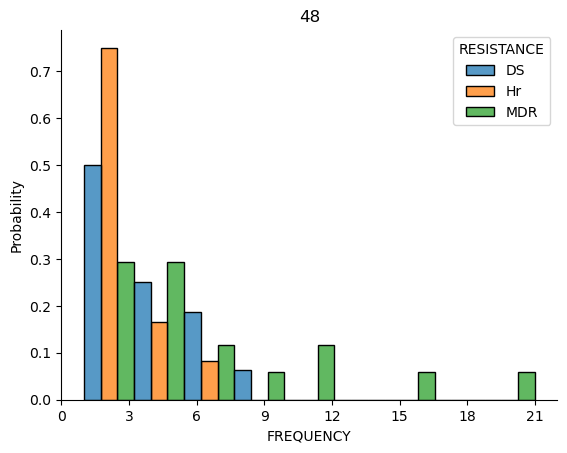

In [286]:
fig, ax = plt.subplots()

sns.histplot(data=df_compare_summary,
             x='FREQUENCY',
             hue='RESISTANCE',
             multiple='dodge',
             stat='probability',
             common_norm=False,
             ax=ax
            )

from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title(len(df_compare_summary))

sns.despine()
plt.show()

In [315]:
st.mannwhitneyu(df_to_compare_to_Trauner['POS'],
             df_compare_summary['FREQUENCY'],
                alternative='two-sided'
            )

MannwhitneyuResult(statistic=9049.0, pvalue=0.005186827558953068)

In [311]:
st.mannwhitneyu(df_to_compare_to_Trauner['POS'],
             df_compare_summary.query("RESISTANCE != 'MDR'")['FREQUENCY'],
            )

MannwhitneyuResult(statistic=7001.5, pvalue=0.40176168811242285)

In [310]:
st.ttest_ind(df_to_compare_to_Trauner['POS'],
             df_compare_summary.query("RESISTANCE != 'MDR'")['FREQUENCY'],
             equal_var=False
            )

TtestResult(statistic=0.06819571268053255, pvalue=0.9459982292214711, df=36.88133778562948)

In [242]:
df_compare_summary.groupby('RESISTANCE').FREQUENCY.mean()

RESISTANCE
DS     3.937500
Hr     2.583333
MDR    6.470588
Name: FREQUENCY, dtype: float64

In [243]:
df_compare_summary.RESISTANCE.value_counts()

RESISTANCE
MDR    17
DS     16
Hr     12
Name: count, dtype: int64

In [584]:
st.mannwhitneyu(df_compare_summary.query("RESISTANCE=='MDR'").FREQUENCY,
                df_compare_summary.query("RESISTANCE!='MDR'").FREQUENCY,
                alternative='greater'
               )

MannwhitneyuResult(statistic=387.5, pvalue=0.0035357701424450806)

In [250]:
st.ttest_ind(df_compare_summary['FREQUENCY'],
                df_to_compare_to_Trauner['POS'],
                alternative='greater',
             equal_var=False
               )

TtestResult(statistic=2.2157103868845076, pvalue=0.015316876267121374, df=58.23866346204788)

In [526]:
df_lowAF_variants_full.query("GENE.str.contains('Rv1830')")[['pid', 'SampleID', 'POS', 'AF']]

,pid,SampleID,POS,AF
114,T0235,MFS-144,2075037,0.095436
376,T0278,MFS-296,2075178,0.100000
665,T0341,MFS-416,2075106,0.266160
858,T0054,MFS-542,2075516,0.324910
865,T0054,MFS-543,2075516,0.755725
947,T0116,MFS-578,2075129,0.788136
1057,T0187,MFS-626,2075518,0.422111
1107,T0296,MFS-655,2075518,0.137255
1517,T0470,MFS-858,2075516,0.131034


In [361]:
st.spearmanr(df_LAF['NumVar1'], df_LAF['NumVar2'])

SignificanceResult(statistic=0.4294901862448232, pvalue=3.553083416483094e-14)

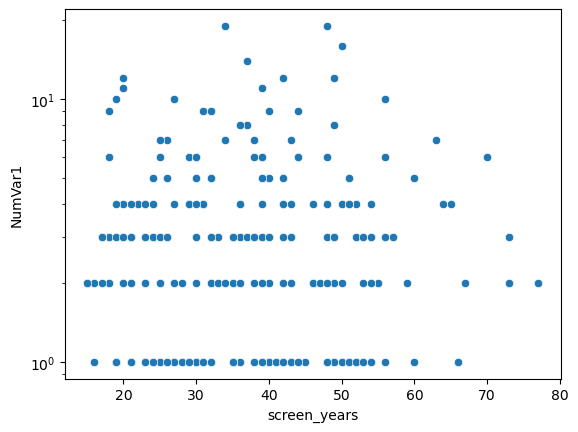

In [445]:
sns.scatterplot(data=df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid', 'NumVar1']]).dropna(subset=['screen_years', 'NumVar1']),
                x='screen_years',
                y='NumVar1'
               )

plt.yscale('log')

In [447]:
df_model_processed['NumVar1'].unique()

array([-0.22133991,  4.5179381 ])

In [450]:
df_model_processed[['pid', 'NumVar1']].merge(df_pids_for_outcomes_model).groupby('NumVar1').screen_years.mean()

NumVar1
-0.221340    37.247839
 4.517938    35.647059
Name: screen_years, dtype: float64

In [459]:
st.mannwhitneyu(df_model_processed[['pid', 'NumVar1']].merge(df_pids_for_outcomes_model).query("NumVar1 < 0").screen_years,
             df_model_processed[['pid', 'NumVar1']].merge(df_pids_for_outcomes_model).query("NumVar1 > 0").screen_years,
             alternative='less'
            )

MannwhitneyuResult(statistic=3126.5, pvalue=0.6624614140574139)

In [297]:
# scaler = StandardScaler()

# diversity_metric = 'NumVar1'
# raw_values = df_add_metric_for_model.query("pid in @df_model_processed.pid")[diversity_metric].values

# raw_mean = raw_values.mean()
# raw_sd = raw_values.std()

# scaled_values = (raw_values - raw_mean) / raw_sd

# def unscale_val(scaled_val, raw_mean, raw_sd):
#     # it should be an integer, so return it as such. If it's not, it's a float precision problem
#     return int(scaled_val * raw_sd + raw_mean)

# # percentiles_lst = [25, 50, 75, 87.5, 100]

# # if binarize:
# #     test_vals = df_model_processed[diversity_metric].unique()
# # else:
# #     test_vals = np.percentile(scaled_values, percentiles_lst)
    
# # percentile_dict = dict(zip(test_vals, percentiles_lst))

# test_vals = np.linspace(1, df_add_metric_for_model.NumVar1.max(), int(df_add_metric_for_model.NumVar1.max() / 2))
# test_vals = (test_vals - raw_mean) / raw_sd

# ax = cph_model.plot_partial_effects_on_outcome(covariates=diversity_metric, values=test_vals, plot_baseline=False, cmap='coolwarm')

# # Update legend labels
# handles, labels = ax.get_legend_handles_labels()
# # ax.legend(handles, [f"{perc}th perc. = {str(unscale_val(val, raw_mean, raw_sd))}" for val, perc in percentile_dict.items()])
# ax.legend(handles, [f"{str(unscale_val(val, raw_mean, raw_sd))}" for val in test_vals])
# ax.set_xlabel('Days since Treatment Start')

# sns.despine()
# # plt.savefig("../results/figures/outcomes/NumVar1_varying_hazard.svg", bbox_inches='tight')

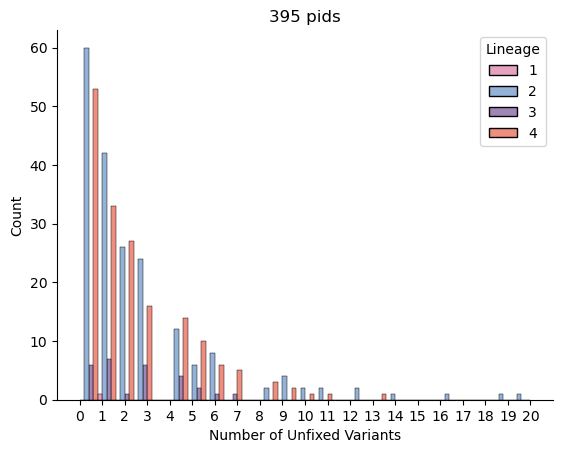

In [204]:
df_LAF_baseline['Lineage'] = df_LAF_baseline['Lineage'].astype(float).astype(int).astype(str)

fig, ax = plt.subplots()

plot_var = 'NumVar1'

LinToColor_Dict = {"1": "#DF83AC",
                   "2": "#7098CB",
                   "3": "#815D9F",
                   "4": "#E76956",
                   # "Other": "white"
                   # "5": "#B67548",
                   # "6": "#6AB79E",
                   # "8": "#E4515B",
                   # "M.bovis": "white",
                  }

    
sns.histplot(df_LAF_baseline,
             x=plot_var,
             hue='Lineage',
             multiple='dodge',
             # bins=range(int(df_add_metric_for_model[diversity_metric].min()), int(df_add_metric_for_model[diversity_metric].max()) + 2),
             hue_order=['1', '2', '3', '4'],
             palette=LinToColor_Dict,
             ax=ax
            )

# Force integer x-axis ticks
plt.xticks(
    np.arange(
        int(df_LAF_baseline[plot_var].min()),
        int(df_LAF_baseline[plot_var].max()) + 1
    )
)
plt.title(f"{df_LAF_baseline.pid.nunique()} pids")
plt.xlabel('Number of Unfixed Variants')

sns.despine()

plt.savefig(f"../results/figures/{plot_var}.svg", bbox_inches='tight')

In [324]:
# df_combined_counts = df_LAF_baseline.query("pid in @df_model_processed.pid")[['pid', 'Lineage', 'NumVar1']]
df_combined_counts = df_LAF_baseline[['pid', 'Lineage', 'NumVar1']]
df_combined_counts['Lineage'] = df_combined_counts['Lineage'].astype(int).astype(str)

lambda_params_dict = exponential_LRT(df_combined_counts, 'NumVar1', min_count=5)

print(f"Min: {df_combined_counts.NumVar1.min()}")
print(f"Median: {df_combined_counts.NumVar1.median()}")
print(f"Mean: {df_combined_counts.NumVar1.mean()}")
print(f"Max: {df_combined_counts.NumVar1.max()}")

λ for Lineage = 2: 0.40501043841336115
λ for Lineage = 3: 0.42424242424242425
λ for Lineage = 4: 0.44329896907216493
λ for full = 0.42229367631296894

Likelihood ratio test statistic: 0.743
P-value: 0.6897
Min: 0
Median: 1.0
Mean: 2.3645569620253166
Max: 20


In [79]:
df_LAF_baseline.NumVar1.sum()

920

In [666]:
df_LAF_baseline.query("NumVar1 != NumIndels + NumSNVs")

,pid,SE1,SASE1,NumVar1,Coll2014,Freschi2020,Lineage,F2,s_ttp_sputum_specimen_1,NumIndels,NumSNVs,NumPhaseVariants


In [626]:
def bin_by_min_count(values, min_count):
    """
    Group sorted values into bins with at least `min_count` elements.
    
    Parameters
    ----------
    values : array-like
        The input values.
    min_count : int
        Minimum number of elements per bin.
        
    Returns
    -------
    bins : list of arrays
        A list of arrays, each containing the values in that bin.
    edges : list of tuples
        (min, max) range for each bin.
    """
    values = np.sort(values)
    n = len(values)
    
    # Determine split indices
    splits = np.arange(min_count, n, min_count)
    bins = np.split(values, splits)
    
    # Merge last bin if it's too small
    if len(bins[-1]) < min_count and len(bins) > 1:
        bins[-2] = np.concatenate([bins[-2], bins[-1]])
        bins = bins[:-1]
    
    edges = [(b[0], b[-1]) for b in bins]
    return bins, edges

<Axes: xlabel='screen_years', ylabel='Proportion'>

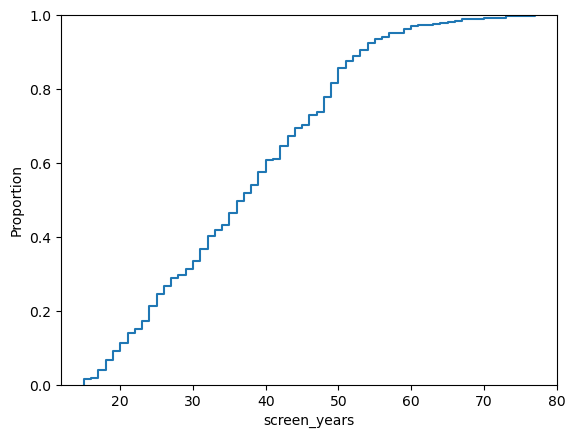

In [636]:
sns.ecdfplot(data=df_KM_plot,
             x='screen_years'
            )

In [328]:
df_KM_plot = df_add_metric_for_model.query("pid in @df_model_processed.pid").merge(df_tx_outcomes[['pid', 'event_type', 'TB_death', 'date', 'event', 'weeks', 'months']])

df_KM_plot['screen_years'] = df_KM_plot['screen_years'].astype(int)

df_KM_plot["var_group"] = pd.qcut(
    df_KM_plot["screen_years"],
    q=[0, 0.25, 0.50, 0.75, 1.0],       # quantile cutpoints
    labels=["Q1", "Q2", "Q3", "Q4"]     # group names
)

# percentiles = [0, 25, 50, 75]

# # for i, perc in enumerate(percentiles):
#     # perc_value = np.percentile(df_KM_plot['NumVar1'], perc)
#     # print(perc, perc_value)
# for i, perc_value in enumerate([0, 1, 3, 4]):
#     df_KM_plot.loc[df_KM_plot['NumVar1'] >= perc_value, "var_group"] = f"Q{i+1}"
    
# it's the binarized one here, not raw values
del df_KM_plot[diversity_metrics[0]]

fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_KM_plot.months.max()))

kmf = lifelines.KaplanMeierFitter()

# stratify_col = f'{diversity_metric}_Binary'
# df_KM_plot[stratify_col] = (df_KM_plot[diversity_metric] > thresh).astype(int)
# label_dict = {0: f'# Low-AF Sites ≤ {thresh}', 1: f'# Low-AF Sites > {thresh}'}
# color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

stratify_col = 'var_group'

label_dict = {
    "Q1": r"$25^{\mathrm{th}}$",
    "Q2": r"$50^{\mathrm{th}}$",
    "Q3": r"$75^{\mathrm{th}}$",
    "Q4": r"$100^{\mathrm{th}}$"
}

value_dict = {var: [df_KM_plot.query(f"var_group==@var").screen_years.min(), df_KM_plot.query(f"var_group==@var").screen_years.max()] for var in label_dict.keys()}

color_dict = dict(zip(list(label_dict.keys()), sns.color_palette('Set1', n_colors=len(label_dict)).as_hex()))

kmf_tables = []

if tb_deaths_only:
    df_KM_plot.loc[df_KM_plot['TB_death']==0, 'event'] = 0

for group in np.sort(df_KM_plot[stratify_col].unique()):
    
    df_single_group = df_KM_plot.query(f"{stratify_col}==@group")
    print(len(df_single_group))
    group_name = label_dict[group]

    kmf.fit(df_single_group['months'], event_observed=df_single_group['event'],)# label=group_name)
    
    kmf.plot_survival_function(ax=ax, 
                               show_censors=True, 
                               color=color_dict[group], 
                               censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                               # label=f"# Sites ≥ {int(group)} = {len(df_single_group)}",
                               # label=f"{group_name} = [{int(value_dict[group][0])}, {int(value_dict[group][1])}]: (N = {len(df_single_group)})"
                               label=f"[{int(value_dict[group][0])}, {int(value_dict[group][1])}]: N = {len(df_single_group)}"
                              )
    
    # Original event table (indexed by actual event/censor times)
    event_table = kmf.event_table

    # Define integer time points of interest
    integer_times = np.arange(0, max_val + 1)

    # Reindex to integer times
    event_table_int = (
        event_table.reindex(integer_times, method="ffill").fillna(method="bfill")
    )

    # Now you can extract at-risk and censored at integer times
    at_risk_int = event_table_int["at_risk"]
    censored_int = event_table_int["censored"]

    every_other_month = np.linspace(0, max_val, 13)
    
    # event_table_int['Group'] = group_name
    # kmf_tables.append(event_table_int[['Group', 'at_risk', 'censored']].loc[every_other_month])
    
# kmf_tables = pd.concat(kmf_tables, axis=1)

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_KM_plot.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

plt.xlim(0, max_val + 1)
plt.ylim(0.5, 1)

logRank_balanced_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=0, weightings="fleming-harrington").p_value
logRank_early_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=1, q=0, weightings="fleming-harrington").p_value
logRank_late_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=1, weightings="fleming-harrington").p_value

print(f"Balanced: p = {np.round(logRank_balanced_pval, 4)}")
print(f"Early: p = {np.round(logRank_early_pval, 4)}")
print(f"Late: p = {np.round(logRank_late_pval, 4)}")

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, int(df_KM_plot['months'].max()) + 1))

# plt.legend(title='Percentiles')

sns.despine()
# plt.savefig(f"../results/figures/outcomes/KM_estimate_binarized_{thresh}.svg", bbox_inches='tight')
# plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles.svg", bbox_inches='tight')
# plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles_for_defense.svg", bbox_inches='tight')

NameError: name 'diversity_metrics' is not defined

<Axes: xlabel='screen_years', ylabel='Count'>

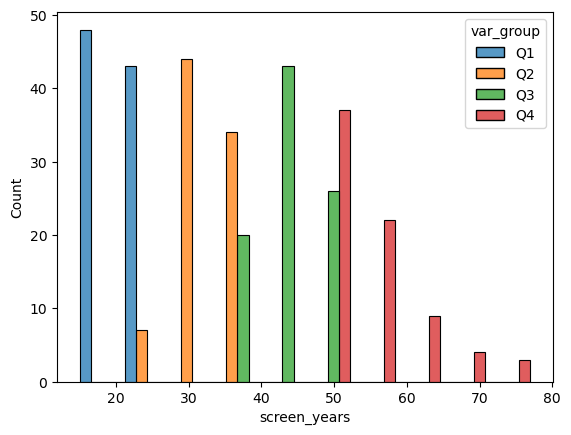

In [322]:
sns.histplot(data=df_model_processed[['pid', 'screen_years']].rename(columns={'screen_years': 'screen_years_scaled'}).merge(df_KM_plot),#[['pid', 'screen_years', 'screen_years_scaled']],
             x='screen_years',#_scaled',
             hue='var_group',
             multiple='dodge'
            )

In [326]:
df_KM_plot.query("var_group=='Q4'").screen_years.min()

49

In [246]:
df_model_processed[['pid', 'screen_years']].rename(columns={'screen_years': 'screen_years_scaled'}).merge(df_KM_plot).groupby('var_group')['screen_years_scaled'].agg(['min', 'max'])

,min,max
var_group,,
Q1,-1.716589,-0.860355
Q2,-0.782515,-0.004121
Q3,0.073719,0.852113
Q4,0.929953,3.109457


In [645]:
df_KM_plot.var_group.value_counts()

var_group
0    305
1     35
Name: count, dtype: int64

281
83
Balanced: p = 0.2904
Early: p = 0.3156
Late: p = 0.0415


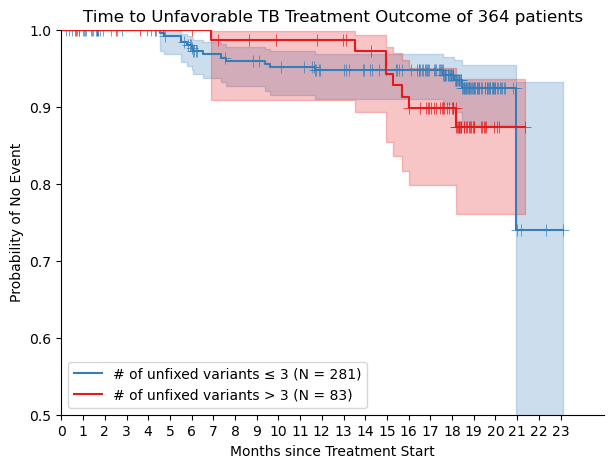

In [339]:
df_KM_plot = df_add_metric_for_model.query("pid in @df_model_processed.pid").merge(df_tx_outcomes[['pid', 'event_type', 'TB_death', 'date', 'event', 'weeks', 'months']])

thresh = 3

# get raw values
if 'NumVar1' in df_KM_plot.columns:
    del df_KM_plot['NumVar1']

df_KM_plot = df_KM_plot.merge(df_LAF_baseline[['pid', 'NumVar1']])

df_KM_plot['NumVar1'] = df_KM_plot['NumVar1'].astype(int)
df_KM_plot['var_group'] = (df_KM_plot['NumVar1'] > thresh).astype(int)

fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_KM_plot.months.max()))

kmf = lifelines.KaplanMeierFitter()

# stratify_col = f'{diversity_metric}_Binary'
# df_KM_plot[stratify_col] = (df_KM_plot[diversity_metric] > thresh).astype(int)
# label_dict = {0: f'# Low-AF Sites ≤ {thresh}', 1: f'# Low-AF Sites > {thresh}'}
# color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

stratify_col = 'var_group'

color_dict = {0: sns.color_palette('Set1').as_hex()[1], 1: sns.color_palette('Set1').as_hex()[0]}
label_dict = {0: f"≤ {thresh}", 1: f"> {thresh}"}

kmf_tables = []

if tb_deaths_only:
    df_KM_plot.loc[df_KM_plot['TB_death']==0, 'event'] = 0

for group in np.sort(df_KM_plot[stratify_col].unique()):
    
    df_single_group = df_KM_plot.query(f"{stratify_col}==@group")
    print(len(df_single_group))

    kmf.fit(df_single_group['months'], event_observed=df_single_group['event'])
    
    kmf.plot_survival_function(ax=ax, 
                               show_censors=True, 
                               color=color_dict[group], 
                               censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                               label=f"# of unfixed variants {label_dict[group]} (N = {len(df_single_group)})",
                              )

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_KM_plot.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

plt.xlim(0, max_val + 1)
plt.ylim(0.5, 1)

logRank_balanced_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=0, weightings="fleming-harrington").p_value
logRank_early_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=1, q=0, weightings="fleming-harrington").p_value
logRank_late_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=1, weightings="fleming-harrington").p_value

print(f"Balanced: p = {np.round(logRank_balanced_pval, 4)}")
print(f"Early: p = {np.round(logRank_early_pval, 4)}")
print(f"Late: p = {np.round(logRank_late_pval, 4)}")

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, int(df_KM_plot['months'].max()) + 1))

# plt.legend(title='Percentiles')

sns.despine()
plt.savefig(f"../results/figures/outcomes/KM_estimate_binarized_{thresh}.svg", bbox_inches='tight')

In [340]:
max_time = 12

df_KM_plot.loc[df_KM_plot['months'] > max_time, 'event'] = 0

lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=0, weightings="fleming-harrington").p_value

0.1443607630873493

In [123]:
lifelines.statistics.multivariate_logrank_test(df_KM_plot.query("months <= 12")['date'], 
                                               df_KM_plot.query("months <= 12")[stratify_col], 
                                               df_KM_plot.query("months <= 12")['event'], 
                                               p=0, q=0, weightings="fleming-harrington").p_value

0.3041936379814044

In [112]:
thresh

3

In [461]:
df_KM_plot.groupby('var_group').event.agg(['sum', 'mean'])

,sum,mean
var_group,,
0,21,0.060519
1,4,0.235294


In [369]:
df_KM_plot.query("var_group==1")[['event', 'event_type']].query("event_type != 'cure'")

,event,event_type
25,1,relapse
42,1,relapse
55,1,death
201,1,relapse
255,1,tx_failure
292,1,relapse
305,1,relapse


In [751]:
color_dict

{0: '#e41a1c',
 1: '#377eb8',
 2: '#4daf4a',
 3: '#984ea3',
 4: '#ff7f00',
 5: '#ffff33',
 6: '#a65628',
 7: '#f781bf',
 8: '#999999',
 9: '#e41a1c',
 10: '#377eb8',
 11: '#4daf4a',
 12: '#984ea3',
 13: '#ff7f00',
 14: '#ffff33',
 15: '#a65628',
 16: '#f781bf',
 17: '#999999',
 18: '#e41a1c',
 19: '#377eb8'}

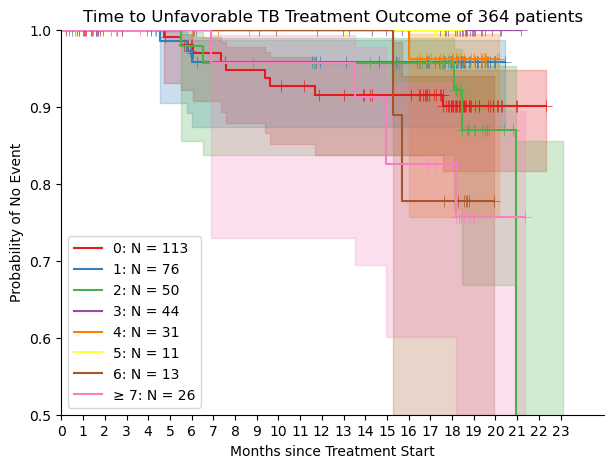

In [388]:
df_KM_plot = df_add_metric_for_model.query("pid in @df_model_processed.pid").merge(df_tx_outcomes[['pid', 'event_type', 'TB_death', 'date', 'event', 'weeks', 'months']])

df_KM_plot['NumVar1'] = df_KM_plot['NumVar1'].astype(int)
all_vals = np.arange(df_KM_plot['NumVar1'].max() + 1)
all_vals = [0, 1, 2, 3, 4, 5, 6, 7]

# it's the binarized one here, not raw values
del df_KM_plot['NumVar1']

# get raw values
df_KM_plot = df_KM_plot.merge(df_LAF_baseline[['pid', 'NumVar1']])

fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_KM_plot.months.max()))

kmf = lifelines.KaplanMeierFitter()

color_dict = dict(zip(all_vals, sns.color_palette('Set1', n_colors=len(all_vals)).as_hex()))

kmf_tables = []

if tb_deaths_only:
    df_KM_plot.loc[df_KM_plot['TB_death']==0, 'event'] = 0

for val in all_vals:
    
    if val <= 6:
        df_single_group = df_KM_plot.query("NumVar1==@val")
        label = val
    else:
        df_single_group = df_KM_plot.query("NumVar1 >= @val")
        label = f"≥ {val}"
    
    if len(df_single_group) > 0:

        kmf.fit(df_single_group['months'], event_observed=df_single_group['event'],)# label=group_name)

        kmf.plot_survival_function(ax=ax, 
                                   show_censors=True, 
                                   color=color_dict[val], 
                                   censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                                   # label=f"# Sites ≥ {int(group)} = {len(df_single_group)}",
                                   # label=f"{group_name} = [{int(value_dict[group][0])}, {int(value_dict[group][1])}]: (N = {len(df_single_group)})"
                                   label=f"{label}: N = {len(df_single_group)}"
                                  )

        # Original event table (indexed by actual event/censor times)
        event_table = kmf.event_table

        # Define integer time points of interest
        integer_times = np.arange(0, max_val + 1)

        # Reindex to integer times
        event_table_int = (
            event_table.reindex(integer_times, method="ffill").fillna(method="bfill")
        )

        # Now you can extract at-risk and censored at integer times
        at_risk_int = event_table_int["at_risk"]
        censored_int = event_table_int["censored"]

        every_other_month = np.linspace(0, max_val, 13)

        # event_table_int['Group'] = group_name
        # kmf_tables.append(event_table_int[['Group', 'at_risk', 'censored']].loc[every_other_month])
    
# kmf_tables = pd.concat(kmf_tables, axis=1)

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_KM_plot.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

plt.xlim(0, max_val + 1)
plt.ylim(0.5, 1)

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, int(df_KM_plot['months'].max()) + 1))

# plt.legend(title='Percentiles')

sns.despine()
plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles_for_investigators_meeting.svg", bbox_inches='tight')

188
49
44
30
24
26
Balanced: p = 0.1067
Early: p = 0.1114
Late: p = 0.0723


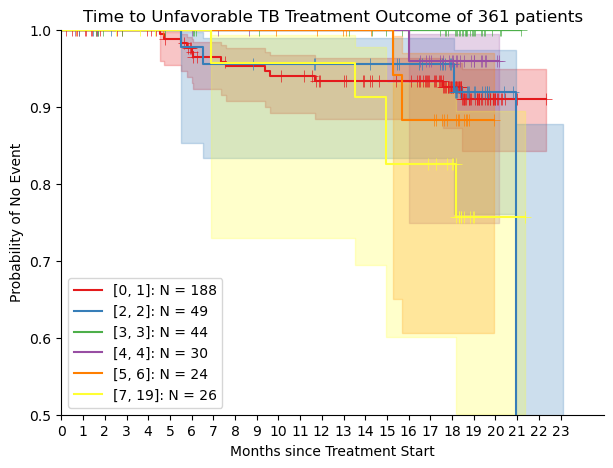

In [765]:
df_KM_plot = df_add_metric_for_model.query("pid in @df_model_processed.pid").merge(df_tx_outcomes[['pid', 'event_type', 'TB_death', 'date', 'event', 'weeks', 'months']])

df_KM_plot['NumVar1'] = df_KM_plot['NumVar1'].astype(int)

quantiles_lst = [0, 0.50, 0.6, 0.7, 0.8, 0.9, 1.0]
# quantiles_lst = [0, 0.50, 0.75, 1.0]
labels_lst = [f"Q{num}" for num in np.arange(len(quantiles_lst)-1)]

df_KM_plot["var_group"] = pd.qcut(
    df_KM_plot["NumVar1"],
    q=quantiles_lst,       # quantile cutpoints
    labels=labels_lst     # group names
)

# percentiles = [0, 25, 50, 75]

# # for i, perc in enumerate(percentiles):
#     # perc_value = np.percentile(df_KM_plot['NumVar1'], perc)
#     # print(perc, perc_value)
# for i, perc_value in enumerate([0, 1, 3, 4]):
#     df_KM_plot.loc[df_KM_plot['NumVar1'] >= perc_value, "var_group"] = f"Q{i+1}"
    
# it's the binarized one here, not raw values
del df_KM_plot[diversity_metrics[0]]

# get raw values
df_KM_plot = df_KM_plot.merge(df_LAF_baseline[['pid', 'NumVar1']])

fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_KM_plot.months.max()))

kmf = lifelines.KaplanMeierFitter()

# stratify_col = f'{diversity_metric}_Binary'
# df_KM_plot[stratify_col] = (df_KM_plot[diversity_metric] > thresh).astype(int)
# label_dict = {0: f'# Low-AF Sites ≤ {thresh}', 1: f'# Low-AF Sites > {thresh}'}
# color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

stratify_col = 'var_group'

# label_dict = {
#     "Q1": r"$25^{\mathrm{th}}$",
#     "Q2": r"$50^{\mathrm{th}}$",
#     "Q3": r"$75^{\mathrm{th}}$",
#     "Q4": r"$100^{\mathrm{th}}$"
# }

label_dict = dict(zip(labels_lst, labels_lst))

value_dict = {var: [df_KM_plot.query(f"var_group==@var").NumVar1.min(), df_KM_plot.query(f"var_group==@var").NumVar1.max()] for var in label_dict.keys()}

color_dict = dict(zip(list(label_dict.keys()), sns.color_palette('Set1', n_colors=len(label_dict)).as_hex()))

kmf_tables = []

if tb_deaths_only:
    df_KM_plot.loc[df_KM_plot['TB_death']==0, 'event'] = 0

for group in np.sort(df_KM_plot[stratify_col].unique()):
    
    df_single_group = df_KM_plot.query(f"{stratify_col}==@group")
    print(len(df_single_group))
    group_name = label_dict[group]

    kmf.fit(df_single_group['months'], event_observed=df_single_group['event'],)# label=group_name)
    
    kmf.plot_survival_function(ax=ax, 
                               show_censors=True, 
                               color=color_dict[group], 
                               censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                               # label=f"# Sites ≥ {int(group)} = {len(df_single_group)}",
                               # label=f"{group_name} = [{int(value_dict[group][0])}, {int(value_dict[group][1])}]: (N = {len(df_single_group)})"
                               label=f"[{int(value_dict[group][0])}, {int(value_dict[group][1])}]: N = {len(df_single_group)}"
                              )
    
    # Original event table (indexed by actual event/censor times)
    event_table = kmf.event_table

    # Define integer time points of interest
    integer_times = np.arange(0, max_val + 1)

    # Reindex to integer times
    event_table_int = (
        event_table.reindex(integer_times, method="ffill").fillna(method="bfill")
    )

    # Now you can extract at-risk and censored at integer times
    at_risk_int = event_table_int["at_risk"]
    censored_int = event_table_int["censored"]

    every_other_month = np.linspace(0, max_val, 13)
    
    # event_table_int['Group'] = group_name
    # kmf_tables.append(event_table_int[['Group', 'at_risk', 'censored']].loc[every_other_month])
    
# kmf_tables = pd.concat(kmf_tables, axis=1)

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_KM_plot.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

plt.xlim(0, max_val + 1)
plt.ylim(0.5, 1)

logRank_balanced_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=0, weightings="fleming-harrington").p_value
logRank_early_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=1, q=0, weightings="fleming-harrington").p_value
logRank_late_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=1, weightings="fleming-harrington").p_value

print(f"Balanced: p = {np.round(logRank_balanced_pval, 4)}")
print(f"Early: p = {np.round(logRank_early_pval, 4)}")
print(f"Late: p = {np.round(logRank_late_pval, 4)}")

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, int(df_KM_plot['months'].max()) + 1))

# plt.legend(title='Percentiles')

sns.despine()
# plt.savefig(f"../results/figures/outcomes/KM_estimate_binarized_{thresh}.svg", bbox_inches='tight')
plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles_for_investigators_meeting.svg", bbox_inches='tight')
# plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles_for_defense.svg", bbox_inches='tight')

In [762]:
np.percentile(df_add_metric_for_model['NumVar1'], 50)

1.0

In [767]:
df_add_metric_for_model

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,MixedInfect,High_TTP,advanced_age,Age_Squared,predicted_PLI,human_PLI,human_high_lung_involvement,NumVar1,NumVar1_leq_3,NumVar1_above_3
0,T0001,S0001-01,MFS-331,MFS-331_lib58943,NaN,NaN,1.0,437.07,1.00,0.9887,...,0,1,1,2601,23.755040,27.0,1,5,3,2
1,T0002,S0002-01,MFS-509,MFS-509_lib64061,NaN,NaN,1.0,373.24,1.00,0.9901,...,0,0,0,324,27.663921,16.0,0,0,0,0
2,T0003,S0003-01,MFS-511,MFS-511_lib64063,NaN,NaN,1.0,339.17,0.99,0.9892,...,0,1,0,2500,8.343956,16.0,0,0,0,0
3,T0005,S0005-01,MFS-332,MFS-332_lib58944,NaN,NaN,1.0,348.59,0.99,0.9890,...,0,0,0,729,19.653946,16.0,0,0,0,0
4,T0007,S0007-01,MFS-3,MFS-3_lib45533,NaN,NaN,1.0,323.70,0.99,0.9895,...,0,0,0,1024,6.469509,1.0,0,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,T0471,S0471-01,MFS-860,MFS-860_lib73356,NaN,NaN,1.0,371.19,0.99,0.9841,...,0,1,0,289,77.533170,59.0,1,3,3,0
362,T0472,S0472-01,MFS-862,MFS-862_lib73358,NaN,NaN,1.0,292.00,1.00,0.9889,...,0,0,1,2704,NaN,67.0,1,0,0,0
363,T0474,S0474-01,MFS-864,MFS-864_lib73360,NaN,NaN,1.0,570.01,0.99,0.9870,...,0,0,0,324,20.778086,44.0,1,0,0,0
364,T0476,S0476-01,MFS-894,MFS-894_lib83849,NaN,NaN,1.0,299.05,1.00,0.9848,...,0,0,0,676,40.826385,53.0,1,1,1,0


In [ ]:
df_KM_plot = df_add_metric_for_model.query("pid in @df_model_processed.pid").merge(df_tx_outcomes[['pid', 'event_type', 'TB_death', 'date', 'event', 'weeks', 'months']])
df_KM_plot['human_high_lung_involvement'] = (df_KM_plot['human_PLI'] > PLI_thresh).astype(int)

fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_KM_plot.months.max()))

kmf = lifelines.KaplanMeierFitter()

# stratify_col = f'{diversity_metric}_Binary'
# df_KM_plot[stratify_col] = (df_KM_plot[diversity_metric] > thresh).astype(int)
# label_dict = {0: f'# Low-AF Sites ≤ {thresh}', 1: f'# Low-AF Sites > {thresh}'}
# color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

stratify_col = 'human_high_lung_involvement'

color_dict = dict(zip([0, 1], sns.color_palette('Set1', n_colors=2).as_hex()))

kmf_tables = []

if tb_deaths_only:
    df_KM_plot.loc[df_KM_plot['TB_death']==0, 'event'] = 0

for group in np.sort(df_KM_plot[stratify_col].unique()):
    
    df_single_group = df_KM_plot.query(f"{stratify_col}==@group")
    print(len(df_single_group))

    kmf.fit(df_single_group['months'], event_observed=df_single_group['event'],)# label=group_name)
    
    kmf.plot_survival_function(ax=ax, 
                               show_censors=True, 
                               color=color_dict[group], 
                               censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                               label=f"PLI > {PLI_thresh}% = {group}"
                               # label=f"# Sites ≥ {int(group)} = {len(df_single_group)}",
                               # label=f"{group_name} = [{int(value_dict[group][0])}, {int(value_dict[group][1])}]: (N = {len(df_single_group)})"
                               # label=f"[{int(value_dict[group][0])}, {int(value_dict[group][1])}]: N = {len(df_single_group)}"
                              )
    
    # Original event table (indexed by actual event/censor times)
    event_table = kmf.event_table

    # Define integer time points of interest
    integer_times = np.arange(0, max_val + 1)

    # Reindex to integer times
    event_table_int = (
        event_table.reindex(integer_times, method="ffill").fillna(method="bfill")
    )

    # Now you can extract at-risk and censored at integer times
    at_risk_int = event_table_int["at_risk"]
    censored_int = event_table_int["censored"]

    every_other_month = np.linspace(0, max_val, 13)
    
    # event_table_int['Group'] = group_name
    # kmf_tables.append(event_table_int[['Group', 'at_risk', 'censored']].loc[every_other_month])
    
# kmf_tables = pd.concat(kmf_tables, axis=1)

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_KM_plot.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

plt.xlim(0, max_val + 1)
plt.ylim(0.5, 1)

logRank_balanced_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=0, weightings="fleming-harrington").p_value
logRank_early_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=1, q=0, weightings="fleming-harrington").p_value
logRank_late_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=1, weightings="fleming-harrington").p_value

print(f"Balanced: p = {np.round(logRank_balanced_pval, 4)}")
print(f"Early: p = {np.round(logRank_early_pval, 4)}")
print(f"Late: p = {np.round(logRank_late_pval, 4)}")

# # Set x-axis ticks to show all integers
# ax.set_xticks(range(0, int(df_KM_plot['months'].max()) + 1))

# # plt.legend(title='Percentiles')

# sns.despine()
# # plt.savefig(f"../results/figures/outcomes/KM_estimate_binarized_{thresh}.svg", bbox_inches='tight')
# plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles.svg", bbox_inches='tight')
# # plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles_for_defense.svg", bbox_inches='tight')

189
31
38
33
36
37
Balanced: p = 0.0589
Early: p = 0.0561
Late: p = 0.3097


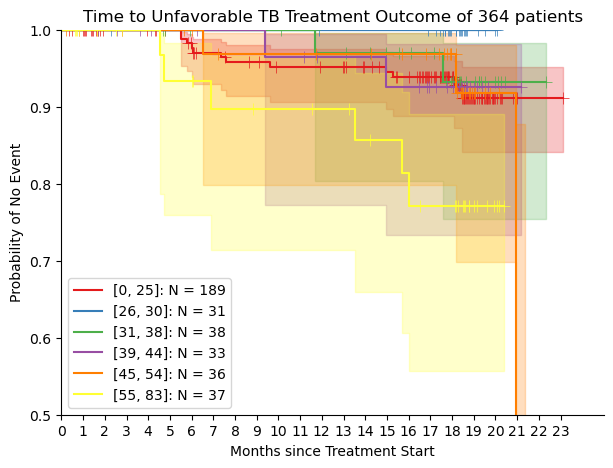

In [364]:
df_KM_plot = df_add_metric_for_model.query("pid in @df_model_processed.pid").merge(df_tx_outcomes[['pid', 'event_type', 'TB_death', 'date', 'event', 'weeks', 'months']])

df_KM_plot['human_PLI'] = df_KM_plot['human_PLI'].astype(int)

quantiles_lst = [0, 0.50, 0.6, 0.7, 0.8, 0.9, 1.0]
labels_lst = [f"Q{num}" for num in np.arange(len(quantiles_lst)-1)]

df_KM_plot["var_group"] = pd.qcut(
    df_KM_plot["human_PLI"],
    q=quantiles_lst,       # quantile cutpoints
    labels=labels_lst     # group names
)

# percentiles = [0, 25, 50, 75]

# # for i, perc in enumerate(percentiles):
#     # perc_value = np.percentile(df_KM_plot['NumVar1'], perc)
#     # print(perc, perc_value)
# for i, perc_value in enumerate([0, 1, 3, 4]):
#     df_KM_plot.loc[df_KM_plot['NumVar1'] >= perc_value, "var_group"] = f"Q{i+1}"
    
# it's the binarized one here, not raw values
del df_KM_plot[diversity_metrics[0]]

# get raw values
fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_KM_plot.months.max()))

kmf = lifelines.KaplanMeierFitter()

# stratify_col = f'{diversity_metric}_Binary'
# df_KM_plot[stratify_col] = (df_KM_plot[diversity_metric] > thresh).astype(int)
# label_dict = {0: f'# Low-AF Sites ≤ {thresh}', 1: f'# Low-AF Sites > {thresh}'}
# color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

stratify_col = 'var_group'

# label_dict = {
#     "Q1": r"$25^{\mathrm{th}}$",
#     "Q2": r"$50^{\mathrm{th}}$",
#     "Q3": r"$75^{\mathrm{th}}$",
#     "Q4": r"$100^{\mathrm{th}}$"
# }

label_dict = dict(zip(labels_lst, labels_lst))

value_dict = {var: [df_KM_plot.query(f"var_group==@var")['human_PLI'].min(), df_KM_plot.query(f"var_group==@var")['human_PLI'].max()] for var in label_dict.keys()}

color_dict = dict(zip(list(label_dict.keys()), sns.color_palette('Set1', n_colors=len(label_dict)).as_hex()))

kmf_tables = []

if tb_deaths_only:
    df_KM_plot.loc[df_KM_plot['TB_death']==0, 'event'] = 0

for group in np.sort(df_KM_plot[stratify_col].unique()):
    
    df_single_group = df_KM_plot.query(f"{stratify_col}==@group")
    print(len(df_single_group))
    group_name = label_dict[group]

    kmf.fit(df_single_group['months'], event_observed=df_single_group['event'],)# label=group_name)
    
    kmf.plot_survival_function(ax=ax, 
                               show_censors=True, 
                               color=color_dict[group], 
                               censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                               # label=f"# Sites ≥ {int(group)} = {len(df_single_group)}",
                               # label=f"{group_name} = [{int(value_dict[group][0])}, {int(value_dict[group][1])}]: (N = {len(df_single_group)})"
                               label=f"[{int(value_dict[group][0])}, {int(value_dict[group][1])}]: N = {len(df_single_group)}"
                              )
    
    # Original event table (indexed by actual event/censor times)
    event_table = kmf.event_table

    # Define integer time points of interest
    integer_times = np.arange(0, max_val + 1)

    # Reindex to integer times
    event_table_int = (
        event_table.reindex(integer_times, method="ffill").fillna(method="bfill")
    )

    # Now you can extract at-risk and censored at integer times
    at_risk_int = event_table_int["at_risk"]
    censored_int = event_table_int["censored"]

    every_other_month = np.linspace(0, max_val, 13)
    
    # event_table_int['Group'] = group_name
    # kmf_tables.append(event_table_int[['Group', 'at_risk', 'censored']].loc[every_other_month])
    
# kmf_tables = pd.concat(kmf_tables, axis=1)

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_KM_plot.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

plt.xlim(0, max_val + 1)
plt.ylim(0.5, 1)

logRank_balanced_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=0, weightings="fleming-harrington").p_value
logRank_early_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=1, q=0, weightings="fleming-harrington").p_value
logRank_late_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=1, weightings="fleming-harrington").p_value

print(f"Balanced: p = {np.round(logRank_balanced_pval, 4)}")
print(f"Early: p = {np.round(logRank_early_pval, 4)}")
print(f"Late: p = {np.round(logRank_late_pval, 4)}")

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, int(df_KM_plot['months'].max()) + 1))

# plt.legend(title='Percentiles')

sns.despine()
# plt.savefig(f"../results/figures/outcomes/KM_estimate_binarized_{thresh}.svg", bbox_inches='tight')
# plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles.svg", bbox_inches='tight')
# plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles_for_defense.svg", bbox_inches='tight')